In [1]:
# Make repo root importable for this session (zero packaging)
import sys, pathlib
repo_root = pathlib.Path.cwd().parent if (pathlib.Path.cwd().name == "notebooks") else pathlib.Path.cwd()
sys.path.insert(0, str(repo_root))
%load_ext autoreload
%autoreload 2

In [2]:
import numpy as np
import math
import time
from datetime import datetime
import os
import shutil # for copying checkpoint to "last"
from pathlib import Path
import gc

import torch
import torch.nn as nn
import torchvision.transforms as transform

from torch.utils.tensorboard import SummaryWriter
import matplotlib.pylab as plt
%matplotlib inline
from IPython.display import Audio

from rnencodec.utils.utils import param_breakdown
from rnencodec.utils.io import save_run_config

from rnencodec.audioDataLoader.audio_dataset import LatentDatasetConfig, EnCodecLatentDataset_constant, EnCodecLatentDataset_dynamic, EnCodecLatentDataset_dynamic_v2, latents_to_audio_simple, efficient_codes_to_latents
from torch.utils.data import DataLoader

import rnencodec.model.gru_audio_model
from rnencodec.model.gru_audio_model import GRUModelConfig

from transformers import EncodecModel

import torch.nn.functional as F

<div style="width: 100%; height: 5px; background-color: DarkBlue;"></div>
<b>Data sets</b>

The syn7wav24_tokens_HFdataset_5 has the following parameters:   
&nbsp;&nbsp;&nbsp;&nbsp;        ['Full File Name', 'class_name', 'param1', 'param2', 'param3', 'param0', 'audio']  
and the following unique 'class_name' values:  
&nbsp;&nbsp;&nbsp;&nbsp;        Class list: ['ChirpPattern', 'DSApplause', 'DSBugs', 'DSPeepers', 'DSPistons', 'DSWind', 'TokWotalDuet']  
which you can use to filter the full dataset if you only want to train on a subset of sound classes, for example:  
&nbsp;&nbsp;&nbsp;&nbsp;        config.filters = {'class_name': {'DSPistons', 'DSApplause'}}  
<div style="width: 100%; height: 5px; background-color: DarkBlue;"></div>

### Data Params  
<a id="dataparams"></a>

These parameters are saved to file, and serve several purposes:
* The allow other programs to properly evaluate and visualize the trained (and also saved) models,
* Provide a record of the parameters that allow reproducing results. 

In [3]:
resume_checkpoint= None #str(Path("./output/20250817_151624_pistons_2048.16_4.96/"))  # None # 

dataset="syntex" # "ddsp_violin"

if dataset=="syntex": # syntex
    sourcedatadir = os.path.join(os.getcwd(), '/slowdisk/esteban/scratchdata/syntex24/data7wav/syn7wav24_tokens_HFdataset_5' )  # where the data files live
    savename="multiclass_test_SOFTcascade" #"DSPistons_noTF"  #just a tag on the output folder 
    #props={"param1": (0,1)}
    props={"c1": (0, 1), "c2": (0, 1),"c3": (0, 1),"c4": (0, 1),"c5": (0, 1),"c6": (0, 1),"c7": (0, 1),"param1": (0,1)}
    filters= {}# {'class_name': {'TokWotalDuet'}} 
    train_split='train_sm'
    val_split='val'
    EnCodecLatentDataset=EnCodecLatentDataset_constant  #latents in .arrow file, column headers are param names, column values are param values - one value per audio file

elif dataset=="nsynth" : # nsynth
    sourcedatadir = os.path.join(os.getcwd(), '/slowdisk/data/MuMeRNN/data/nsynth.64.76.ecdc24HF' )  # where the data files live
    savename="nsynth_soft_cascade"  #just a tag on the output folder 
    props={"class": (.0,1),"norm_pitch": (-.05,1.05), "norm_amp": (0,1),} #what to map into [0,1]
    filters= {} 
    train_split='train'
    val_split='train'
    EnCodecLatentDataset=EnCodecLatentDataset_constant   #latents in .arrow file, column headers are param names, column values are param values - one value per audio file

elif dataset=="water":
    sourcedatadir = os.path.join(repo_root, 'artifacts/data/waterfill_quickstart_hf_dataset' )  # where the data files live
    savename="quickstart_softcascade"  #just a tag on the output folder 
    props={"pos": None}  #what to map into [0,1]
    filters= {} 
    train_split='train'
    val_split='train'    
    EnCodecLatentDataset=EnCodecLatentDataset_dynamic   #latents in "sidecar" npy and json files and have as many frames as the audio file


elif dataset=="ddsp_violin":
    sourcedatadir = os.path.join(repo_root, '/slowdisk/data/DDSP_ViolinSet2/ddsp_violinset_hf' )  # where the data files live
    savename="ddsp_violin_seql_75_corrected"  #just a tag on the output folder 
    props={"pitch": None, "amp": None}  #what to map into [0,1]
    filters= {} 
    train_split='train'
    val_split='train'    
    EnCodecLatentDataset=EnCodecLatentDataset_dynamic_v2   #latents in "sidecar" npy and json files and have as many frames as the audio file


print(f'props are {props}')
rawqweights=torch.tensor([1.0, 0.9, 0.8, 0.7, 0.6, 0.5, 0.4, 0.3], dtype=torch.float)

params = dict(
    # Read/write directory of data & parameter files
    #*************************************
    sample_rate=24000,
    runTimeStamp='{:%Y-%m-%d_%H-%M-%S}'.format(datetime.now()),
    
    datadir = sourcedatadir,
    filters=filters,
    
    savemodel = True,
    savemodel_interval = 25, #10, # in units of epochs
    savemodeldir = os.path.join(os.getcwd(), 'output'), # default saving directory for models and the parameterization

    # Training parameters ----------------------------------------------
    num_epochs = 225, # #20, # of batches_per_epoch of batch_size sequeunce
    batches_per_epoch = 100, #100, 
    batch_size = 100, #100, 
    
    noise=.05,
    seqLen = 125, #75, #14379, # 125, # 125,

    lr = 0.005,
    # parameter names for the Data Loader to search for in the filenames, and the range that maps to [0,1] for training and inference
    # The order specified in this structure will be the order used for inference
    props=props,
    
    # Model parameters -----------------
    input_size = 128,
    hiddenSize = 128, # 128, #100,
    nLayers = 3,
    inp_proportion = 5,
    cond_proportion = 1,
    codebook_size = 1024, # encodec codebook size
    dropout = 0.1,
    n_q = 8,                                # Number of codebooks to use
    quantizer_weights = rawqweights * (len(rawqweights) / rawqweights.sum()), #normed to sum to the length of the array
    clamp_val = 15,


    # training-time knobs you already have (not used yet)
    gumbel_tau_start = 1.0,
    gumbel_tau_end = 0.5,
    straight_through = True,

    # cascade selection
    cascade = "soft",  # "hard" | "soft"

    # HARD cascade knobs
    hard_sample_mode = "sample",
    top_n_hard = 3,   # used for both training and for the little inference thing I do at the end of each batch
    temperature_hard = 1.0,
    
    # SOFT cascade knobs (RNG-free unless you later add gumbel-soft)
    tau_soft = 0.6,
    top_n_soft = None,  # optional sparse softmax (still deterministic)

    # ----------------------------
    simulate_parallel = False,  #Simultate parallel will turn TF on and send 0's in to simulate no cascading information

    # Training parameters
    files_per_sequence=2, #important - how many different data files to draw from to create each sequence. For short seq_lens, and dynamic params, this should probably be 1
    TF_schedule = [25,25], # cycle: [TF batches, noTF batches] (make sure simulate_parallel is False if you want TF

)

# for managing the switching between TF and no TF
TF_cycle=params['TF_schedule'][0]+params['TF_schedule'][1]
use_tf = lambda epoch: (epoch % TF_cycle) < params['TF_schedule'][0]  # ['TF_schedule'][0]  on, ['TF_schedule'][1] off

props are {'c1': (0, 1), 'c2': (0, 1), 'c3': (0, 1), 'c4': (0, 1), 'c5': (0, 1), 'c6': (0, 1), 'c7': (0, 1), 'param1': (0, 1)}


In [4]:
params

{'sample_rate': 24000,
 'runTimeStamp': '2025-10-27_18-19-30',
 'datadir': '/slowdisk/esteban/scratchdata/syntex24/data7wav/syn7wav24_tokens_HFdataset_5',
 'filters': {},
 'savemodel': True,
 'savemodel_interval': 25,
 'savemodeldir': '/home/lonce/working/RNeNcodec/notebooks/output',
 'num_epochs': 225,
 'batches_per_epoch': 100,
 'batch_size': 100,
 'noise': 0.05,
 'seqLen': 125,
 'lr': 0.005,
 'props': {'c1': (0, 1),
  'c2': (0, 1),
  'c3': (0, 1),
  'c4': (0, 1),
  'c5': (0, 1),
  'c6': (0, 1),
  'c7': (0, 1),
  'param1': (0, 1)},
 'input_size': 128,
 'hiddenSize': 128,
 'nLayers': 3,
 'inp_proportion': 5,
 'cond_proportion': 1,
 'codebook_size': 1024,
 'dropout': 0.1,
 'n_q': 8,
 'quantizer_weights': tensor([1.5385, 1.3846, 1.2308, 1.0769, 0.9231, 0.7692, 0.6154, 0.4615]),
 'clamp_val': 15,
 'gumbel_tau_start': 1.0,
 'gumbel_tau_end': 0.5,
 'straight_through': True,
 'cascade': 'soft',
 'hard_sample_mode': 'sample',
 'top_n_hard': 3,
 'temperature_hard': 1.0,
 'tau_soft': 0.6,
 'to

### Run Params 

In [5]:
sr = params['sample_rate']

log_interval = 1 # units of epochs
visualize_interval = log_interval # units of epochs

#Generation parameters
#*************************************
max_length = params['seqLen']*3  #length of the sequence used to inspect progress in audio plots during training

# Cuda
#*************************************
device = torch.device('cuda:0' if torch.cuda.is_available() else 'cpu')
#device='cpu'
device

device(type='cuda', index=0)

In [6]:
# Some utility functions
#*************************************
def time_taken(elapsed):
    """To format time taken in hh:mm:ss. Use with time.monotic()"""
    m, s = divmod(elapsed, 60)
    h, m = divmod(m, 60)
    return "%d:%02d:%02d" % (h, m, s)

def mydate() :
    return (datetime.now().strftime("%Y-%m-%d %H:%M:%S"))



In [7]:

#--- model settings ----#
model_config = GRUModelConfig (
    input_size = params['input_size'],
    cond_size = len(params['props']),
    hidden_size = params['hiddenSize'],
    num_layers = params['nLayers'],
    codebook_size = params['codebook_size'],  #mu-law quantization levels
    dropout = params['dropout'],
    n_q=params['n_q'],

    inp_proportion = params['inp_proportion'],
    cond_proportion = params['cond_proportion'],

    # training-time knobs you already have (not used yet)
    gumbel_tau_start = params['gumbel_tau_start'],
    gumbel_tau_end = params['gumbel_tau_end'],
    straight_through = params['straight_through'],

    # cascade selection
    cascade = params['cascade'],  # "hard" | "soft"

    # HARD cascade knobs
    hard_sample_mode = params['hard_sample_mode'],
    top_n_hard = params['top_n_hard'],   # used for both training and for the little inference thing I do at the end of each batch
    temperature_hard = params['temperature_hard'],

    tau_soft = params['tau_soft'],
    top_n_soft = params['top_n_soft'],  # optional sparse softmax (still deterministic)

)

    

# ---- Training Settings ----
data_config = LatentDatasetConfig(
    dataset_path=params['datadir'],
    sequence_length=params['seqLen'],
    parameter_specs=params['props'],
    add_noise= False if params['noise'] == 0 else True,   # Whether to add white noise
    noise_weight = params['noise'],                           # Desired signal-to-noise ratio (dB)
    codebook_size=params['codebook_size'],
    n_q=params['n_q'],
    clamp_val=params['clamp_val'],
    filters=filters,
    files_per_sequence=params['files_per_sequence'],

    # IMPORTANT: co-located sidecars → leave cond_root = None (default)
    cond_root=None,
    cond_suffix=".cond.npy",
    strict=False,                         # skip files with missing/mismatched sidecars instead of raising

)

# ---- Generation Settings ----
testdata_config = LatentDatasetConfig(
    dataset_path=params['datadir'],
    sequence_length=params['seqLen'],
    parameter_specs=params['props'],
    add_noise= False,                        # no noise for testing and priming
    noise_weight = params['noise'],                           # Desired signal-to-noise ratio (dB)
    codebook_size=params['codebook_size'],
    n_q=params['n_q'],
    clamp_val=params['clamp_val'],
    filters=filters,
    files_per_sequence=params['files_per_sequence'],

    # IMPORTANT: co-located sidecars → leave cond_root = None (default)
    cond_root=None,
    cond_suffix=".cond.npy",
    strict=False,                         # skip files with missing/mismatched sidecars instead of raising

)

# === Dataset and Loader ===
# Load your EnCodec model (update path as needed)
# this model we put on the GPU (or current device) and pass it to the inference engine (the datasets will have their own copy on the CPU
enc_model = EncodecModel.from_pretrained("facebook/encodec_24khz") # leave on the cpu till we are ready to train+inferece for now
enc_model.eval()

print("✅ Configuration and model loaded")


adataset = EnCodecLatentDataset(data_config, "facebook/encodec_24khz", split=train_split)

train_loader = DataLoader(adataset,
                             batch_size=params['batch_size'],
                             shuffle=True,
                             num_workers=4,
                             drop_last=True)

testdataset = EnCodecLatentDataset(testdata_config, "facebook/encodec_24khz", split=val_split)
test_loader = DataLoader(testdataset,
                            batch_size=1,
                            shuffle=True,
                            num_workers=4,
                            drop_last=True)
   
# The data "size" is the number of possible sequences the data loader can provide.
# Since the sequences are chosen randomly from the file, the number of possible sequence is the total number of audio samples in the set (minus the ones that start less than sequence length from the end of the files)
print("size of dataset is",len(adataset))
print("no. of batches per epoch is", params['batches_per_epoch'])
print("batchsize id  is", params['batch_size'])

✅ Configuration and model loaded
[EnCodecLatentDataset] No filters provided; using all 4410 rows.
Loaded 1375920 sequences from 4410 files in 'train_sm' split
[EnCodecLatentDataset] No filters provided; using all 147 rows.
Loaded 45864 sequences from 147 files in 'val' split
size of dataset is 1375920
no. of batches per epoch is 100
batchsize id  is 100


size of dataset is 1375920
no. of batches per epoch is 100
batchsize id  is 100
PVECT - shape is torch.Size([125, 8])
pvect[0]: tensor([1.0000, 0.0000, 0.0000, 0.0000, 0.0000, 0.0000, 0.0000, 0.5500])
pvect[last]: tensor([0.0000, 0.0000, 0.0000, 1.0000, 0.0000, 0.0000, 0.0000, 0.8500])
inp.shape is torch.Size([125, 128])


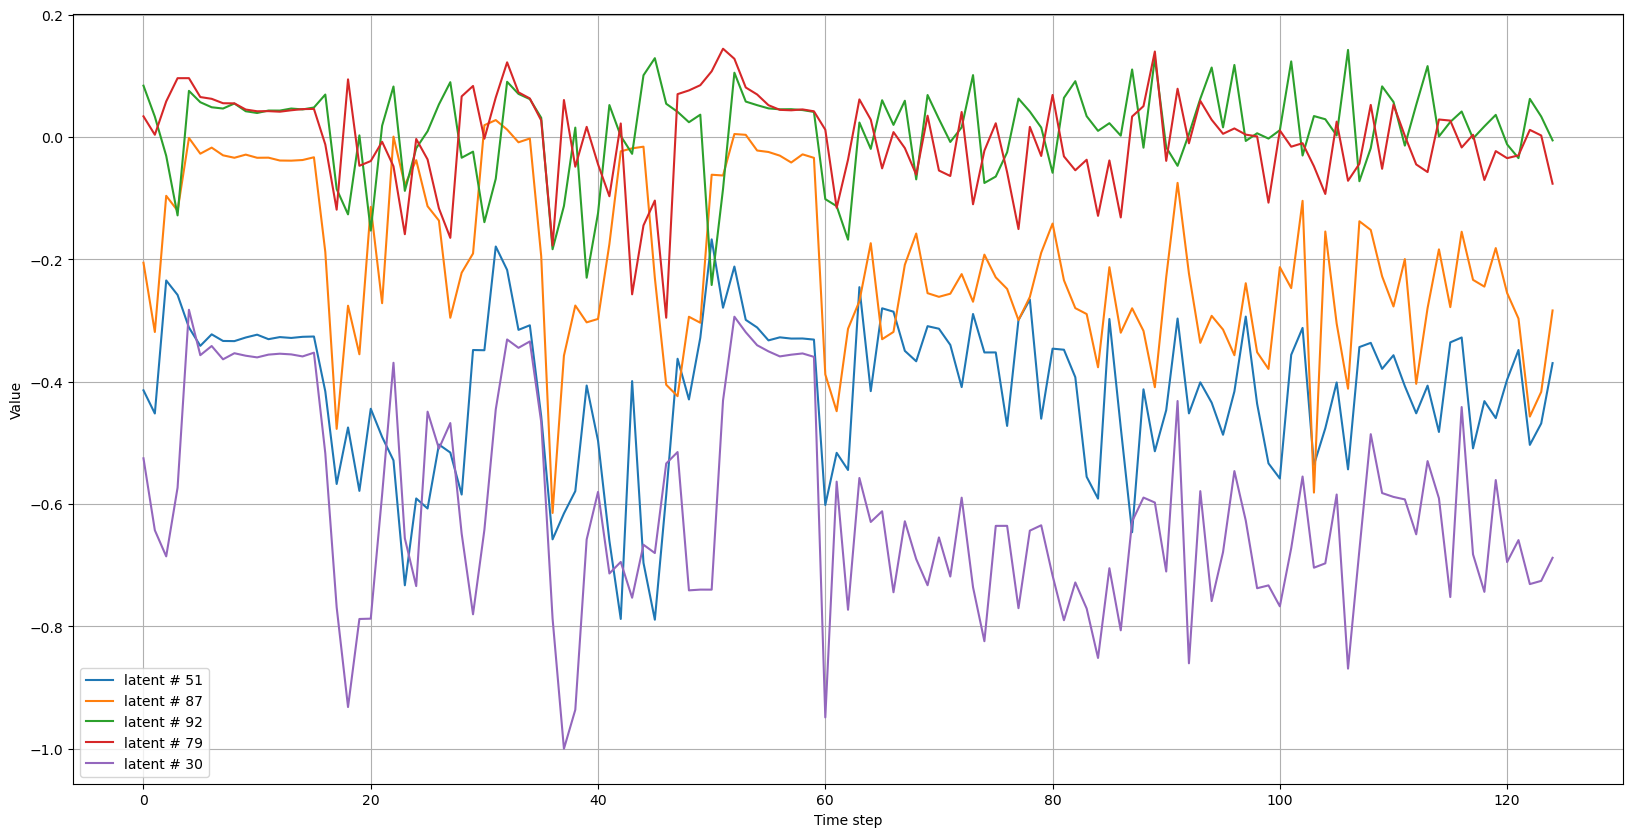

SHAPE: torch.Size([1, 128, 125])


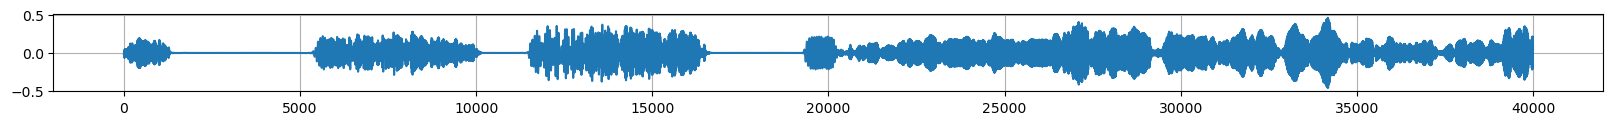

conditioning.shap = torch.Size([125, 8])


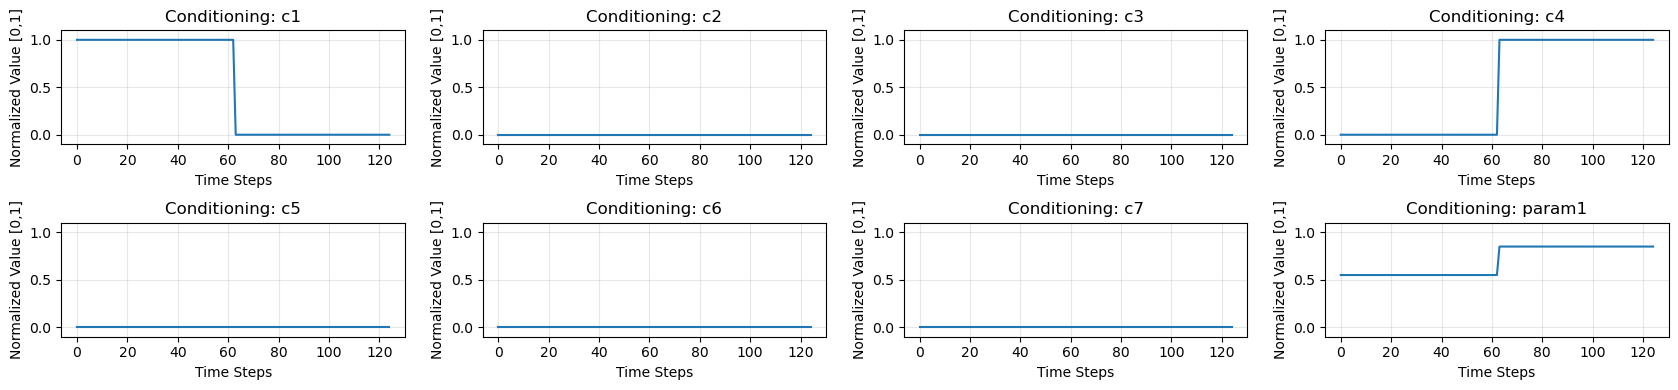

In [8]:
# just show some stuff 
def pmap(x) :
    return 55+x*(88-55)

print("size of dataset is",len(adataset))
print("no. of batches per epoch is", params['batches_per_epoch'])
print("batchsize id  is", params['batch_size'])

samp, target = adataset.rand_sample()  #samp.shape=(T, inputsize+cond_size)
pvect=samp[:, -model_config.cond_size:]
print(f'PVECT - shape is {pvect.shape}')
pvect0=samp[0, -model_config.cond_size:]
print(f"pvect[0]: {pvect0}")
pvectl=samp[params['seqLen']-1, -model_config.cond_size:]
print(f"pvect[last]: {pvectl}")

inp=samp[:,:-model_config.cond_size]
print(f'inp.shape is {inp.shape}')

# Now grab n=10 random latent components and look at them over time
_, p = inp.shape
# Generate n=10 random indices from 0 to p-1
indices = torch.randperm(p)[:5]
sub_inp = inp[:, indices]
sub_inp.shape


#first print latent sequence
plt.figure(figsize=(20,10)) 
# plt.plot(np.arange(len(sub_inp)), sub_inp) #just print some example from the batch
# plt.grid()
# plt.show()

ts = np.arange(len(sub_inp))  # time steps
for i in range(sub_inp.shape[1]):   # loop over trajectories
    plt.plot(ts, sub_inp[:, i], label=f"latent # {indices[i]}")
plt.legend()
plt.xlabel("Time step")
plt.ylabel("Value")
plt.grid()
plt.show()



tokens=samp[:, :params['input_size']].T.unsqueeze(0)
print(f"SHAPE: {tokens[:,:params['input_size']].shape}")
audiosamps, sr=latents_to_audio_simple(enc_model, tokens*params['clamp_val'])
audiosamps=audiosamps[0, 0]

plt.figure(figsize=(20,1)) 
plt.plot(audiosamps) #just print one example from the batch
plt.grid()
plt.show()


#conditioning = samp[:,-model_config.cond_size:]
cvect = pvect#=samp[:, -model_config.cond_size:] # samp[:, -model_config.cond_size:].squeeze(0)  #imp_seq[0, :, -len(params['props']):]
n_params = cvect.shape[1]
print(f'conditioning.shap = {cvect.shape}')
# # Additional Analysis: Conditioning parameters over time
if n_params > 0:
    plt.figure(figsize=(17, 4))
    
    param_names = list(data_config.parameter_specs.keys())
    
    for i in range(n_params):
        plt.subplot(2, (n_params + 1) // 2, i + 1)
        plt.plot(cvect[:,i].numpy())
        param_name = param_names[i] if i < len(param_names) else f'param_{i}'
        plt.title(f'Conditioning: {param_name}')
        plt.xlabel('Time Steps')
        plt.ylabel('Normalized Value [0,1]')
        plt.grid(True, alpha=0.3)
        plt.ylim(-0.1, 1.1)
    
    plt.tight_layout()
    plt.show()

    # #print out numbers
    # cvect_mapped = torch.stack([pmap(cvect[:, 0]), cvect[:, 1]], dim=1)
    # print(f"conditioning params: {cvect_mapped}")

#Another check just to see that the ecdc and params are coming from the same file and using the same starting sample number (no using the random sample as above)
# entry = adataset.sequence_map[0]         # (dataset_idx, start_frame, token_file_path)
# ds_idx, start, token_path = entry
# cpath = adataset._cond_path_for(token_path)
# print("codes:", token_path.name, "cond:", cpath.name, "start:", start)


#This is the "rand_samp" plotted above"
Audio(audiosamps, rate=params['sample_rate'])

In [9]:

def prepare_target_codebook_latents(rnn_model, target_codes, scales_bq=None):
    """
    target_codes: (B, n_q) LongTensor for a single timestep
    returns: List[n_q] of (B, D=128) latents, one per codebook (level 0..n_q-1)
    """
    dev = rnn_model._E_eff.device
    codes_bq = target_codes.to(dev, dtype=torch.long, non_blocking=True)
    if scales_bq is not None:
        scales_bq = scales_bq.to(dev, non_blocking=True)

    out = []
    for q in range(rnn_model.n_q):
        E_q = rnn_model._E_eff[q]                    # (K, D)
        e_q = F.embedding(codes_bq[:, q], E_q)       # (B, D)
        if scales_bq is not None:
            e_q = e_q * scales_bq[:, q].unsqueeze(-1)
        out.append(e_q)
    return out

In [10]:
# Define the training cycle (100% teacher forcing for now)
#*************************************

def train(model,encodec_model, epoch):

 model.train() #put in training mode
 ave_loss_over_steps = 0
 debug_seqs=0

 for batch_num, (inp, target) in enumerate(train_loader):
    debug_seqs += len(inp)
    inp, target = inp.to(device), target.to(device)
    
    hidden = model.init_hidden(params['batch_size'])
    optimizer.zero_grad()
    loss = 0
    
    # Initialize per-quantizer loss tracking
    quantizer_losses = [0.0] * params['n_q']
    
    # Define quantizer weights
    quantizer_weights = params['quantizer_weights'][:params['n_q']]
     
    for i in range(params['seqLen']):  # causal: one time step at a time
        if params['simulate_parallel']:
            use_teacher_forcing = True
            # just placeholders for shape when sim-parallel; zeros are fine
            tflatents = [torch.zeros(params['batch_size'], params['input_size'], device=device)
                         for _ in range(params['n_q'])]
        else:
            use_teacher_forcing = use_tf(epoch)
            if use_teacher_forcing:
                # prepare ground-truth per-level latents (List[n_q * (B,128)])
                tflatents = prepare_target_codebook_latents(model, target[:, i, :]) # uses model's decoder
            else:
                tflatents = None
    
        # --- ONE call; ONE set of sampled tokens used everywhere ---
        logits_list, hidden, sampled_indices, step_latent = model(
            inp[:, i, :],
            hidden,
            target_codebook_latents=tflatents,
            use_teacher_forcing=use_teacher_forcing,
            return_step_latent=False, # this is for "self conditioning"

        )
    
        # --- CE loss exactly as before (per-quantizer) ---
        for j in range(params['n_q']):
            quantizer_loss = criterion(logits_list[j], target[:, i, j])
            quantizer_losses[j] += quantizer_loss.item()
            loss = loss + quantizer_weights[j] * quantizer_loss
    
        # # --- Self-conditioning for next step: feed SAME latent forward ---
        # if i + 1 < params['seqLen']:
        #     # step_latent is:
        #     #  - the sum of teacher-forced per-level latents if TF,
        #     #  - the sum of decoded sampled tokens if AR.
        #     # Use .detach() for stable training (no across-time grads for now).
        #     inp[:, i + 1, :params['input_size']] = step_latent.detach()
    
    loss = loss / params['seqLen']
    quantizer_losses = [ql / params['seqLen'] for ql in quantizer_losses]
    
    loss.backward()
    optimizer.step()
    
    ave_loss_per_sample = loss.item()/params['seqLen']   #over each minibatch
    #ave_loss_over_steps += ave_loss_per_sample
    
    # Accumulate quantizer losses over the epoch
    if batch_num == 0:  # Initialize on first batch
        epoch_quantizer_losses = [0.0] * params['n_q']
    
    for j in range(params['n_q']):
        epoch_quantizer_losses[j] += quantizer_losses[j]
    
    if batch_num>=(params['batches_per_epoch']-1):
        break


    per_q_time_mean = [s / params['seqLen'] for s in quantizer_losses]  # each is batch-mean, time-mean
    overall_time_mean = float(torch.dot(quantizer_weights, torch.tensor(per_q_time_mean, device=quantizer_weights.device)).item())

    
 print(f"Finished epoch number {epoch} with a total of {debug_seqs} debug_seqs")
 if (epoch+1) % log_interval == 0:
    print(f" time: {datetime.now()}, epoch {epoch+1},  Loss: {ave_loss_per_sample:.4f}")
    list_of_losses.append(ave_loss_per_sample)
    writer.add_scalar("Loss/train", ave_loss_per_sample, epoch+1)
    writer.add_scalar("overall_time_mean", overall_time_mean, epoch+1)
    
    # Log individual quantizer losses (averaged over the epoch)
    num_batches = min(batch_num + 1, params['batches_per_epoch'])
    for j in range(params['n_q']):
        avg_quantizer_loss = epoch_quantizer_losses[j] / num_batches
        writer.add_scalar(f"Loss/quantizer_{j}", avg_quantizer_loss, epoch+1)
        print(f"  Quantizer {j} Loss: {avg_quantizer_loss:.4f}")

 if (epoch+1) % visualize_interval == 0:

     # these two lines address a resource management issues with temporary directories ...  I think....
     torch.cuda.empty_cache()  # if using GPU
     gc.collect()

     result = newgen(model,max_length)
     print(f'plot the audio which has shape {result.shape}')
     plt.figure(figsize=(20,1))
     plt.plot(np.arange(len(result)), result) #just print one example from the batch
     plt.show()
     model.train() #put model back to training mode


 # overwrite the last, and save a numbered checkpoint
 if (epoch + 1) % params['savemodel_interval'] == 0:
    checkpoint_data = {
        'epoch': epoch+1,
        'model_state_dict': model.state_dict(),
        'optimizer_state_dict': optimizer.state_dict()
    }
    
    # Save numbered checkpoint
    numbered_path = os.path.join(f"{out_dir}/checkpoints", f"checkpoint_{epoch+1}.pt")
    torch.save(checkpoint_data, numbered_path)
    
    # Copy to "last" (much faster than saving twice)
    last_path = os.path.join(f"{out_dir}/checkpoints", "last_checkpoint.pt")
    shutil.copy2(numbered_path, last_path)
    
    print(f"Saved checkpoint at epoch {epoch+1}")

In [11]:
# ---- Create Output Folders ----
if resume_checkpoint != None:
    out_dir = resume_checkpoint
else:
    run_timestamp = datetime.now().strftime("%Y%m%d_%H%M%S")
    out_dir = os.path.join(params['savemodeldir'], run_timestamp + "_"+savename)
    os.makedirs(out_dir, exist_ok=True)

    os.makedirs(out_dir, exist_ok=True)
    os.makedirs(f"{out_dir}/checkpoints", exist_ok=True)
    os.makedirs(f"{out_dir}/tensorboard", exist_ok=True)


# # ---- Save Config ----
# #machine readable
# torch.save({
#     "model_config": model_config,
#     "data_config": data_config
# }, f"{out_dir}/config_v1.pt")


# #human readable
# with open(f"{out_dir}/config_v1.txt", "w") as f: 
#     f.write("params = " + repr(params) + "\\n")
#     f.write("model_config = " + repr(model_config) + "\\n")
#     f.write("data_config = " + repr(data_config) + "\\n")

#This can replace the above 2 torch.save calls 
save_run_config(f"{out_dir}/config_v2.pt", params=None, model_config=model_config, data_config=data_config)
print(f"wrote {out_dir}/config_v2.pt")

saved to /home/lonce/working/RNeNcodec/notebooks/output/20251027_181934_multiclass_test_SOFTcascade/config_v2.pt
wrote json param file
wrote /home/lonce/working/RNeNcodec/notebooks/output/20251027_181934_multiclass_test_SOFTcascade/config_v2.pt


In [12]:
import copy
from rnencodec.generator import RNNGenerator

inference_model_config=copy.deepcopy(model_config)
inference_model_config.cascade='hard' # 
inference_model_config.hard_sample_mode="sample"
inference_model_config.top_n_hard=12
inference_model_config.temperature_hard=1.0


def newgen(model,max_length):
    #This hack allows us to "configure" the model for generation differently - in particular how it is sampled (which may be different from how it is trained)
    inference_model = rnencodec.model.gru_audio_model.RNN(model_config, enc_model).to('cpu')
    inference_model.load_state_dict(model.state_dict())

    #override these values of state
    inference_model.cascade='hard' # 
    inference_model.hard_sample_mode="sample"
    inference_model.top_n_hard=12
    inference_model.temperature_hard=1.0



    rnninference=RNNGenerator(inference_model, inference_model_config, testdata_config, enc_model, max_length, max_length)
    
    # grab a random conditioning vector from the data set
    p_inp, _ = next(iter(test_loader)) # don't need targets
    c = p_inp[:, 0, -inference_model_config.cond_size:].squeeze(0).to(device) #grab a random input sequence
    print(f'DEVICE going in: model tensors {next(model.parameters()).device}, enc_model {enc_model.device}, c {c.device}')
    print(f'About toInitialize generator with c.shape = {c.shape}') 
    rnninference.warmup(c,10)
    gen = rnninference.getNextAudioHop(c, hop=max_length)
    
    return gen

In [13]:
inference_model_config

GRUModelConfig(input_size=128, cond_size=8, hidden_size=128, num_layers=3, n_q=8, codebook_size=1024, dropout=0.1, inp_proportion=5, cond_proportion=1, gumbel_tau_start=1.0, gumbel_tau_end=0.5, straight_through=True, cascade='hard', hard_sample_mode='sample', top_n_hard=12, temperature_hard=1.0, tau_soft=0.6, top_n_soft=None)

### Load the model 

In [14]:

rnn = rnencodec.model.gru_audio_model.RNN(model_config, enc_model).to(device)
    
optimizer = torch.optim.Adam(rnn.parameters(), lr=params['lr'])
criterion = nn.CrossEntropyLoss(reduction='mean')

start_epoch=0

if resume_checkpoint:
    checkpoint_path = os.path.join(f"{out_dir}/checkpoints", "last_checkpoint.pt")
    assert os.path.exists(checkpoint_path), f"File {checkpoint_path} does not exist"
    checkpoint = torch.load(checkpoint_path)
    rnn.load_state_dict(checkpoint['model_state_dict'])
    optimizer.load_state_dict(checkpoint['optimizer_state_dict'])
    start_epoch = checkpoint['epoch'] + 1
    print(f"Resumed from checkpoint at epoch {start_epoch}")

writer = SummaryWriter(log_dir=f"{out_dir}/tensorboard")

Latents embedded in 106 of the GRU input size of 128
Conditioning parameters embedded in 22 of the GRU input size of 128


In [15]:
num_trainable_params = sum(p.numel() for p in rnn.parameters() if p.requires_grad)
print(f"Total trainable parameters: {num_trainable_params}")

bd = param_breakdown(rnn, trainable_only=True) #prints out a breakdown of the parameter counts per layter
# pretty print
print(f"latent_proj: {bd['latent_proj']:,}")
print(f"cond_proj:   {bd['cond_proj']:,}")
print(f"GRU total:   {bd['gru_total']:,}")
for k, v in bd['gru_layers'].items():
    print(f"  {k}: {v:,}")
print("Decoders (per head):")
for i, n in enumerate(bd['decoders']):
    print(f"  decoder[{i}]: {n:,}")
print(f"Decoders total: {bd['decoders_total']:,}")
print(f"Model total:    {bd['model_total']:,}")


n_q, K, D = rnn._E_eff.shape
print(f"✅ E_eff is built: n_q={n_q}, K={K}, D={D}, device={rnn._E_eff.device}")
# per-level shapes (each should be (K, D))
print("Per-level shapes:", [tuple(rnn._E_eff[q].shape) for q in range(n_q)])


# 1) Make sure both models are on the same device
device = next(rnn.parameters()).device
enc_model = enc_model.to(device)

B, T = 4, 7
codes = torch.randint(0, rnn.codebook_size, (B, T, rnn.n_q), device=device, dtype=torch.long)

# 3) Manual path via cached effective tables (matches Encodec exactly)
z_manual = rnn._codes_to_latent_sum(codes)                           # (B, T, D)

# 4) Encodec path (expects (n_q, B, T))
z_decode = enc_model.quantizer.decode(codes.permute(2, 0, 1))        # (B, D, T)
z_decode = z_decode.permute(0, 2, 1).contiguous()                    # (B, T, D)

# 5) Compare
diff = (z_manual - z_decode).abs()
print("DIFFERENCE — max|Δ|=", diff.max().item(), "mean|Δ|=", diff.mean().item())

Total trainable parameters: 2416432
latent_proj: 13,674
cond_proj:   198
GRU total:   297,216
  l0/fwd: 99,072
  l1/fwd: 99,072
  l2/fwd: 99,072
Decoders (per head):
  decoder[0]: 263,168
  decoder[1]: 263,168
  decoder[2]: 263,168
  decoder[3]: 263,168
  decoder[4]: 263,168
  decoder[5]: 263,168
  decoder[6]: 263,168
  decoder[7]: 263,168
Decoders total: 2,105,344
Model total:    2,416,432
✅ E_eff is built: n_q=8, K=1024, D=128, device=cuda:0
Per-level shapes: [(1024, 128), (1024, 128), (1024, 128), (1024, 128), (1024, 128), (1024, 128), (1024, 128), (1024, 128)]
DIFFERENCE — max|Δ|= 0.0 mean|Δ|= 0.0


2025-10-27 18:19:34 Starting training...
Finished epoch number 0 with a total of 10000 debug_seqs
 time: 2025-10-27 18:20:19.897424, epoch 1,  Loss: 0.2754
  Quantizer 0 Loss: 4.5617
  Quantizer 1 Loss: 4.5630
  Quantizer 2 Loss: 4.8643
  Quantizer 3 Loss: 5.1336
  Quantizer 4 Loss: 5.2935
  Quantizer 5 Loss: 5.4107
  Quantizer 6 Loss: 5.5666
  Quantizer 7 Loss: 5.6099
Latents embedded in 106 of the GRU input size of 128
Conditioning parameters embedded in 22 of the GRU input size of 128
DEVICE going in: model tensors cuda:0, enc_model cpu, c cuda:0
About toInitialize generator with c.shape = torch.Size([8])
params_seq.shape = torch.Size([10, 8])
plot the audio which has shape (120000,)


/home/lonce/working/RNeNcodec/rnencodec/generator/generator.py:159: UserWarning: Warning: ....... chunk size 375 is <= hop size 375. RETURNING full hop and continuing
  warnings.warn(f"Warning: ....... chunk size {T} is <= hop size {h}. RETURNING full hop and continuing")


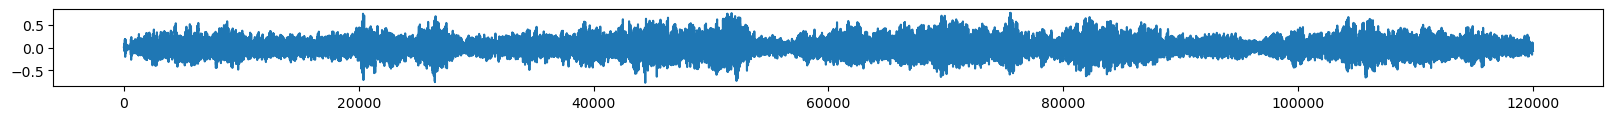

Finished epoch number 1 with a total of 10000 debug_seqs
 time: 2025-10-27 18:21:07.483220, epoch 2,  Loss: 0.2619
  Quantizer 0 Loss: 3.2661
  Quantizer 1 Loss: 3.5989
  Quantizer 2 Loss: 4.0999
  Quantizer 3 Loss: 4.4692
  Quantizer 4 Loss: 4.7025
  Quantizer 5 Loss: 4.8380
  Quantizer 6 Loss: 5.0429
  Quantizer 7 Loss: 5.1267
Latents embedded in 106 of the GRU input size of 128
Conditioning parameters embedded in 22 of the GRU input size of 128
DEVICE going in: model tensors cuda:0, enc_model cpu, c cuda:0
About toInitialize generator with c.shape = torch.Size([8])
params_seq.shape = torch.Size([10, 8])
plot the audio which has shape (120000,)


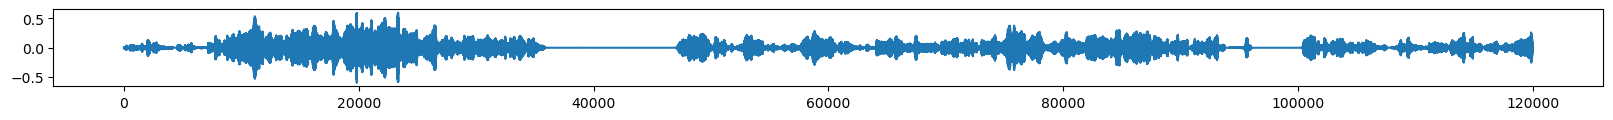

Finished epoch number 2 with a total of 10000 debug_seqs
 time: 2025-10-27 18:21:55.320926, epoch 3,  Loss: 0.2436
  Quantizer 0 Loss: 2.9621
  Quantizer 1 Loss: 3.3996
  Quantizer 2 Loss: 3.9463
  Quantizer 3 Loss: 4.3371
  Quantizer 4 Loss: 4.5875
  Quantizer 5 Loss: 4.7394
  Quantizer 6 Loss: 4.9524
  Quantizer 7 Loss: 5.0446
Latents embedded in 106 of the GRU input size of 128
Conditioning parameters embedded in 22 of the GRU input size of 128
DEVICE going in: model tensors cuda:0, enc_model cpu, c cuda:0
About toInitialize generator with c.shape = torch.Size([8])
params_seq.shape = torch.Size([10, 8])
plot the audio which has shape (120000,)


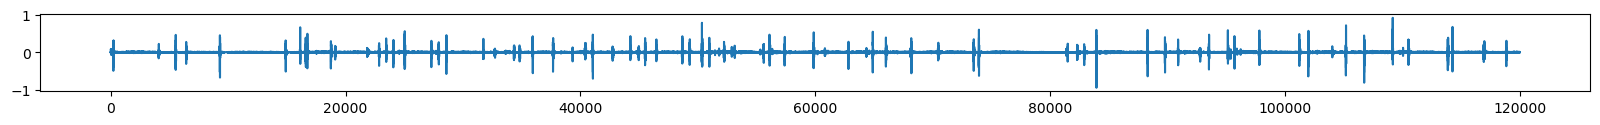

Finished epoch number 3 with a total of 10000 debug_seqs
 time: 2025-10-27 18:22:44.725393, epoch 4,  Loss: 0.2562
  Quantizer 0 Loss: 2.8064
  Quantizer 1 Loss: 3.2732
  Quantizer 2 Loss: 3.8459
  Quantizer 3 Loss: 4.2533
  Quantizer 4 Loss: 4.5187
  Quantizer 5 Loss: 4.6734
  Quantizer 6 Loss: 4.8934
  Quantizer 7 Loss: 4.9931
Latents embedded in 106 of the GRU input size of 128
Conditioning parameters embedded in 22 of the GRU input size of 128
DEVICE going in: model tensors cuda:0, enc_model cpu, c cuda:0
About toInitialize generator with c.shape = torch.Size([8])
params_seq.shape = torch.Size([10, 8])
plot the audio which has shape (120000,)


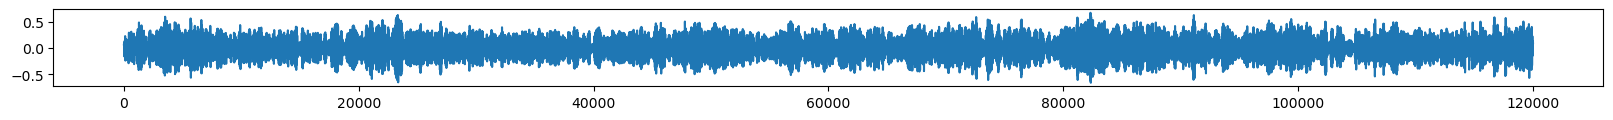

Finished epoch number 4 with a total of 10000 debug_seqs
 time: 2025-10-27 18:23:32.734853, epoch 5,  Loss: 0.2444
  Quantizer 0 Loss: 2.6785
  Quantizer 1 Loss: 3.1702
  Quantizer 2 Loss: 3.7691
  Quantizer 3 Loss: 4.1808
  Quantizer 4 Loss: 4.4554
  Quantizer 5 Loss: 4.6194
  Quantizer 6 Loss: 4.8393
  Quantizer 7 Loss: 4.9327
Latents embedded in 106 of the GRU input size of 128
Conditioning parameters embedded in 22 of the GRU input size of 128
DEVICE going in: model tensors cuda:0, enc_model cpu, c cuda:0
About toInitialize generator with c.shape = torch.Size([8])
params_seq.shape = torch.Size([10, 8])
plot the audio which has shape (120000,)


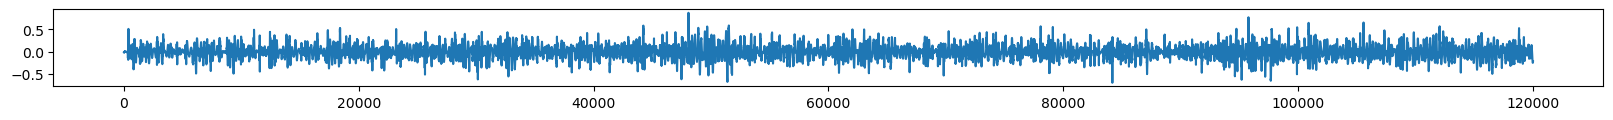

Finished epoch number 5 with a total of 10000 debug_seqs
 time: 2025-10-27 18:24:20.576341, epoch 6,  Loss: 0.2284
  Quantizer 0 Loss: 2.5822
  Quantizer 1 Loss: 3.0835
  Quantizer 2 Loss: 3.7108
  Quantizer 3 Loss: 4.1342
  Quantizer 4 Loss: 4.4112
  Quantizer 5 Loss: 4.5830
  Quantizer 6 Loss: 4.8045
  Quantizer 7 Loss: 4.9105
Latents embedded in 106 of the GRU input size of 128
Conditioning parameters embedded in 22 of the GRU input size of 128
DEVICE going in: model tensors cuda:0, enc_model cpu, c cuda:0
About toInitialize generator with c.shape = torch.Size([8])
params_seq.shape = torch.Size([10, 8])
plot the audio which has shape (120000,)


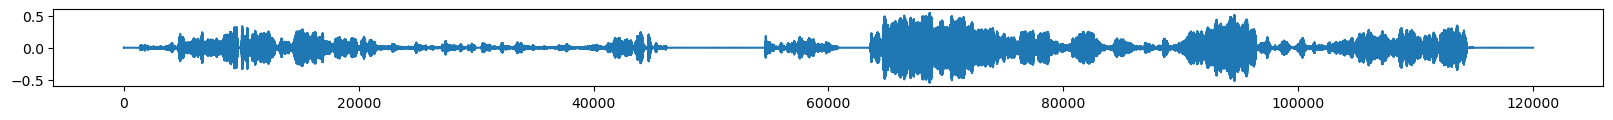

Finished epoch number 6 with a total of 10000 debug_seqs
 time: 2025-10-27 18:25:10.475538, epoch 7,  Loss: 0.2354
  Quantizer 0 Loss: 2.5137
  Quantizer 1 Loss: 3.0303
  Quantizer 2 Loss: 3.6629
  Quantizer 3 Loss: 4.0945
  Quantizer 4 Loss: 4.3810
  Quantizer 5 Loss: 4.5536
  Quantizer 6 Loss: 4.7791
  Quantizer 7 Loss: 4.8880
Latents embedded in 106 of the GRU input size of 128
Conditioning parameters embedded in 22 of the GRU input size of 128
DEVICE going in: model tensors cuda:0, enc_model cpu, c cuda:0
About toInitialize generator with c.shape = torch.Size([8])
params_seq.shape = torch.Size([10, 8])
plot the audio which has shape (120000,)


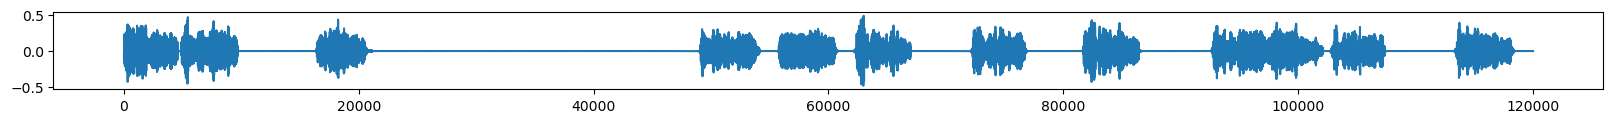

Finished epoch number 7 with a total of 10000 debug_seqs
 time: 2025-10-27 18:25:59.767705, epoch 8,  Loss: 0.2301
  Quantizer 0 Loss: 2.4607
  Quantizer 1 Loss: 2.9916
  Quantizer 2 Loss: 3.6344
  Quantizer 3 Loss: 4.0662
  Quantizer 4 Loss: 4.3620
  Quantizer 5 Loss: 4.5385
  Quantizer 6 Loss: 4.7630
  Quantizer 7 Loss: 4.8770
Latents embedded in 106 of the GRU input size of 128
Conditioning parameters embedded in 22 of the GRU input size of 128
DEVICE going in: model tensors cuda:0, enc_model cpu, c cuda:0
About toInitialize generator with c.shape = torch.Size([8])
params_seq.shape = torch.Size([10, 8])
plot the audio which has shape (120000,)


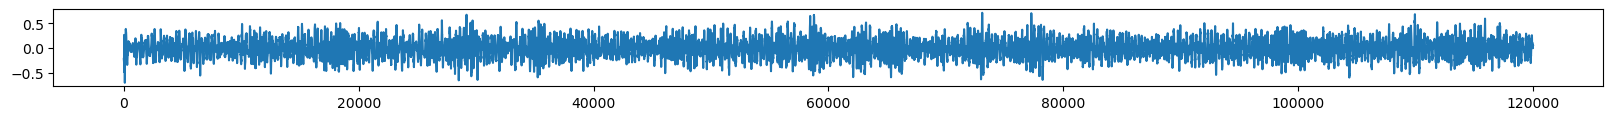

Finished epoch number 8 with a total of 10000 debug_seqs
 time: 2025-10-27 18:26:48.550562, epoch 9,  Loss: 0.2348
  Quantizer 0 Loss: 2.4356
  Quantizer 1 Loss: 2.9697
  Quantizer 2 Loss: 3.6111
  Quantizer 3 Loss: 4.0457
  Quantizer 4 Loss: 4.3376
  Quantizer 5 Loss: 4.5206
  Quantizer 6 Loss: 4.7468
  Quantizer 7 Loss: 4.8602
Latents embedded in 106 of the GRU input size of 128
Conditioning parameters embedded in 22 of the GRU input size of 128
DEVICE going in: model tensors cuda:0, enc_model cpu, c cuda:0
About toInitialize generator with c.shape = torch.Size([8])
params_seq.shape = torch.Size([10, 8])
plot the audio which has shape (120000,)


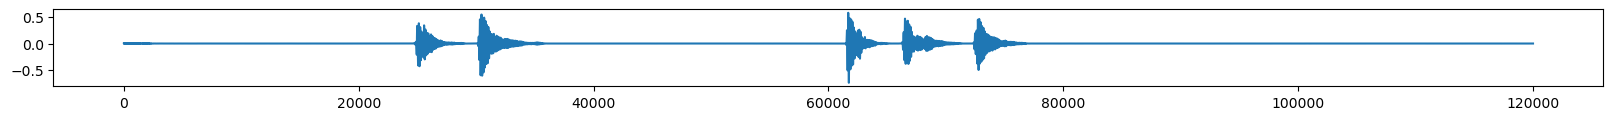

Finished epoch number 9 with a total of 10000 debug_seqs
 time: 2025-10-27 18:27:38.058735, epoch 10,  Loss: 0.2316
  Quantizer 0 Loss: 2.4182
  Quantizer 1 Loss: 2.9380
  Quantizer 2 Loss: 3.5913
  Quantizer 3 Loss: 4.0295
  Quantizer 4 Loss: 4.3253
  Quantizer 5 Loss: 4.5074
  Quantizer 6 Loss: 4.7383
  Quantizer 7 Loss: 4.8476
Latents embedded in 106 of the GRU input size of 128
Conditioning parameters embedded in 22 of the GRU input size of 128
DEVICE going in: model tensors cuda:0, enc_model cpu, c cuda:0
About toInitialize generator with c.shape = torch.Size([8])
params_seq.shape = torch.Size([10, 8])
plot the audio which has shape (120000,)


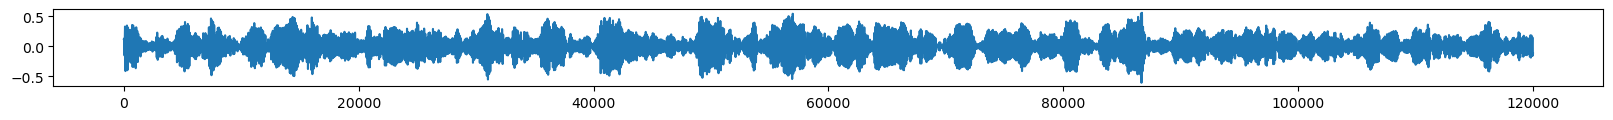

Finished epoch number 10 with a total of 10000 debug_seqs
 time: 2025-10-27 18:28:26.316692, epoch 11,  Loss: 0.2417
  Quantizer 0 Loss: 2.4063
  Quantizer 1 Loss: 2.9217
  Quantizer 2 Loss: 3.5804
  Quantizer 3 Loss: 4.0160
  Quantizer 4 Loss: 4.3099
  Quantizer 5 Loss: 4.4975
  Quantizer 6 Loss: 4.7265
  Quantizer 7 Loss: 4.8390
Latents embedded in 106 of the GRU input size of 128
Conditioning parameters embedded in 22 of the GRU input size of 128
DEVICE going in: model tensors cuda:0, enc_model cpu, c cuda:0
About toInitialize generator with c.shape = torch.Size([8])
params_seq.shape = torch.Size([10, 8])
plot the audio which has shape (120000,)


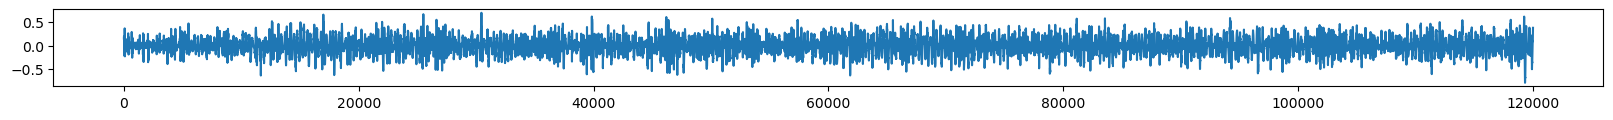

Finished epoch number 11 with a total of 10000 debug_seqs
 time: 2025-10-27 18:29:16.528415, epoch 12,  Loss: 0.2239
  Quantizer 0 Loss: 2.3637
  Quantizer 1 Loss: 2.8819
  Quantizer 2 Loss: 3.5405
  Quantizer 3 Loss: 3.9854
  Quantizer 4 Loss: 4.2798
  Quantizer 5 Loss: 4.4693
  Quantizer 6 Loss: 4.7037
  Quantizer 7 Loss: 4.8231
Latents embedded in 106 of the GRU input size of 128
Conditioning parameters embedded in 22 of the GRU input size of 128
DEVICE going in: model tensors cuda:0, enc_model cpu, c cuda:0
About toInitialize generator with c.shape = torch.Size([8])
params_seq.shape = torch.Size([10, 8])
plot the audio which has shape (120000,)


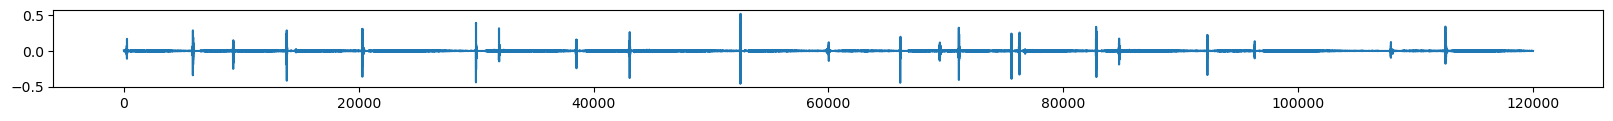

Finished epoch number 12 with a total of 10000 debug_seqs
 time: 2025-10-27 18:30:06.062036, epoch 13,  Loss: 0.2290
  Quantizer 0 Loss: 2.3482
  Quantizer 1 Loss: 2.8708
  Quantizer 2 Loss: 3.5198
  Quantizer 3 Loss: 3.9646
  Quantizer 4 Loss: 4.2617
  Quantizer 5 Loss: 4.4502
  Quantizer 6 Loss: 4.6825
  Quantizer 7 Loss: 4.7952
Latents embedded in 106 of the GRU input size of 128
Conditioning parameters embedded in 22 of the GRU input size of 128
DEVICE going in: model tensors cuda:0, enc_model cpu, c cuda:0
About toInitialize generator with c.shape = torch.Size([8])
params_seq.shape = torch.Size([10, 8])
plot the audio which has shape (120000,)


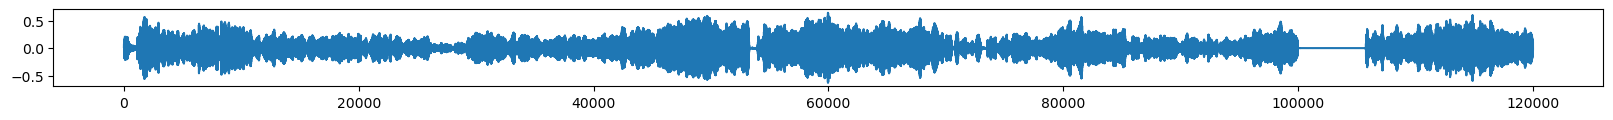

Finished epoch number 13 with a total of 10000 debug_seqs
 time: 2025-10-27 18:30:55.393483, epoch 14,  Loss: 0.2285
  Quantizer 0 Loss: 2.3462
  Quantizer 1 Loss: 2.8666
  Quantizer 2 Loss: 3.5210
  Quantizer 3 Loss: 3.9646
  Quantizer 4 Loss: 4.2651
  Quantizer 5 Loss: 4.4555
  Quantizer 6 Loss: 4.6869
  Quantizer 7 Loss: 4.8050
Latents embedded in 106 of the GRU input size of 128
Conditioning parameters embedded in 22 of the GRU input size of 128
DEVICE going in: model tensors cuda:0, enc_model cpu, c cuda:0
About toInitialize generator with c.shape = torch.Size([8])
params_seq.shape = torch.Size([10, 8])
plot the audio which has shape (120000,)


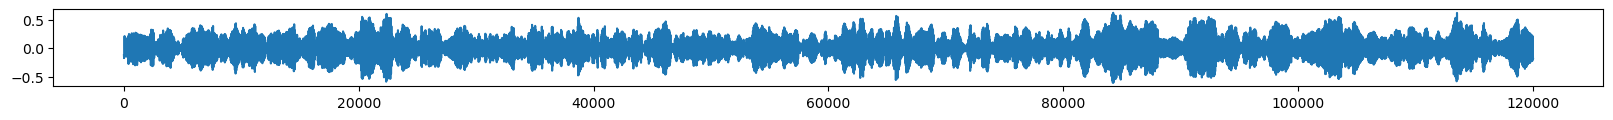

Finished epoch number 14 with a total of 10000 debug_seqs
 time: 2025-10-27 18:31:44.313972, epoch 15,  Loss: 0.2341
  Quantizer 0 Loss: 2.3248
  Quantizer 1 Loss: 2.8379
  Quantizer 2 Loss: 3.4853
  Quantizer 3 Loss: 3.9314
  Quantizer 4 Loss: 4.2257
  Quantizer 5 Loss: 4.4130
  Quantizer 6 Loss: 4.6504
  Quantizer 7 Loss: 4.7659
Latents embedded in 106 of the GRU input size of 128
Conditioning parameters embedded in 22 of the GRU input size of 128
DEVICE going in: model tensors cuda:0, enc_model cpu, c cuda:0
About toInitialize generator with c.shape = torch.Size([8])
params_seq.shape = torch.Size([10, 8])
plot the audio which has shape (120000,)


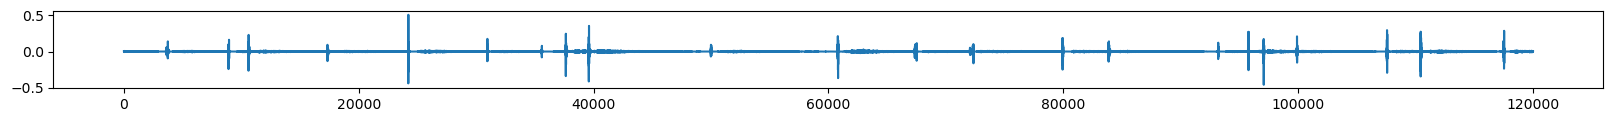

Finished epoch number 15 with a total of 10000 debug_seqs
 time: 2025-10-27 18:32:32.849630, epoch 16,  Loss: 0.2267
  Quantizer 0 Loss: 2.3326
  Quantizer 1 Loss: 2.8473
  Quantizer 2 Loss: 3.5022
  Quantizer 3 Loss: 3.9489
  Quantizer 4 Loss: 4.2412
  Quantizer 5 Loss: 4.4341
  Quantizer 6 Loss: 4.6676
  Quantizer 7 Loss: 4.7844
Latents embedded in 106 of the GRU input size of 128
Conditioning parameters embedded in 22 of the GRU input size of 128
DEVICE going in: model tensors cuda:0, enc_model cpu, c cuda:0
About toInitialize generator with c.shape = torch.Size([8])
params_seq.shape = torch.Size([10, 8])
plot the audio which has shape (120000,)


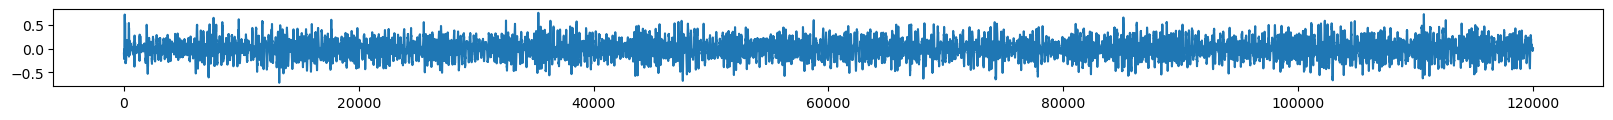

Finished epoch number 16 with a total of 10000 debug_seqs
 time: 2025-10-27 18:33:22.131805, epoch 17,  Loss: 0.2216
  Quantizer 0 Loss: 2.3175
  Quantizer 1 Loss: 2.8380
  Quantizer 2 Loss: 3.4819
  Quantizer 3 Loss: 3.9294
  Quantizer 4 Loss: 4.2308
  Quantizer 5 Loss: 4.4208
  Quantizer 6 Loss: 4.6529
  Quantizer 7 Loss: 4.7706
Latents embedded in 106 of the GRU input size of 128
Conditioning parameters embedded in 22 of the GRU input size of 128
DEVICE going in: model tensors cuda:0, enc_model cpu, c cuda:0
About toInitialize generator with c.shape = torch.Size([8])
params_seq.shape = torch.Size([10, 8])
plot the audio which has shape (120000,)


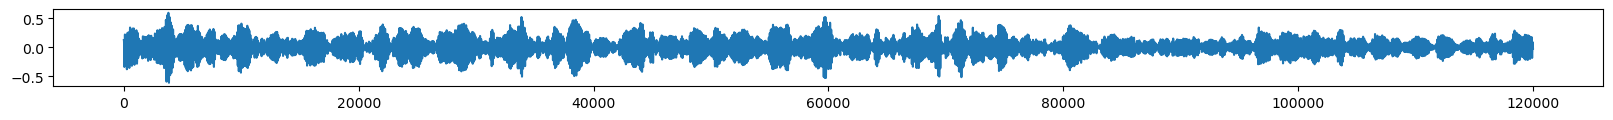

Finished epoch number 17 with a total of 10000 debug_seqs
 time: 2025-10-27 18:34:12.812793, epoch 18,  Loss: 0.2286
  Quantizer 0 Loss: 2.3153
  Quantizer 1 Loss: 2.8228
  Quantizer 2 Loss: 3.4814
  Quantizer 3 Loss: 3.9263
  Quantizer 4 Loss: 4.2308
  Quantizer 5 Loss: 4.4175
  Quantizer 6 Loss: 4.6538
  Quantizer 7 Loss: 4.7757
Latents embedded in 106 of the GRU input size of 128
Conditioning parameters embedded in 22 of the GRU input size of 128
DEVICE going in: model tensors cuda:0, enc_model cpu, c cuda:0
About toInitialize generator with c.shape = torch.Size([8])
params_seq.shape = torch.Size([10, 8])
plot the audio which has shape (120000,)


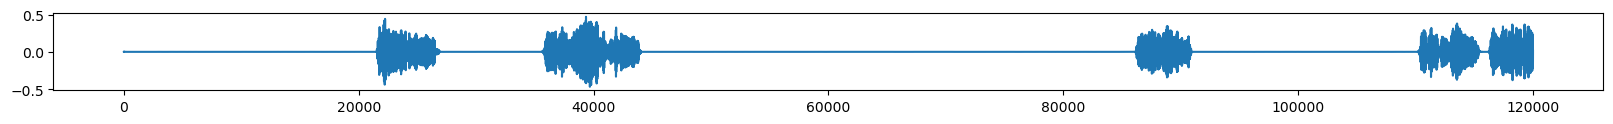

Finished epoch number 18 with a total of 10000 debug_seqs
 time: 2025-10-27 18:35:02.201934, epoch 19,  Loss: 0.2224
  Quantizer 0 Loss: 2.3012
  Quantizer 1 Loss: 2.8169
  Quantizer 2 Loss: 3.4694
  Quantizer 3 Loss: 3.9141
  Quantizer 4 Loss: 4.2168
  Quantizer 5 Loss: 4.4092
  Quantizer 6 Loss: 4.6420
  Quantizer 7 Loss: 4.7624
Latents embedded in 106 of the GRU input size of 128
Conditioning parameters embedded in 22 of the GRU input size of 128
DEVICE going in: model tensors cuda:0, enc_model cpu, c cuda:0
About toInitialize generator with c.shape = torch.Size([8])
params_seq.shape = torch.Size([10, 8])
plot the audio which has shape (120000,)


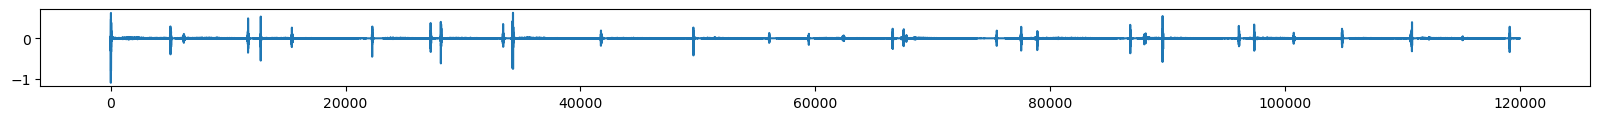

Finished epoch number 19 with a total of 10000 debug_seqs
 time: 2025-10-27 18:35:51.495115, epoch 20,  Loss: 0.2272
  Quantizer 0 Loss: 2.3042
  Quantizer 1 Loss: 2.8163
  Quantizer 2 Loss: 3.4663
  Quantizer 3 Loss: 3.9162
  Quantizer 4 Loss: 4.2158
  Quantizer 5 Loss: 4.4109
  Quantizer 6 Loss: 4.6442
  Quantizer 7 Loss: 4.7691
Latents embedded in 106 of the GRU input size of 128
Conditioning parameters embedded in 22 of the GRU input size of 128
DEVICE going in: model tensors cuda:0, enc_model cpu, c cuda:0
About toInitialize generator with c.shape = torch.Size([8])
params_seq.shape = torch.Size([10, 8])
plot the audio which has shape (120000,)


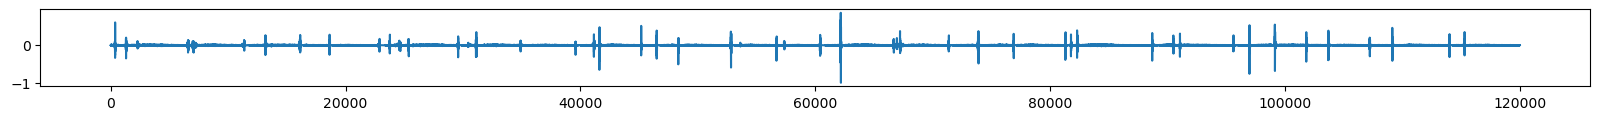

Finished epoch number 20 with a total of 10000 debug_seqs
 time: 2025-10-27 18:36:40.694805, epoch 21,  Loss: 0.2236
  Quantizer 0 Loss: 2.2845
  Quantizer 1 Loss: 2.8004
  Quantizer 2 Loss: 3.4599
  Quantizer 3 Loss: 3.9010
  Quantizer 4 Loss: 4.2161
  Quantizer 5 Loss: 4.4101
  Quantizer 6 Loss: 4.6432
  Quantizer 7 Loss: 4.7708
Latents embedded in 106 of the GRU input size of 128
Conditioning parameters embedded in 22 of the GRU input size of 128
DEVICE going in: model tensors cuda:0, enc_model cpu, c cuda:0
About toInitialize generator with c.shape = torch.Size([8])
params_seq.shape = torch.Size([10, 8])
plot the audio which has shape (120000,)


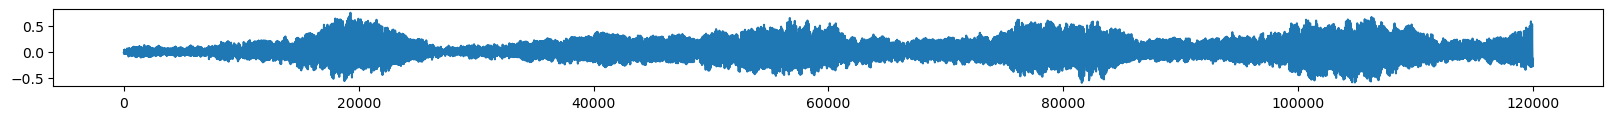

Finished epoch number 21 with a total of 10000 debug_seqs
 time: 2025-10-27 18:37:30.434345, epoch 22,  Loss: 0.2253
  Quantizer 0 Loss: 2.2842
  Quantizer 1 Loss: 2.7956
  Quantizer 2 Loss: 3.4498
  Quantizer 3 Loss: 3.8972
  Quantizer 4 Loss: 4.1977
  Quantizer 5 Loss: 4.3965
  Quantizer 6 Loss: 4.6359
  Quantizer 7 Loss: 4.7600
Latents embedded in 106 of the GRU input size of 128
Conditioning parameters embedded in 22 of the GRU input size of 128
DEVICE going in: model tensors cuda:0, enc_model cpu, c cuda:0
About toInitialize generator with c.shape = torch.Size([8])
params_seq.shape = torch.Size([10, 8])
plot the audio which has shape (120000,)


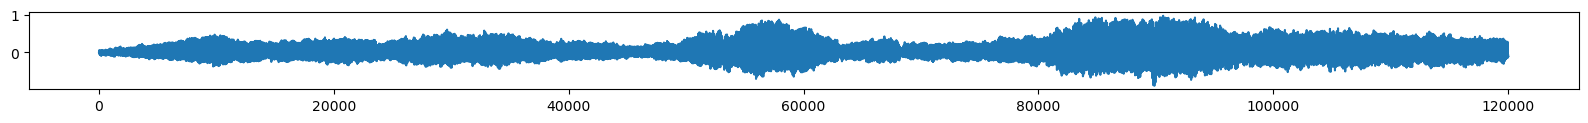

Finished epoch number 22 with a total of 10000 debug_seqs
 time: 2025-10-27 18:38:19.098835, epoch 23,  Loss: 0.2218
  Quantizer 0 Loss: 2.2882
  Quantizer 1 Loss: 2.8005
  Quantizer 2 Loss: 3.4506
  Quantizer 3 Loss: 3.8981
  Quantizer 4 Loss: 4.2018
  Quantizer 5 Loss: 4.3949
  Quantizer 6 Loss: 4.6322
  Quantizer 7 Loss: 4.7544
Latents embedded in 106 of the GRU input size of 128
Conditioning parameters embedded in 22 of the GRU input size of 128
DEVICE going in: model tensors cuda:0, enc_model cpu, c cuda:0
About toInitialize generator with c.shape = torch.Size([8])
params_seq.shape = torch.Size([10, 8])
plot the audio which has shape (120000,)


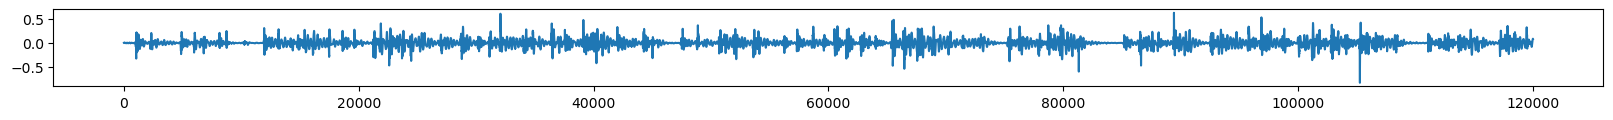

Finished epoch number 23 with a total of 10000 debug_seqs
 time: 2025-10-27 18:39:09.176294, epoch 24,  Loss: 0.2263
  Quantizer 0 Loss: 2.2932
  Quantizer 1 Loss: 2.7962
  Quantizer 2 Loss: 3.4514
  Quantizer 3 Loss: 3.8975
  Quantizer 4 Loss: 4.2016
  Quantizer 5 Loss: 4.3955
  Quantizer 6 Loss: 4.6303
  Quantizer 7 Loss: 4.7551
Latents embedded in 106 of the GRU input size of 128
Conditioning parameters embedded in 22 of the GRU input size of 128
DEVICE going in: model tensors cuda:0, enc_model cpu, c cuda:0
About toInitialize generator with c.shape = torch.Size([8])
params_seq.shape = torch.Size([10, 8])
plot the audio which has shape (120000,)


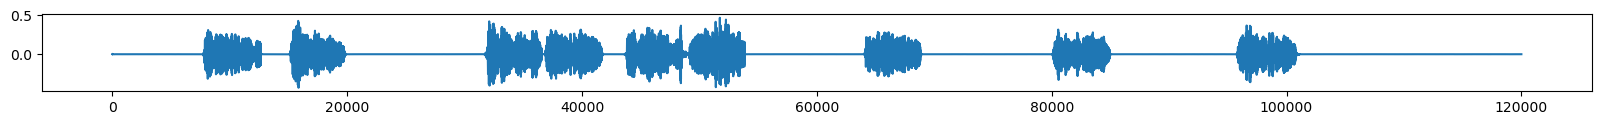

Finished epoch number 24 with a total of 10000 debug_seqs
 time: 2025-10-27 18:39:58.889150, epoch 25,  Loss: 0.2228
  Quantizer 0 Loss: 2.2774
  Quantizer 1 Loss: 2.7859
  Quantizer 2 Loss: 3.4414
  Quantizer 3 Loss: 3.8853
  Quantizer 4 Loss: 4.1929
  Quantizer 5 Loss: 4.3847
  Quantizer 6 Loss: 4.6214
  Quantizer 7 Loss: 4.7447
Latents embedded in 106 of the GRU input size of 128
Conditioning parameters embedded in 22 of the GRU input size of 128
DEVICE going in: model tensors cuda:0, enc_model cpu, c cuda:0
About toInitialize generator with c.shape = torch.Size([8])
params_seq.shape = torch.Size([10, 8])
plot the audio which has shape (120000,)


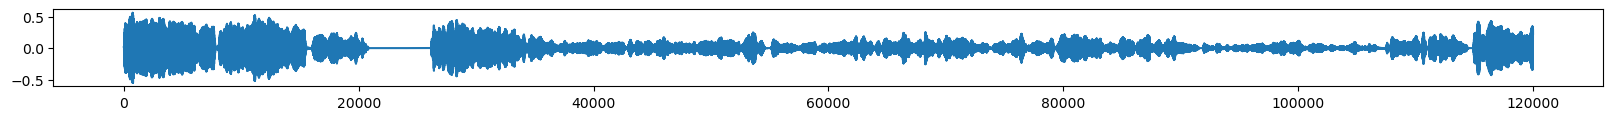

Saved checkpoint at epoch 25
Finished epoch number 25 with a total of 10000 debug_seqs
 time: 2025-10-27 18:40:48.055341, epoch 26,  Loss: 0.2540
  Quantizer 0 Loss: 2.4008
  Quantizer 1 Loss: 3.4314
  Quantizer 2 Loss: 4.1107
  Quantizer 3 Loss: 4.5379
  Quantizer 4 Loss: 4.8134
  Quantizer 5 Loss: 4.9898
  Quantizer 6 Loss: 5.2057
  Quantizer 7 Loss: 5.2923
Latents embedded in 106 of the GRU input size of 128
Conditioning parameters embedded in 22 of the GRU input size of 128
DEVICE going in: model tensors cuda:0, enc_model cpu, c cuda:0
About toInitialize generator with c.shape = torch.Size([8])
params_seq.shape = torch.Size([10, 8])
plot the audio which has shape (120000,)


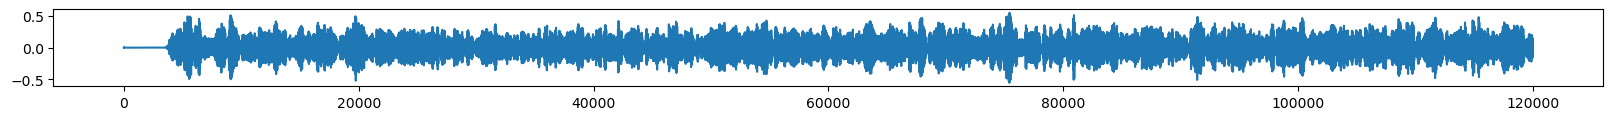

Finished epoch number 26 with a total of 10000 debug_seqs
 time: 2025-10-27 18:41:38.081114, epoch 27,  Loss: 0.2502
  Quantizer 0 Loss: 2.3103
  Quantizer 1 Loss: 3.2904
  Quantizer 2 Loss: 4.0038
  Quantizer 3 Loss: 4.4489
  Quantizer 4 Loss: 4.7377
  Quantizer 5 Loss: 4.9135
  Quantizer 6 Loss: 5.1366
  Quantizer 7 Loss: 5.2351
Latents embedded in 106 of the GRU input size of 128
Conditioning parameters embedded in 22 of the GRU input size of 128
DEVICE going in: model tensors cuda:0, enc_model cpu, c cuda:0
About toInitialize generator with c.shape = torch.Size([8])
params_seq.shape = torch.Size([10, 8])
plot the audio which has shape (120000,)


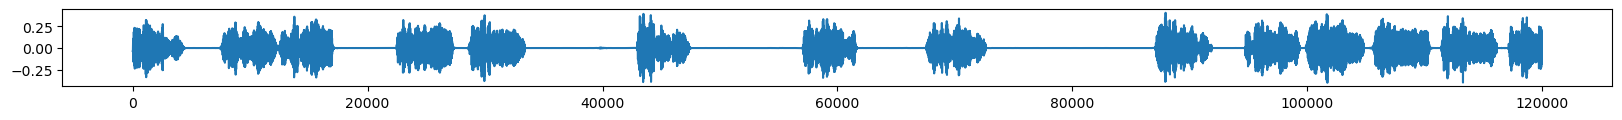

Finished epoch number 27 with a total of 10000 debug_seqs
 time: 2025-10-27 18:42:27.367137, epoch 28,  Loss: 0.2477
  Quantizer 0 Loss: 2.2991
  Quantizer 1 Loss: 3.2446
  Quantizer 2 Loss: 3.9772
  Quantizer 3 Loss: 4.4280
  Quantizer 4 Loss: 4.7235
  Quantizer 5 Loss: 4.9021
  Quantizer 6 Loss: 5.1253
  Quantizer 7 Loss: 5.2242
Latents embedded in 106 of the GRU input size of 128
Conditioning parameters embedded in 22 of the GRU input size of 128
DEVICE going in: model tensors cuda:0, enc_model cpu, c cuda:0
About toInitialize generator with c.shape = torch.Size([8])
params_seq.shape = torch.Size([10, 8])
plot the audio which has shape (120000,)


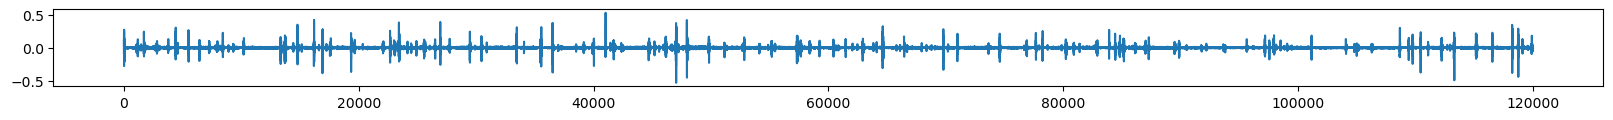

Finished epoch number 28 with a total of 10000 debug_seqs
 time: 2025-10-27 18:43:16.478980, epoch 29,  Loss: 0.2516
  Quantizer 0 Loss: 2.2813
  Quantizer 1 Loss: 3.2232
  Quantizer 2 Loss: 3.9617
  Quantizer 3 Loss: 4.4125
  Quantizer 4 Loss: 4.7135
  Quantizer 5 Loss: 4.8900
  Quantizer 6 Loss: 5.1167
  Quantizer 7 Loss: 5.2117
Latents embedded in 106 of the GRU input size of 128
Conditioning parameters embedded in 22 of the GRU input size of 128
DEVICE going in: model tensors cuda:0, enc_model cpu, c cuda:0
About toInitialize generator with c.shape = torch.Size([8])
params_seq.shape = torch.Size([10, 8])
plot the audio which has shape (120000,)


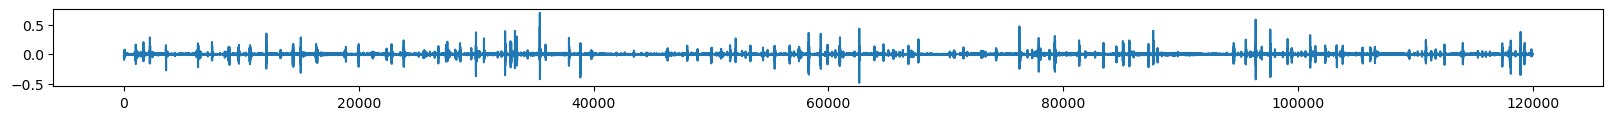

Finished epoch number 29 with a total of 10000 debug_seqs
 time: 2025-10-27 18:44:06.540482, epoch 30,  Loss: 0.2515
  Quantizer 0 Loss: 2.2748
  Quantizer 1 Loss: 3.1993
  Quantizer 2 Loss: 3.9441
  Quantizer 3 Loss: 4.4043
  Quantizer 4 Loss: 4.7000
  Quantizer 5 Loss: 4.8853
  Quantizer 6 Loss: 5.1086
  Quantizer 7 Loss: 5.2073
Latents embedded in 106 of the GRU input size of 128
Conditioning parameters embedded in 22 of the GRU input size of 128
DEVICE going in: model tensors cuda:0, enc_model cpu, c cuda:0
About toInitialize generator with c.shape = torch.Size([8])
params_seq.shape = torch.Size([10, 8])
plot the audio which has shape (120000,)


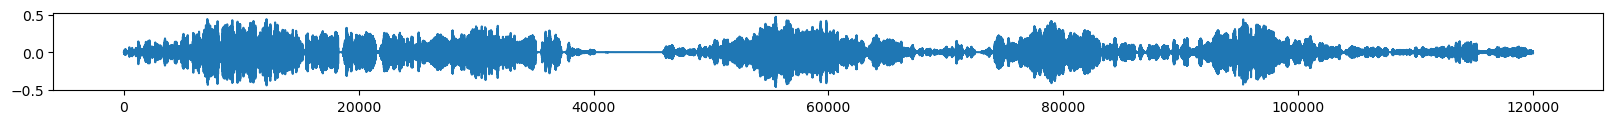

Finished epoch number 30 with a total of 10000 debug_seqs
 time: 2025-10-27 18:44:55.528791, epoch 31,  Loss: 0.2500
  Quantizer 0 Loss: 2.2625
  Quantizer 1 Loss: 3.1865
  Quantizer 2 Loss: 3.9300
  Quantizer 3 Loss: 4.3852
  Quantizer 4 Loss: 4.6869
  Quantizer 5 Loss: 4.8666
  Quantizer 6 Loss: 5.0915
  Quantizer 7 Loss: 5.1901
Latents embedded in 106 of the GRU input size of 128
Conditioning parameters embedded in 22 of the GRU input size of 128
DEVICE going in: model tensors cuda:0, enc_model cpu, c cuda:0
About toInitialize generator with c.shape = torch.Size([8])
params_seq.shape = torch.Size([10, 8])
plot the audio which has shape (120000,)


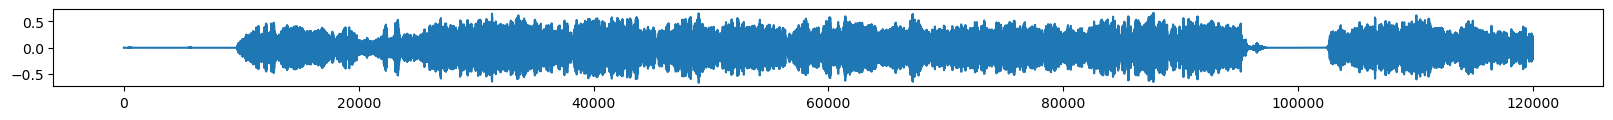

Finished epoch number 31 with a total of 10000 debug_seqs
 time: 2025-10-27 18:45:45.163491, epoch 32,  Loss: 0.2545
  Quantizer 0 Loss: 2.2664
  Quantizer 1 Loss: 3.1988
  Quantizer 2 Loss: 3.9411
  Quantizer 3 Loss: 4.3998
  Quantizer 4 Loss: 4.6975
  Quantizer 5 Loss: 4.8854
  Quantizer 6 Loss: 5.1134
  Quantizer 7 Loss: 5.2129
Latents embedded in 106 of the GRU input size of 128
Conditioning parameters embedded in 22 of the GRU input size of 128
DEVICE going in: model tensors cuda:0, enc_model cpu, c cuda:0
About toInitialize generator with c.shape = torch.Size([8])
params_seq.shape = torch.Size([10, 8])
plot the audio which has shape (120000,)


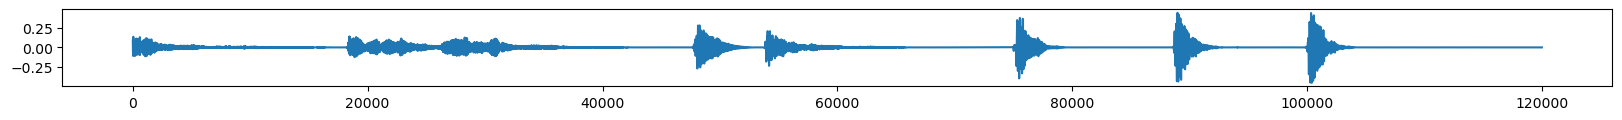

Finished epoch number 32 with a total of 10000 debug_seqs
 time: 2025-10-27 18:46:35.282143, epoch 33,  Loss: 0.2497
  Quantizer 0 Loss: 2.2546
  Quantizer 1 Loss: 3.1734
  Quantizer 2 Loss: 3.9177
  Quantizer 3 Loss: 4.3817
  Quantizer 4 Loss: 4.6801
  Quantizer 5 Loss: 4.8689
  Quantizer 6 Loss: 5.0924
  Quantizer 7 Loss: 5.1912
Latents embedded in 106 of the GRU input size of 128
Conditioning parameters embedded in 22 of the GRU input size of 128
DEVICE going in: model tensors cuda:0, enc_model cpu, c cuda:0
About toInitialize generator with c.shape = torch.Size([8])
params_seq.shape = torch.Size([10, 8])
plot the audio which has shape (120000,)


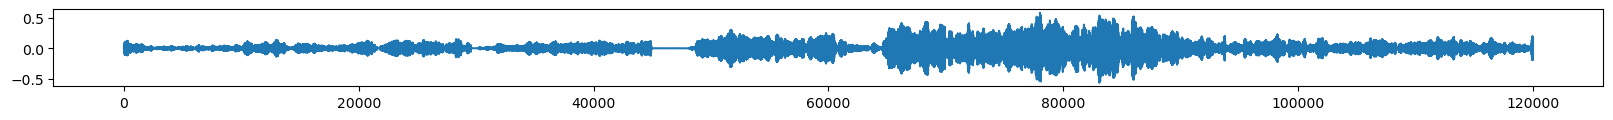

Finished epoch number 33 with a total of 10000 debug_seqs
 time: 2025-10-27 18:47:25.020819, epoch 34,  Loss: 0.2510
  Quantizer 0 Loss: 2.2456
  Quantizer 1 Loss: 3.1614
  Quantizer 2 Loss: 3.9120
  Quantizer 3 Loss: 4.3758
  Quantizer 4 Loss: 4.6774
  Quantizer 5 Loss: 4.8627
  Quantizer 6 Loss: 5.0912
  Quantizer 7 Loss: 5.1864
Latents embedded in 106 of the GRU input size of 128
Conditioning parameters embedded in 22 of the GRU input size of 128
DEVICE going in: model tensors cuda:0, enc_model cpu, c cuda:0
About toInitialize generator with c.shape = torch.Size([8])
params_seq.shape = torch.Size([10, 8])
plot the audio which has shape (120000,)


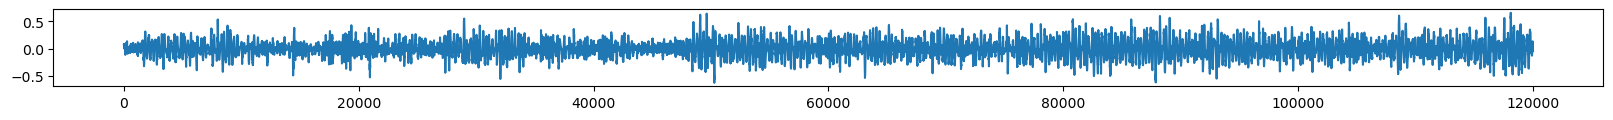

Finished epoch number 34 with a total of 10000 debug_seqs
 time: 2025-10-27 18:48:14.838920, epoch 35,  Loss: 0.2466
  Quantizer 0 Loss: 2.2506
  Quantizer 1 Loss: 3.1665
  Quantizer 2 Loss: 3.9145
  Quantizer 3 Loss: 4.3770
  Quantizer 4 Loss: 4.6786
  Quantizer 5 Loss: 4.8646
  Quantizer 6 Loss: 5.0893
  Quantizer 7 Loss: 5.1861
Latents embedded in 106 of the GRU input size of 128
Conditioning parameters embedded in 22 of the GRU input size of 128
DEVICE going in: model tensors cuda:0, enc_model cpu, c cuda:0
About toInitialize generator with c.shape = torch.Size([8])
params_seq.shape = torch.Size([10, 8])
plot the audio which has shape (120000,)


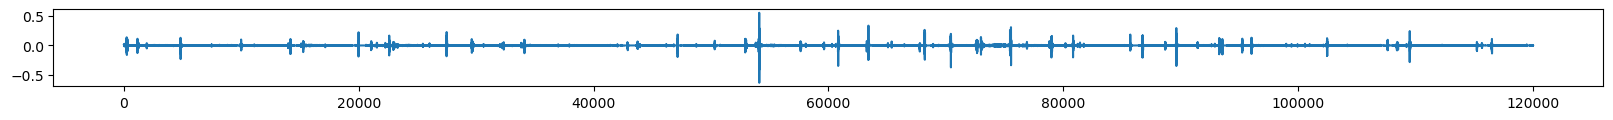

Finished epoch number 35 with a total of 10000 debug_seqs
 time: 2025-10-27 18:49:05.554431, epoch 36,  Loss: 0.2424
  Quantizer 0 Loss: 2.2560
  Quantizer 1 Loss: 3.1717
  Quantizer 2 Loss: 3.9231
  Quantizer 3 Loss: 4.3838
  Quantizer 4 Loss: 4.6856
  Quantizer 5 Loss: 4.8701
  Quantizer 6 Loss: 5.1010
  Quantizer 7 Loss: 5.1985
Latents embedded in 106 of the GRU input size of 128
Conditioning parameters embedded in 22 of the GRU input size of 128
DEVICE going in: model tensors cuda:0, enc_model cpu, c cuda:0
About toInitialize generator with c.shape = torch.Size([8])
params_seq.shape = torch.Size([10, 8])
plot the audio which has shape (120000,)


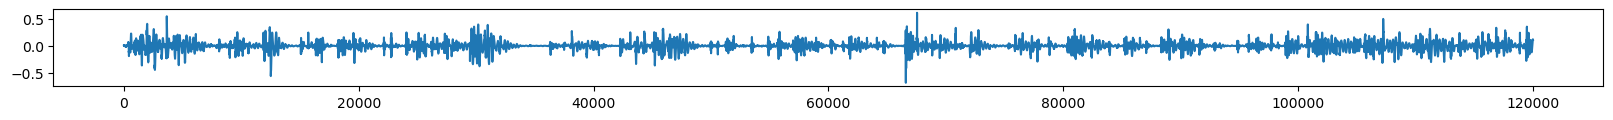

Finished epoch number 36 with a total of 10000 debug_seqs
 time: 2025-10-27 18:49:55.124566, epoch 37,  Loss: 0.2451
  Quantizer 0 Loss: 2.2608
  Quantizer 1 Loss: 3.1850
  Quantizer 2 Loss: 3.9326
  Quantizer 3 Loss: 4.3930
  Quantizer 4 Loss: 4.6956
  Quantizer 5 Loss: 4.8844
  Quantizer 6 Loss: 5.1122
  Quantizer 7 Loss: 5.2096
Latents embedded in 106 of the GRU input size of 128
Conditioning parameters embedded in 22 of the GRU input size of 128
DEVICE going in: model tensors cuda:0, enc_model cpu, c cuda:0
About toInitialize generator with c.shape = torch.Size([8])
params_seq.shape = torch.Size([10, 8])
plot the audio which has shape (120000,)


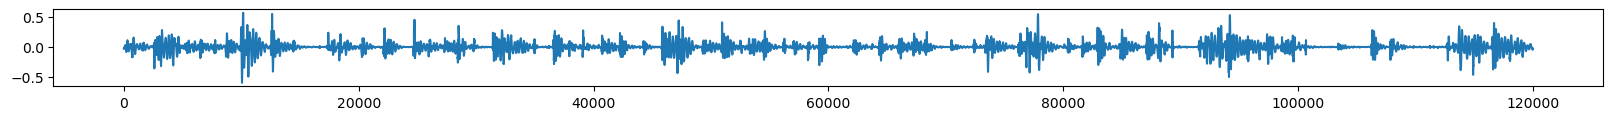

Finished epoch number 37 with a total of 10000 debug_seqs
 time: 2025-10-27 18:50:44.971402, epoch 38,  Loss: 0.2420
  Quantizer 0 Loss: 2.2567
  Quantizer 1 Loss: 3.1696
  Quantizer 2 Loss: 3.9222
  Quantizer 3 Loss: 4.3900
  Quantizer 4 Loss: 4.6917
  Quantizer 5 Loss: 4.8813
  Quantizer 6 Loss: 5.1027
  Quantizer 7 Loss: 5.2009
Latents embedded in 106 of the GRU input size of 128
Conditioning parameters embedded in 22 of the GRU input size of 128
DEVICE going in: model tensors cuda:0, enc_model cpu, c cuda:0
About toInitialize generator with c.shape = torch.Size([8])
params_seq.shape = torch.Size([10, 8])
plot the audio which has shape (120000,)


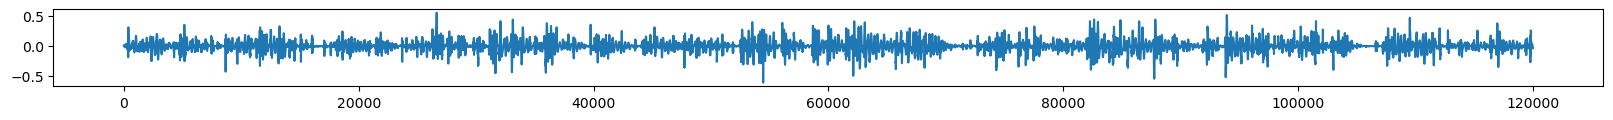

Finished epoch number 38 with a total of 10000 debug_seqs
 time: 2025-10-27 18:51:35.181361, epoch 39,  Loss: 0.2440
  Quantizer 0 Loss: 2.2425
  Quantizer 1 Loss: 3.1626
  Quantizer 2 Loss: 3.9066
  Quantizer 3 Loss: 4.3793
  Quantizer 4 Loss: 4.6744
  Quantizer 5 Loss: 4.8626
  Quantizer 6 Loss: 5.0885
  Quantizer 7 Loss: 5.1860
Latents embedded in 106 of the GRU input size of 128
Conditioning parameters embedded in 22 of the GRU input size of 128
DEVICE going in: model tensors cuda:0, enc_model cpu, c cuda:0
About toInitialize generator with c.shape = torch.Size([8])
params_seq.shape = torch.Size([10, 8])
plot the audio which has shape (120000,)


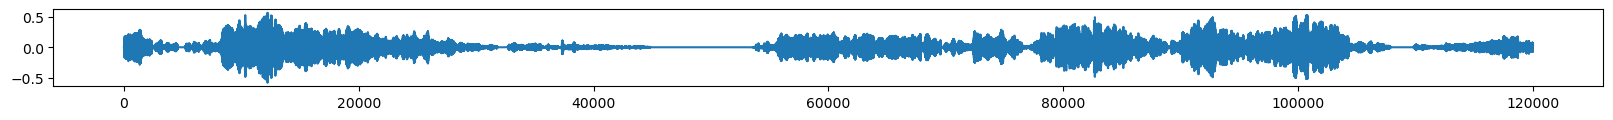

Finished epoch number 39 with a total of 10000 debug_seqs
 time: 2025-10-27 18:52:24.576756, epoch 40,  Loss: 0.2460
  Quantizer 0 Loss: 2.2374
  Quantizer 1 Loss: 3.1551
  Quantizer 2 Loss: 3.9097
  Quantizer 3 Loss: 4.3706
  Quantizer 4 Loss: 4.6691
  Quantizer 5 Loss: 4.8595
  Quantizer 6 Loss: 5.0863
  Quantizer 7 Loss: 5.1900
Latents embedded in 106 of the GRU input size of 128
Conditioning parameters embedded in 22 of the GRU input size of 128
DEVICE going in: model tensors cuda:0, enc_model cpu, c cuda:0
About toInitialize generator with c.shape = torch.Size([8])
params_seq.shape = torch.Size([10, 8])
plot the audio which has shape (120000,)


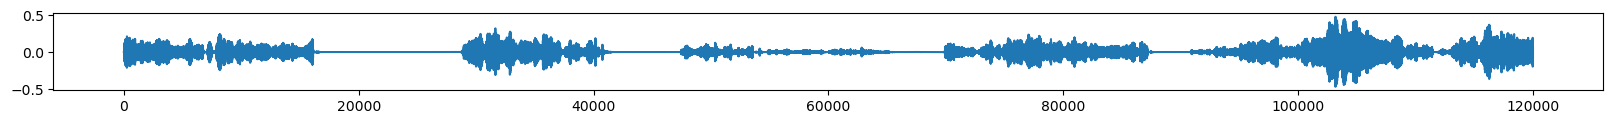

Finished epoch number 40 with a total of 10000 debug_seqs
 time: 2025-10-27 18:53:14.392023, epoch 41,  Loss: 0.2477
  Quantizer 0 Loss: 2.2313
  Quantizer 1 Loss: 3.1460
  Quantizer 2 Loss: 3.8935
  Quantizer 3 Loss: 4.3608
  Quantizer 4 Loss: 4.6741
  Quantizer 5 Loss: 4.8558
  Quantizer 6 Loss: 5.0894
  Quantizer 7 Loss: 5.1906
Latents embedded in 106 of the GRU input size of 128
Conditioning parameters embedded in 22 of the GRU input size of 128
DEVICE going in: model tensors cuda:0, enc_model cpu, c cuda:0
About toInitialize generator with c.shape = torch.Size([8])
params_seq.shape = torch.Size([10, 8])
plot the audio which has shape (120000,)


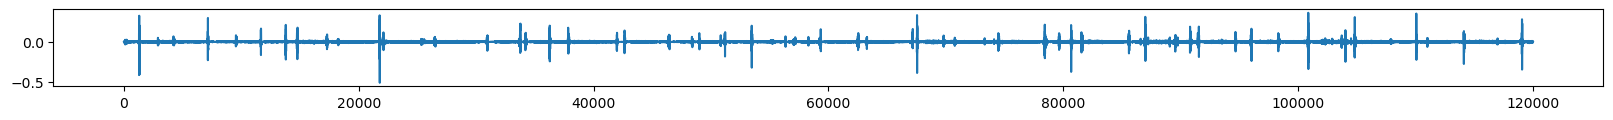

Finished epoch number 41 with a total of 10000 debug_seqs
 time: 2025-10-27 18:54:03.159206, epoch 42,  Loss: 0.2523
  Quantizer 0 Loss: 2.2503
  Quantizer 1 Loss: 3.1651
  Quantizer 2 Loss: 3.9089
  Quantizer 3 Loss: 4.3712
  Quantizer 4 Loss: 4.6699
  Quantizer 5 Loss: 4.8554
  Quantizer 6 Loss: 5.0839
  Quantizer 7 Loss: 5.1823
Latents embedded in 106 of the GRU input size of 128
Conditioning parameters embedded in 22 of the GRU input size of 128
DEVICE going in: model tensors cuda:0, enc_model cpu, c cuda:0
About toInitialize generator with c.shape = torch.Size([8])
params_seq.shape = torch.Size([10, 8])
plot the audio which has shape (120000,)


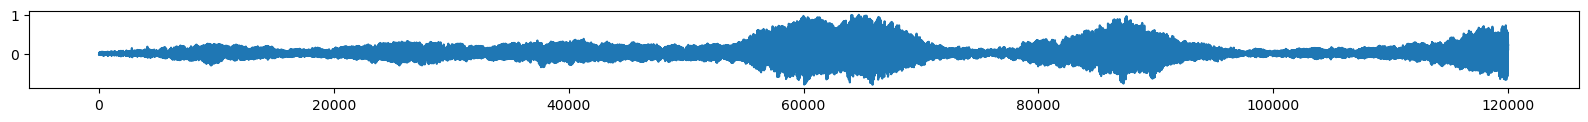

Finished epoch number 42 with a total of 10000 debug_seqs
 time: 2025-10-27 18:54:52.787208, epoch 43,  Loss: 0.2491
  Quantizer 0 Loss: 2.2368
  Quantizer 1 Loss: 3.1500
  Quantizer 2 Loss: 3.9005
  Quantizer 3 Loss: 4.3661
  Quantizer 4 Loss: 4.6702
  Quantizer 5 Loss: 4.8627
  Quantizer 6 Loss: 5.0882
  Quantizer 7 Loss: 5.1899
Latents embedded in 106 of the GRU input size of 128
Conditioning parameters embedded in 22 of the GRU input size of 128
DEVICE going in: model tensors cuda:0, enc_model cpu, c cuda:0
About toInitialize generator with c.shape = torch.Size([8])
params_seq.shape = torch.Size([10, 8])
plot the audio which has shape (120000,)


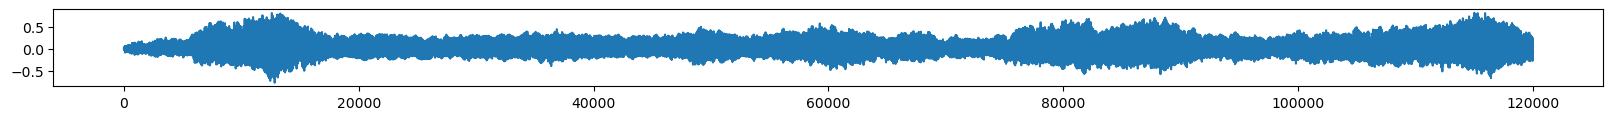

Finished epoch number 43 with a total of 10000 debug_seqs
 time: 2025-10-27 18:55:42.835272, epoch 44,  Loss: 0.2433
  Quantizer 0 Loss: 2.2292
  Quantizer 1 Loss: 3.1402
  Quantizer 2 Loss: 3.8917
  Quantizer 3 Loss: 4.3617
  Quantizer 4 Loss: 4.6608
  Quantizer 5 Loss: 4.8547
  Quantizer 6 Loss: 5.0785
  Quantizer 7 Loss: 5.1822
Latents embedded in 106 of the GRU input size of 128
Conditioning parameters embedded in 22 of the GRU input size of 128
DEVICE going in: model tensors cuda:0, enc_model cpu, c cuda:0
About toInitialize generator with c.shape = torch.Size([8])
params_seq.shape = torch.Size([10, 8])
plot the audio which has shape (120000,)


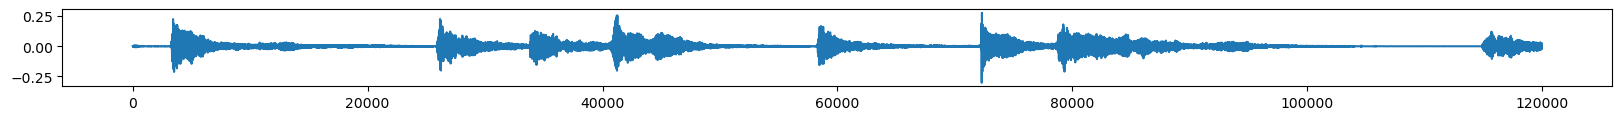

Finished epoch number 44 with a total of 10000 debug_seqs
 time: 2025-10-27 18:56:32.629565, epoch 45,  Loss: 0.2448
  Quantizer 0 Loss: 2.2292
  Quantizer 1 Loss: 3.1536
  Quantizer 2 Loss: 3.8924
  Quantizer 3 Loss: 4.3635
  Quantizer 4 Loss: 4.6670
  Quantizer 5 Loss: 4.8572
  Quantizer 6 Loss: 5.0854
  Quantizer 7 Loss: 5.1870
Latents embedded in 106 of the GRU input size of 128
Conditioning parameters embedded in 22 of the GRU input size of 128
DEVICE going in: model tensors cuda:0, enc_model cpu, c cuda:0
About toInitialize generator with c.shape = torch.Size([8])
params_seq.shape = torch.Size([10, 8])
plot the audio which has shape (120000,)


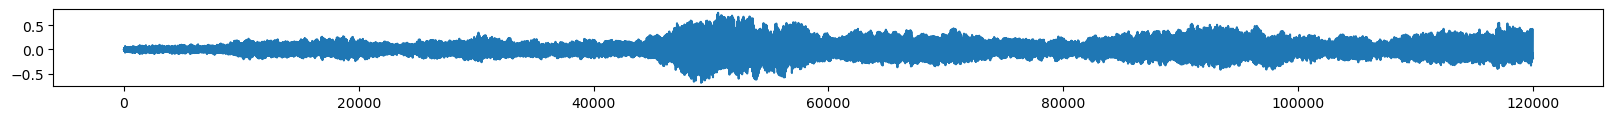

Finished epoch number 45 with a total of 10000 debug_seqs
 time: 2025-10-27 18:57:22.264100, epoch 46,  Loss: 0.2430
  Quantizer 0 Loss: 2.2349
  Quantizer 1 Loss: 3.1432
  Quantizer 2 Loss: 3.8909
  Quantizer 3 Loss: 4.3523
  Quantizer 4 Loss: 4.6553
  Quantizer 5 Loss: 4.8408
  Quantizer 6 Loss: 5.0684
  Quantizer 7 Loss: 5.1684
Latents embedded in 106 of the GRU input size of 128
Conditioning parameters embedded in 22 of the GRU input size of 128
DEVICE going in: model tensors cuda:0, enc_model cpu, c cuda:0
About toInitialize generator with c.shape = torch.Size([8])
params_seq.shape = torch.Size([10, 8])
plot the audio which has shape (120000,)


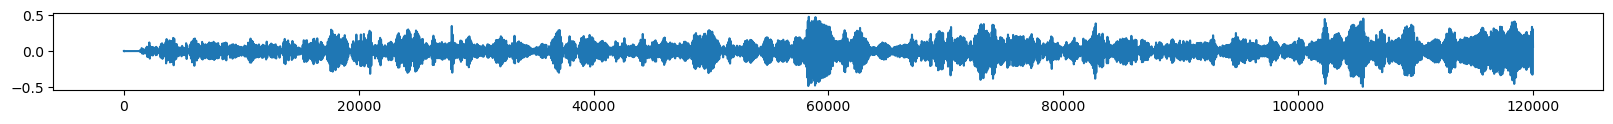

Finished epoch number 46 with a total of 10000 debug_seqs
 time: 2025-10-27 18:58:10.985135, epoch 47,  Loss: 0.2421
  Quantizer 0 Loss: 2.2276
  Quantizer 1 Loss: 3.1403
  Quantizer 2 Loss: 3.8916
  Quantizer 3 Loss: 4.3527
  Quantizer 4 Loss: 4.6585
  Quantizer 5 Loss: 4.8422
  Quantizer 6 Loss: 5.0710
  Quantizer 7 Loss: 5.1704
Latents embedded in 106 of the GRU input size of 128
Conditioning parameters embedded in 22 of the GRU input size of 128
DEVICE going in: model tensors cuda:0, enc_model cpu, c cuda:0
About toInitialize generator with c.shape = torch.Size([8])
params_seq.shape = torch.Size([10, 8])
plot the audio which has shape (120000,)


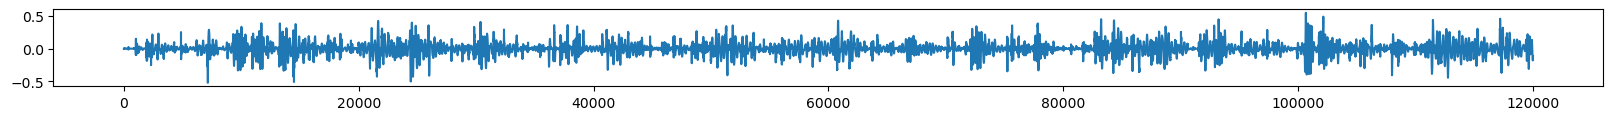

Finished epoch number 47 with a total of 10000 debug_seqs
 time: 2025-10-27 18:59:00.975563, epoch 48,  Loss: 0.2501
  Quantizer 0 Loss: 2.2442
  Quantizer 1 Loss: 3.1552
  Quantizer 2 Loss: 3.9040
  Quantizer 3 Loss: 4.3689
  Quantizer 4 Loss: 4.6727
  Quantizer 5 Loss: 4.8551
  Quantizer 6 Loss: 5.0815
  Quantizer 7 Loss: 5.1820
Latents embedded in 106 of the GRU input size of 128
Conditioning parameters embedded in 22 of the GRU input size of 128
DEVICE going in: model tensors cuda:0, enc_model cpu, c cuda:0
About toInitialize generator with c.shape = torch.Size([8])
params_seq.shape = torch.Size([10, 8])
plot the audio which has shape (120000,)


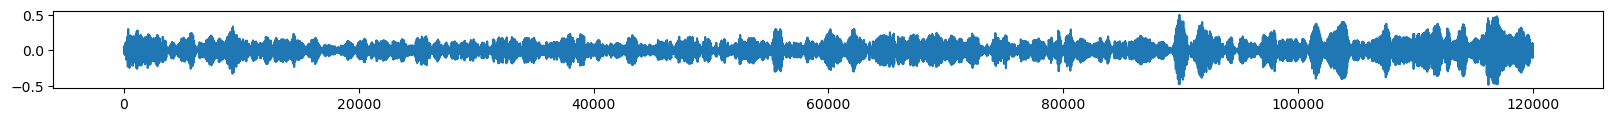

Finished epoch number 48 with a total of 10000 debug_seqs
 time: 2025-10-27 18:59:50.202881, epoch 49,  Loss: 0.2490
  Quantizer 0 Loss: 2.2218
  Quantizer 1 Loss: 3.1369
  Quantizer 2 Loss: 3.8936
  Quantizer 3 Loss: 4.3619
  Quantizer 4 Loss: 4.6605
  Quantizer 5 Loss: 4.8471
  Quantizer 6 Loss: 5.0783
  Quantizer 7 Loss: 5.1812
Latents embedded in 106 of the GRU input size of 128
Conditioning parameters embedded in 22 of the GRU input size of 128
DEVICE going in: model tensors cuda:0, enc_model cpu, c cuda:0
About toInitialize generator with c.shape = torch.Size([8])
params_seq.shape = torch.Size([10, 8])
plot the audio which has shape (120000,)


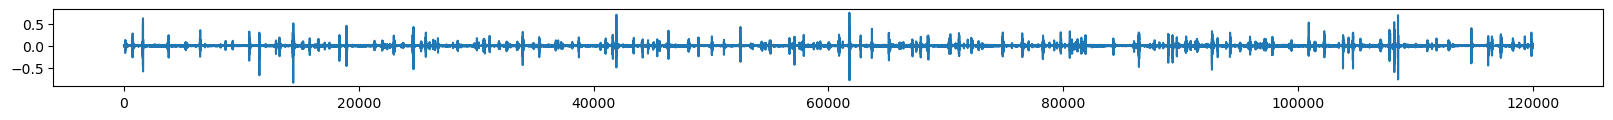

Finished epoch number 49 with a total of 10000 debug_seqs
 time: 2025-10-27 19:00:39.149319, epoch 50,  Loss: 0.2492
  Quantizer 0 Loss: 2.2244
  Quantizer 1 Loss: 3.1399
  Quantizer 2 Loss: 3.8940
  Quantizer 3 Loss: 4.3603
  Quantizer 4 Loss: 4.6664
  Quantizer 5 Loss: 4.8512
  Quantizer 6 Loss: 5.0766
  Quantizer 7 Loss: 5.1761
Latents embedded in 106 of the GRU input size of 128
Conditioning parameters embedded in 22 of the GRU input size of 128
DEVICE going in: model tensors cuda:0, enc_model cpu, c cuda:0
About toInitialize generator with c.shape = torch.Size([8])
params_seq.shape = torch.Size([10, 8])
plot the audio which has shape (120000,)


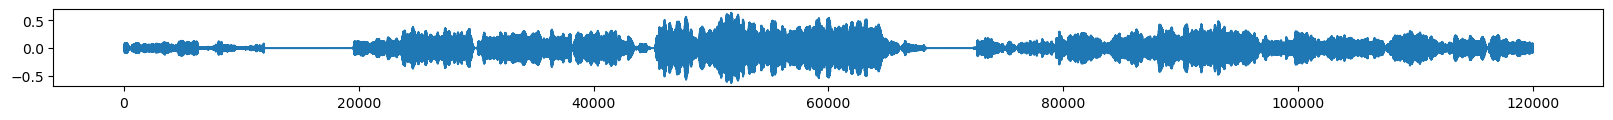

Saved checkpoint at epoch 50
Finished epoch number 50 with a total of 10000 debug_seqs
 time: 2025-10-27 19:01:27.743005, epoch 51,  Loss: 0.2245
  Quantizer 0 Loss: 2.2204
  Quantizer 1 Loss: 2.7973
  Quantizer 2 Loss: 3.4979
  Quantizer 3 Loss: 3.9701
  Quantizer 4 Loss: 4.2912
  Quantizer 5 Loss: 4.4962
  Quantizer 6 Loss: 4.7404
  Quantizer 7 Loss: 4.8634
Latents embedded in 106 of the GRU input size of 128
Conditioning parameters embedded in 22 of the GRU input size of 128
DEVICE going in: model tensors cuda:0, enc_model cpu, c cuda:0
About toInitialize generator with c.shape = torch.Size([8])
params_seq.shape = torch.Size([10, 8])
plot the audio which has shape (120000,)


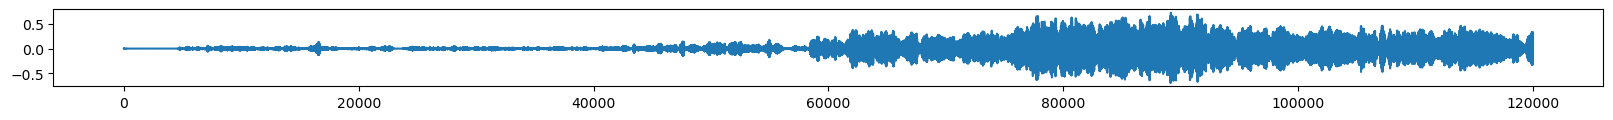

Finished epoch number 51 with a total of 10000 debug_seqs
 time: 2025-10-27 19:02:17.307854, epoch 52,  Loss: 0.2170
  Quantizer 0 Loss: 2.2064
  Quantizer 1 Loss: 2.7488
  Quantizer 2 Loss: 3.4201
  Quantizer 3 Loss: 3.8782
  Quantizer 4 Loss: 4.2014
  Quantizer 5 Loss: 4.4003
  Quantizer 6 Loss: 4.6487
  Quantizer 7 Loss: 4.7727
Latents embedded in 106 of the GRU input size of 128
Conditioning parameters embedded in 22 of the GRU input size of 128
DEVICE going in: model tensors cuda:0, enc_model cpu, c cuda:0
About toInitialize generator with c.shape = torch.Size([8])
params_seq.shape = torch.Size([10, 8])
plot the audio which has shape (120000,)


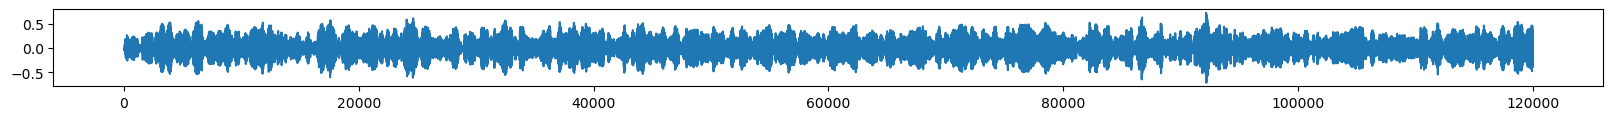

Finished epoch number 52 with a total of 10000 debug_seqs
 time: 2025-10-27 19:03:07.020095, epoch 53,  Loss: 0.2233
  Quantizer 0 Loss: 2.2093
  Quantizer 1 Loss: 2.7356
  Quantizer 2 Loss: 3.4064
  Quantizer 3 Loss: 3.8614
  Quantizer 4 Loss: 4.1800
  Quantizer 5 Loss: 4.3836
  Quantizer 6 Loss: 4.6259
  Quantizer 7 Loss: 4.7482
Latents embedded in 106 of the GRU input size of 128
Conditioning parameters embedded in 22 of the GRU input size of 128
DEVICE going in: model tensors cuda:0, enc_model cpu, c cuda:0
About toInitialize generator with c.shape = torch.Size([8])
params_seq.shape = torch.Size([10, 8])
plot the audio which has shape (120000,)


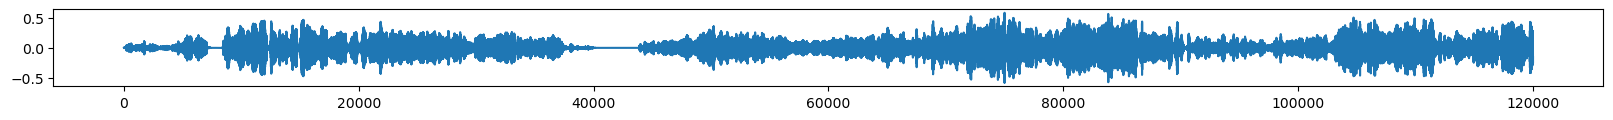

Finished epoch number 53 with a total of 10000 debug_seqs
 time: 2025-10-27 19:03:56.783666, epoch 54,  Loss: 0.2227
  Quantizer 0 Loss: 2.2035
  Quantizer 1 Loss: 2.7297
  Quantizer 2 Loss: 3.3965
  Quantizer 3 Loss: 3.8537
  Quantizer 4 Loss: 4.1733
  Quantizer 5 Loss: 4.3762
  Quantizer 6 Loss: 4.6198
  Quantizer 7 Loss: 4.7449
Latents embedded in 106 of the GRU input size of 128
Conditioning parameters embedded in 22 of the GRU input size of 128
DEVICE going in: model tensors cuda:0, enc_model cpu, c cuda:0
About toInitialize generator with c.shape = torch.Size([8])
params_seq.shape = torch.Size([10, 8])
plot the audio which has shape (120000,)


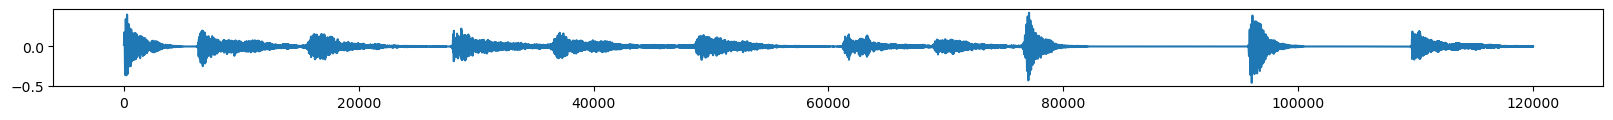

Finished epoch number 54 with a total of 10000 debug_seqs
 time: 2025-10-27 19:04:46.743746, epoch 55,  Loss: 0.2170
  Quantizer 0 Loss: 2.2154
  Quantizer 1 Loss: 2.7340
  Quantizer 2 Loss: 3.4005
  Quantizer 3 Loss: 3.8561
  Quantizer 4 Loss: 4.1758
  Quantizer 5 Loss: 4.3724
  Quantizer 6 Loss: 4.6160
  Quantizer 7 Loss: 4.7462
Latents embedded in 106 of the GRU input size of 128
Conditioning parameters embedded in 22 of the GRU input size of 128
DEVICE going in: model tensors cuda:0, enc_model cpu, c cuda:0
About toInitialize generator with c.shape = torch.Size([8])
params_seq.shape = torch.Size([10, 8])
plot the audio which has shape (120000,)


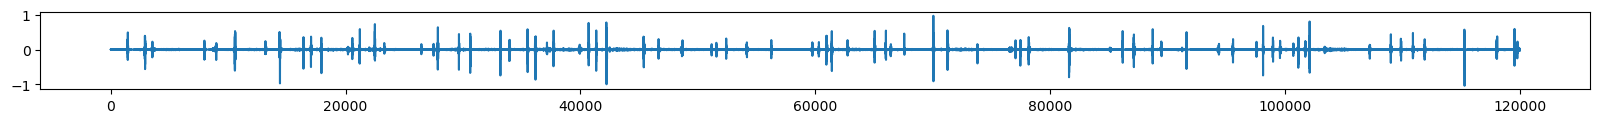

Finished epoch number 55 with a total of 10000 debug_seqs
 time: 2025-10-27 19:05:36.533608, epoch 56,  Loss: 0.2295
  Quantizer 0 Loss: 2.2082
  Quantizer 1 Loss: 2.7244
  Quantizer 2 Loss: 3.3886
  Quantizer 3 Loss: 3.8403
  Quantizer 4 Loss: 4.1488
  Quantizer 5 Loss: 4.3533
  Quantizer 6 Loss: 4.5927
  Quantizer 7 Loss: 4.7195
Latents embedded in 106 of the GRU input size of 128
Conditioning parameters embedded in 22 of the GRU input size of 128
DEVICE going in: model tensors cuda:0, enc_model cpu, c cuda:0
About toInitialize generator with c.shape = torch.Size([8])
params_seq.shape = torch.Size([10, 8])
plot the audio which has shape (120000,)


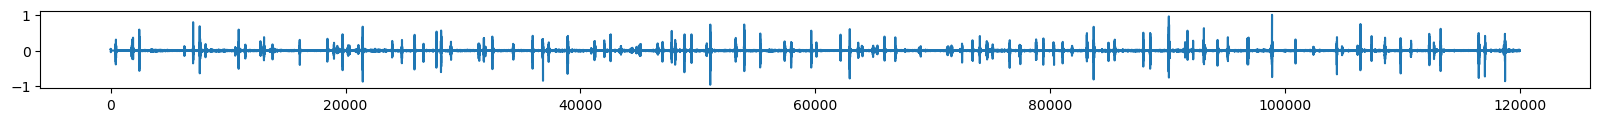

Finished epoch number 56 with a total of 10000 debug_seqs
 time: 2025-10-27 19:06:25.125827, epoch 57,  Loss: 0.2217
  Quantizer 0 Loss: 2.2025
  Quantizer 1 Loss: 2.7178
  Quantizer 2 Loss: 3.3773
  Quantizer 3 Loss: 3.8346
  Quantizer 4 Loss: 4.1457
  Quantizer 5 Loss: 4.3471
  Quantizer 6 Loss: 4.5869
  Quantizer 7 Loss: 4.7177
Latents embedded in 106 of the GRU input size of 128
Conditioning parameters embedded in 22 of the GRU input size of 128
DEVICE going in: model tensors cuda:0, enc_model cpu, c cuda:0
About toInitialize generator with c.shape = torch.Size([8])
params_seq.shape = torch.Size([10, 8])
plot the audio which has shape (120000,)


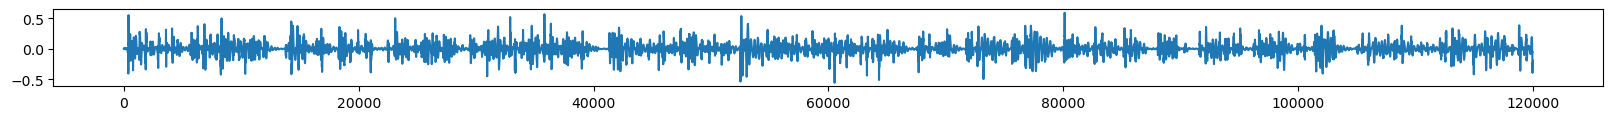

Finished epoch number 57 with a total of 10000 debug_seqs
 time: 2025-10-27 19:07:14.698220, epoch 58,  Loss: 0.2300
  Quantizer 0 Loss: 2.2126
  Quantizer 1 Loss: 2.7287
  Quantizer 2 Loss: 3.3846
  Quantizer 3 Loss: 3.8387
  Quantizer 4 Loss: 4.1567
  Quantizer 5 Loss: 4.3620
  Quantizer 6 Loss: 4.6046
  Quantizer 7 Loss: 4.7344
Latents embedded in 106 of the GRU input size of 128
Conditioning parameters embedded in 22 of the GRU input size of 128
DEVICE going in: model tensors cuda:0, enc_model cpu, c cuda:0
About toInitialize generator with c.shape = torch.Size([8])
params_seq.shape = torch.Size([10, 8])
plot the audio which has shape (120000,)


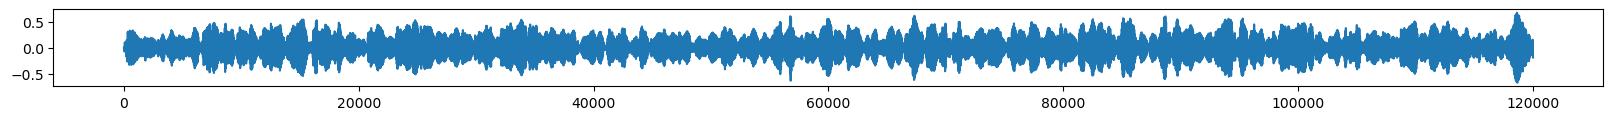

Finished epoch number 58 with a total of 10000 debug_seqs
 time: 2025-10-27 19:08:03.792991, epoch 59,  Loss: 0.2199
  Quantizer 0 Loss: 2.2094
  Quantizer 1 Loss: 2.7229
  Quantizer 2 Loss: 3.3786
  Quantizer 3 Loss: 3.8304
  Quantizer 4 Loss: 4.1462
  Quantizer 5 Loss: 4.3526
  Quantizer 6 Loss: 4.5900
  Quantizer 7 Loss: 4.7211
Latents embedded in 106 of the GRU input size of 128
Conditioning parameters embedded in 22 of the GRU input size of 128
DEVICE going in: model tensors cuda:0, enc_model cpu, c cuda:0
About toInitialize generator with c.shape = torch.Size([8])
params_seq.shape = torch.Size([10, 8])
plot the audio which has shape (120000,)


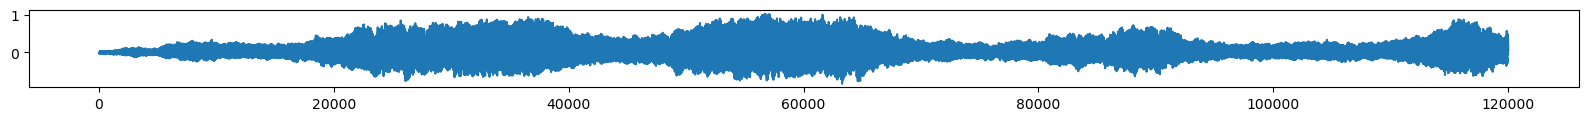

Finished epoch number 59 with a total of 10000 debug_seqs
 time: 2025-10-27 19:08:53.465443, epoch 60,  Loss: 0.2227
  Quantizer 0 Loss: 2.2068
  Quantizer 1 Loss: 2.7164
  Quantizer 2 Loss: 3.3783
  Quantizer 3 Loss: 3.8301
  Quantizer 4 Loss: 4.1413
  Quantizer 5 Loss: 4.3468
  Quantizer 6 Loss: 4.5887
  Quantizer 7 Loss: 4.7145
Latents embedded in 106 of the GRU input size of 128
Conditioning parameters embedded in 22 of the GRU input size of 128
DEVICE going in: model tensors cuda:0, enc_model cpu, c cuda:0
About toInitialize generator with c.shape = torch.Size([8])
params_seq.shape = torch.Size([10, 8])
plot the audio which has shape (120000,)


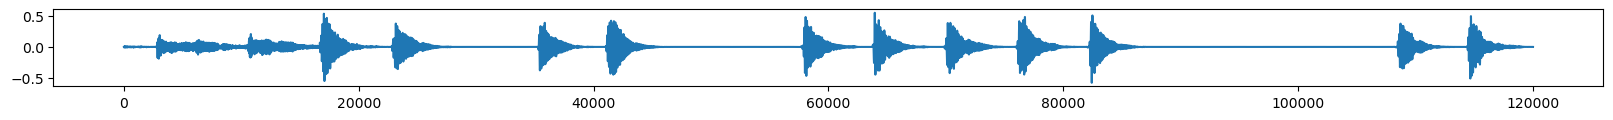

Finished epoch number 60 with a total of 10000 debug_seqs
 time: 2025-10-27 19:09:43.507295, epoch 61,  Loss: 0.2181
  Quantizer 0 Loss: 2.2052
  Quantizer 1 Loss: 2.7171
  Quantizer 2 Loss: 3.3729
  Quantizer 3 Loss: 3.8213
  Quantizer 4 Loss: 4.1342
  Quantizer 5 Loss: 4.3355
  Quantizer 6 Loss: 4.5817
  Quantizer 7 Loss: 4.7118
Latents embedded in 106 of the GRU input size of 128
Conditioning parameters embedded in 22 of the GRU input size of 128
DEVICE going in: model tensors cuda:0, enc_model cpu, c cuda:0
About toInitialize generator with c.shape = torch.Size([8])
params_seq.shape = torch.Size([10, 8])
plot the audio which has shape (120000,)


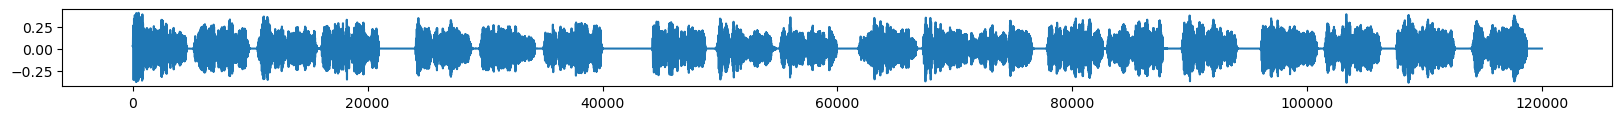

Finished epoch number 61 with a total of 10000 debug_seqs
 time: 2025-10-27 19:10:32.369389, epoch 62,  Loss: 0.2242
  Quantizer 0 Loss: 2.1990
  Quantizer 1 Loss: 2.7121
  Quantizer 2 Loss: 3.3667
  Quantizer 3 Loss: 3.8210
  Quantizer 4 Loss: 4.1364
  Quantizer 5 Loss: 4.3363
  Quantizer 6 Loss: 4.5747
  Quantizer 7 Loss: 4.7095
Latents embedded in 106 of the GRU input size of 128
Conditioning parameters embedded in 22 of the GRU input size of 128
DEVICE going in: model tensors cuda:0, enc_model cpu, c cuda:0
About toInitialize generator with c.shape = torch.Size([8])
params_seq.shape = torch.Size([10, 8])
plot the audio which has shape (120000,)


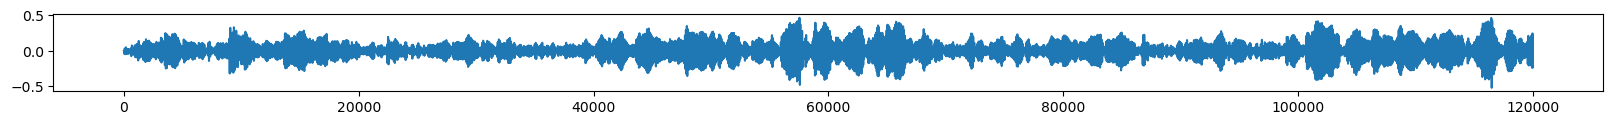

Finished epoch number 62 with a total of 10000 debug_seqs
 time: 2025-10-27 19:11:22.037294, epoch 63,  Loss: 0.2211
  Quantizer 0 Loss: 2.2108
  Quantizer 1 Loss: 2.7265
  Quantizer 2 Loss: 3.3845
  Quantizer 3 Loss: 3.8309
  Quantizer 4 Loss: 4.1507
  Quantizer 5 Loss: 4.3516
  Quantizer 6 Loss: 4.5939
  Quantizer 7 Loss: 4.7219
Latents embedded in 106 of the GRU input size of 128
Conditioning parameters embedded in 22 of the GRU input size of 128
DEVICE going in: model tensors cuda:0, enc_model cpu, c cuda:0
About toInitialize generator with c.shape = torch.Size([8])
params_seq.shape = torch.Size([10, 8])
plot the audio which has shape (120000,)


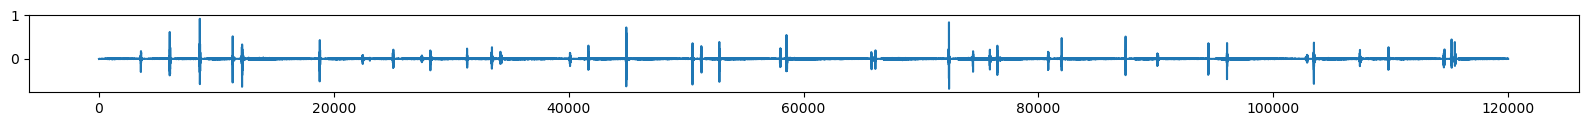

Finished epoch number 63 with a total of 10000 debug_seqs
 time: 2025-10-27 19:12:10.663132, epoch 64,  Loss: 0.2163
  Quantizer 0 Loss: 2.1904
  Quantizer 1 Loss: 2.7021
  Quantizer 2 Loss: 3.3582
  Quantizer 3 Loss: 3.8091
  Quantizer 4 Loss: 4.1281
  Quantizer 5 Loss: 4.3258
  Quantizer 6 Loss: 4.5726
  Quantizer 7 Loss: 4.7035
Latents embedded in 106 of the GRU input size of 128
Conditioning parameters embedded in 22 of the GRU input size of 128
DEVICE going in: model tensors cuda:0, enc_model cpu, c cuda:0
About toInitialize generator with c.shape = torch.Size([8])
params_seq.shape = torch.Size([10, 8])
plot the audio which has shape (120000,)


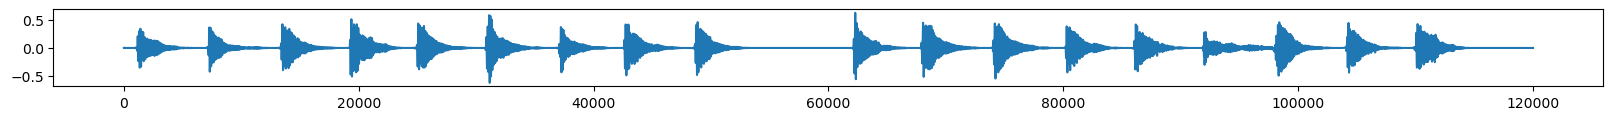

Finished epoch number 64 with a total of 10000 debug_seqs
 time: 2025-10-27 19:12:59.293654, epoch 65,  Loss: 0.2160
  Quantizer 0 Loss: 2.2002
  Quantizer 1 Loss: 2.7109
  Quantizer 2 Loss: 3.3633
  Quantizer 3 Loss: 3.8138
  Quantizer 4 Loss: 4.1300
  Quantizer 5 Loss: 4.3277
  Quantizer 6 Loss: 4.5691
  Quantizer 7 Loss: 4.7012
Latents embedded in 106 of the GRU input size of 128
Conditioning parameters embedded in 22 of the GRU input size of 128
DEVICE going in: model tensors cuda:0, enc_model cpu, c cuda:0
About toInitialize generator with c.shape = torch.Size([8])
params_seq.shape = torch.Size([10, 8])
plot the audio which has shape (120000,)


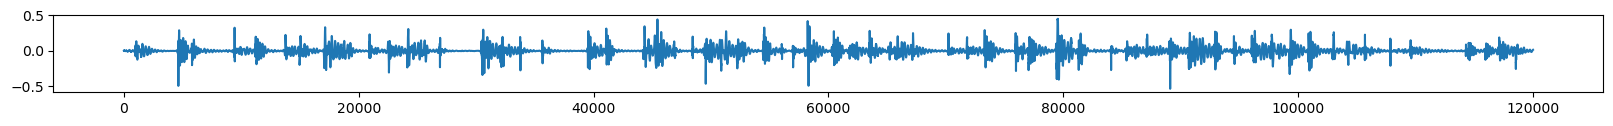

Finished epoch number 65 with a total of 10000 debug_seqs
 time: 2025-10-27 19:13:48.308601, epoch 66,  Loss: 0.2229
  Quantizer 0 Loss: 2.2048
  Quantizer 1 Loss: 2.7159
  Quantizer 2 Loss: 3.3605
  Quantizer 3 Loss: 3.8140
  Quantizer 4 Loss: 4.1282
  Quantizer 5 Loss: 4.3317
  Quantizer 6 Loss: 4.5724
  Quantizer 7 Loss: 4.6965
Latents embedded in 106 of the GRU input size of 128
Conditioning parameters embedded in 22 of the GRU input size of 128
DEVICE going in: model tensors cuda:0, enc_model cpu, c cuda:0
About toInitialize generator with c.shape = torch.Size([8])
params_seq.shape = torch.Size([10, 8])
plot the audio which has shape (120000,)


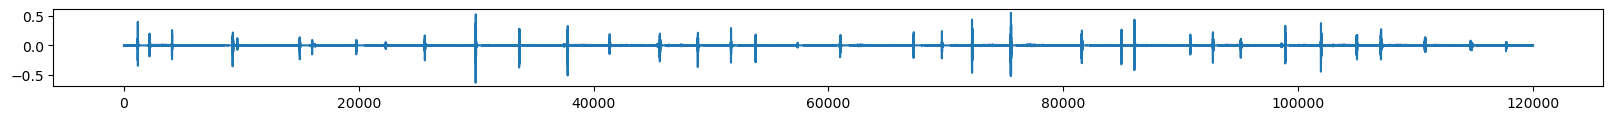

Finished epoch number 66 with a total of 10000 debug_seqs
 time: 2025-10-27 19:14:37.145737, epoch 67,  Loss: 0.2240
  Quantizer 0 Loss: 2.1998
  Quantizer 1 Loss: 2.7104
  Quantizer 2 Loss: 3.3663
  Quantizer 3 Loss: 3.8169
  Quantizer 4 Loss: 4.1311
  Quantizer 5 Loss: 4.3368
  Quantizer 6 Loss: 4.5774
  Quantizer 7 Loss: 4.7088
Latents embedded in 106 of the GRU input size of 128
Conditioning parameters embedded in 22 of the GRU input size of 128
DEVICE going in: model tensors cuda:0, enc_model cpu, c cuda:0
About toInitialize generator with c.shape = torch.Size([8])
params_seq.shape = torch.Size([10, 8])
plot the audio which has shape (120000,)


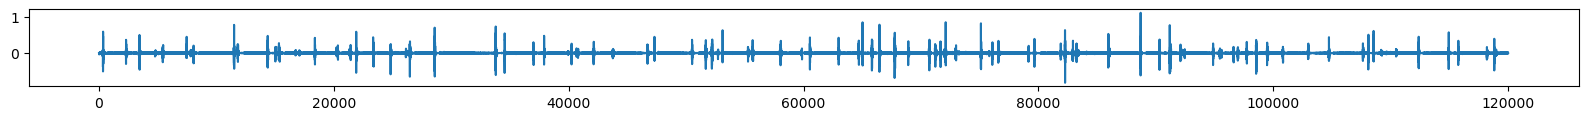

Finished epoch number 67 with a total of 10000 debug_seqs
 time: 2025-10-27 19:15:26.156524, epoch 68,  Loss: 0.2219
  Quantizer 0 Loss: 2.2225
  Quantizer 1 Loss: 2.7325
  Quantizer 2 Loss: 3.3838
  Quantizer 3 Loss: 3.8336
  Quantizer 4 Loss: 4.1502
  Quantizer 5 Loss: 4.3499
  Quantizer 6 Loss: 4.5905
  Quantizer 7 Loss: 4.7196
Latents embedded in 106 of the GRU input size of 128
Conditioning parameters embedded in 22 of the GRU input size of 128
DEVICE going in: model tensors cuda:0, enc_model cpu, c cuda:0
About toInitialize generator with c.shape = torch.Size([8])
params_seq.shape = torch.Size([10, 8])
plot the audio which has shape (120000,)


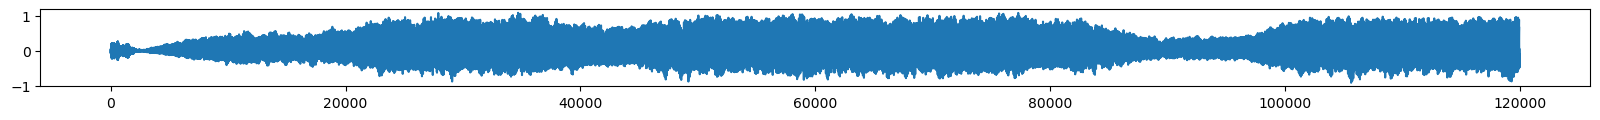

Finished epoch number 68 with a total of 10000 debug_seqs
 time: 2025-10-27 19:16:14.535663, epoch 69,  Loss: 0.2172
  Quantizer 0 Loss: 2.2021
  Quantizer 1 Loss: 2.7145
  Quantizer 2 Loss: 3.3570
  Quantizer 3 Loss: 3.8131
  Quantizer 4 Loss: 4.1252
  Quantizer 5 Loss: 4.3254
  Quantizer 6 Loss: 4.5753
  Quantizer 7 Loss: 4.7048
Latents embedded in 106 of the GRU input size of 128
Conditioning parameters embedded in 22 of the GRU input size of 128
DEVICE going in: model tensors cuda:0, enc_model cpu, c cuda:0
About toInitialize generator with c.shape = torch.Size([8])
params_seq.shape = torch.Size([10, 8])
plot the audio which has shape (120000,)


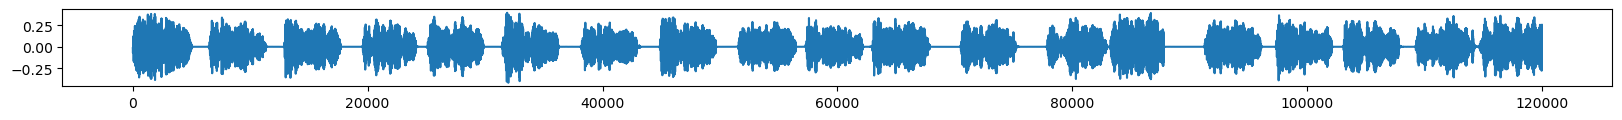

Finished epoch number 69 with a total of 10000 debug_seqs
 time: 2025-10-27 19:17:03.576041, epoch 70,  Loss: 0.2222
  Quantizer 0 Loss: 2.2061
  Quantizer 1 Loss: 2.7108
  Quantizer 2 Loss: 3.3630
  Quantizer 3 Loss: 3.8148
  Quantizer 4 Loss: 4.1294
  Quantizer 5 Loss: 4.3349
  Quantizer 6 Loss: 4.5735
  Quantizer 7 Loss: 4.7023
Latents embedded in 106 of the GRU input size of 128
Conditioning parameters embedded in 22 of the GRU input size of 128
DEVICE going in: model tensors cuda:0, enc_model cpu, c cuda:0
About toInitialize generator with c.shape = torch.Size([8])
params_seq.shape = torch.Size([10, 8])
plot the audio which has shape (120000,)


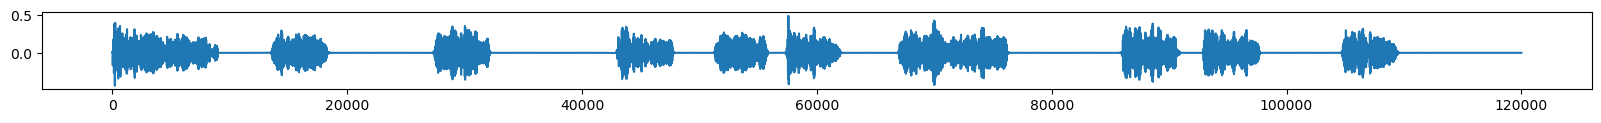

Finished epoch number 70 with a total of 10000 debug_seqs
 time: 2025-10-27 19:17:52.512174, epoch 71,  Loss: 0.2187
  Quantizer 0 Loss: 2.1892
  Quantizer 1 Loss: 2.6935
  Quantizer 2 Loss: 3.3452
  Quantizer 3 Loss: 3.8005
  Quantizer 4 Loss: 4.1097
  Quantizer 5 Loss: 4.3109
  Quantizer 6 Loss: 4.5621
  Quantizer 7 Loss: 4.6868
Latents embedded in 106 of the GRU input size of 128
Conditioning parameters embedded in 22 of the GRU input size of 128
DEVICE going in: model tensors cuda:0, enc_model cpu, c cuda:0
About toInitialize generator with c.shape = torch.Size([8])
params_seq.shape = torch.Size([10, 8])
plot the audio which has shape (120000,)


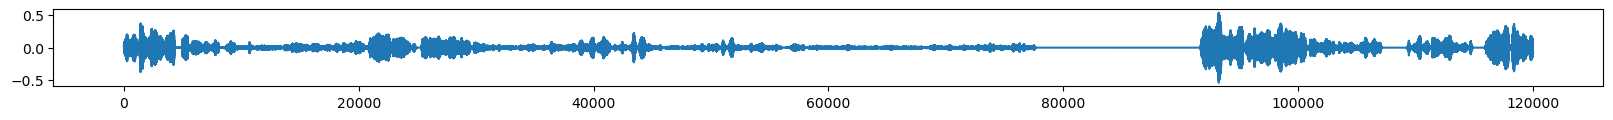

Finished epoch number 71 with a total of 10000 debug_seqs
 time: 2025-10-27 19:18:41.410452, epoch 72,  Loss: 0.2182
  Quantizer 0 Loss: 2.1937
  Quantizer 1 Loss: 2.6977
  Quantizer 2 Loss: 3.3475
  Quantizer 3 Loss: 3.7973
  Quantizer 4 Loss: 4.1127
  Quantizer 5 Loss: 4.3174
  Quantizer 6 Loss: 4.5621
  Quantizer 7 Loss: 4.6897
Latents embedded in 106 of the GRU input size of 128
Conditioning parameters embedded in 22 of the GRU input size of 128
DEVICE going in: model tensors cuda:0, enc_model cpu, c cuda:0
About toInitialize generator with c.shape = torch.Size([8])
params_seq.shape = torch.Size([10, 8])
plot the audio which has shape (120000,)


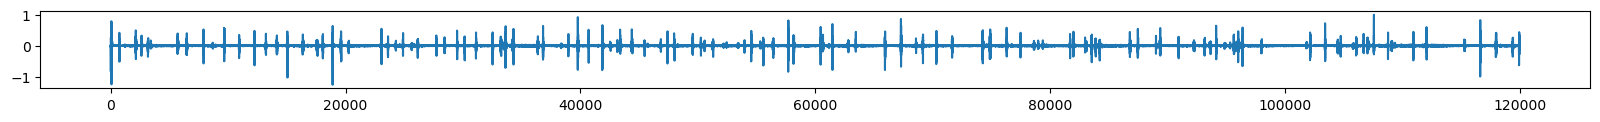

Finished epoch number 72 with a total of 10000 debug_seqs
 time: 2025-10-27 19:19:31.151609, epoch 73,  Loss: 0.2147
  Quantizer 0 Loss: 2.1970
  Quantizer 1 Loss: 2.6945
  Quantizer 2 Loss: 3.3519
  Quantizer 3 Loss: 3.7977
  Quantizer 4 Loss: 4.1178
  Quantizer 5 Loss: 4.3172
  Quantizer 6 Loss: 4.5613
  Quantizer 7 Loss: 4.6881
Latents embedded in 106 of the GRU input size of 128
Conditioning parameters embedded in 22 of the GRU input size of 128
DEVICE going in: model tensors cuda:0, enc_model cpu, c cuda:0
About toInitialize generator with c.shape = torch.Size([8])
params_seq.shape = torch.Size([10, 8])
plot the audio which has shape (120000,)


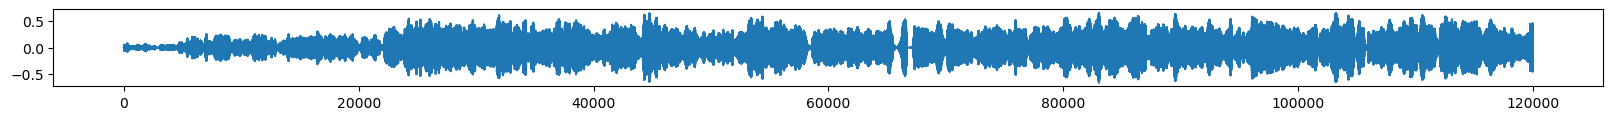

Finished epoch number 73 with a total of 10000 debug_seqs
 time: 2025-10-27 19:20:20.382890, epoch 74,  Loss: 0.2138
  Quantizer 0 Loss: 2.1865
  Quantizer 1 Loss: 2.6881
  Quantizer 2 Loss: 3.3402
  Quantizer 3 Loss: 3.7913
  Quantizer 4 Loss: 4.1071
  Quantizer 5 Loss: 4.3127
  Quantizer 6 Loss: 4.5553
  Quantizer 7 Loss: 4.6827
Latents embedded in 106 of the GRU input size of 128
Conditioning parameters embedded in 22 of the GRU input size of 128
DEVICE going in: model tensors cuda:0, enc_model cpu, c cuda:0
About toInitialize generator with c.shape = torch.Size([8])
params_seq.shape = torch.Size([10, 8])
plot the audio which has shape (120000,)


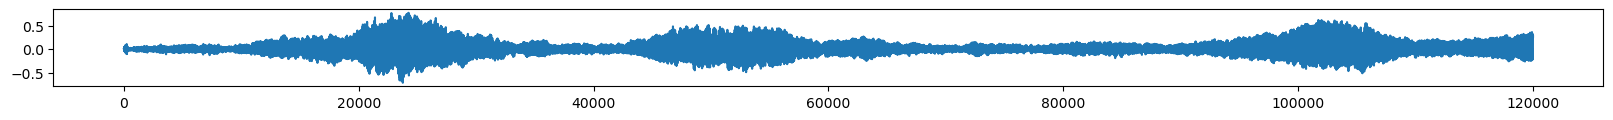

Finished epoch number 74 with a total of 10000 debug_seqs
 time: 2025-10-27 19:21:09.333727, epoch 75,  Loss: 0.2110
  Quantizer 0 Loss: 2.1954
  Quantizer 1 Loss: 2.6964
  Quantizer 2 Loss: 3.3445
  Quantizer 3 Loss: 3.7926
  Quantizer 4 Loss: 4.1118
  Quantizer 5 Loss: 4.3110
  Quantizer 6 Loss: 4.5636
  Quantizer 7 Loss: 4.6898
Latents embedded in 106 of the GRU input size of 128
Conditioning parameters embedded in 22 of the GRU input size of 128
DEVICE going in: model tensors cuda:0, enc_model cpu, c cuda:0
About toInitialize generator with c.shape = torch.Size([8])
params_seq.shape = torch.Size([10, 8])
plot the audio which has shape (120000,)


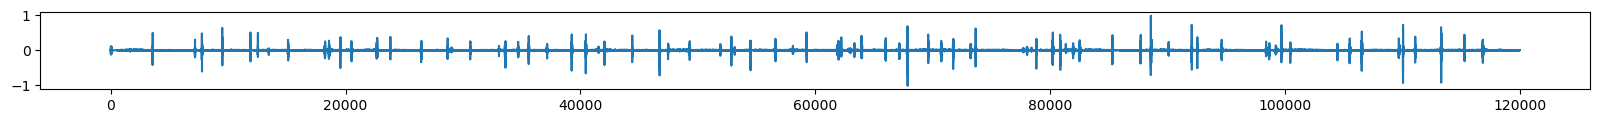

Saved checkpoint at epoch 75
Finished epoch number 75 with a total of 10000 debug_seqs
 time: 2025-10-27 19:21:59.624634, epoch 76,  Loss: 0.2539
  Quantizer 0 Loss: 2.2712
  Quantizer 1 Loss: 3.3613
  Quantizer 2 Loss: 4.0338
  Quantizer 3 Loss: 4.4687
  Quantizer 4 Loss: 4.7434
  Quantizer 5 Loss: 4.9184
  Quantizer 6 Loss: 5.1452
  Quantizer 7 Loss: 5.2377
Latents embedded in 106 of the GRU input size of 128
Conditioning parameters embedded in 22 of the GRU input size of 128
DEVICE going in: model tensors cuda:0, enc_model cpu, c cuda:0
About toInitialize generator with c.shape = torch.Size([8])
params_seq.shape = torch.Size([10, 8])
plot the audio which has shape (120000,)


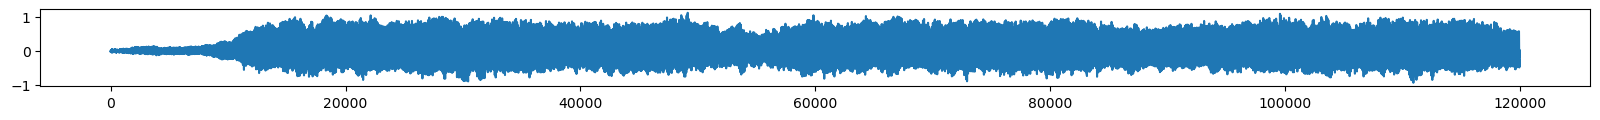

Finished epoch number 76 with a total of 10000 debug_seqs
 time: 2025-10-27 19:22:48.149749, epoch 77,  Loss: 0.2348
  Quantizer 0 Loss: 2.2242
  Quantizer 1 Loss: 3.1950
  Quantizer 2 Loss: 3.9435
  Quantizer 3 Loss: 4.3949
  Quantizer 4 Loss: 4.6932
  Quantizer 5 Loss: 4.8791
  Quantizer 6 Loss: 5.1094
  Quantizer 7 Loss: 5.2082
Latents embedded in 106 of the GRU input size of 128
Conditioning parameters embedded in 22 of the GRU input size of 128
DEVICE going in: model tensors cuda:0, enc_model cpu, c cuda:0
About toInitialize generator with c.shape = torch.Size([8])
params_seq.shape = torch.Size([10, 8])
plot the audio which has shape (120000,)


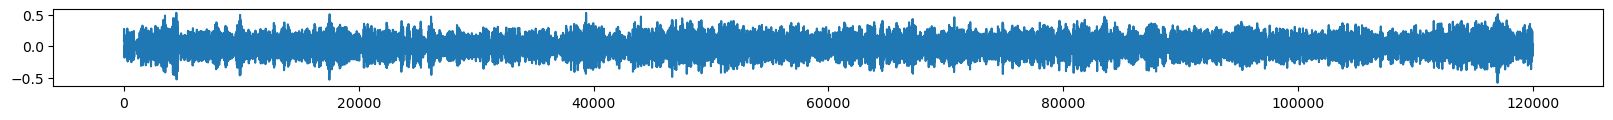

Finished epoch number 77 with a total of 10000 debug_seqs
 time: 2025-10-27 19:23:37.915158, epoch 78,  Loss: 0.2469
  Quantizer 0 Loss: 2.2217
  Quantizer 1 Loss: 3.1710
  Quantizer 2 Loss: 3.9132
  Quantizer 3 Loss: 4.3805
  Quantizer 4 Loss: 4.6864
  Quantizer 5 Loss: 4.8691
  Quantizer 6 Loss: 5.0996
  Quantizer 7 Loss: 5.2033
Latents embedded in 106 of the GRU input size of 128
Conditioning parameters embedded in 22 of the GRU input size of 128
DEVICE going in: model tensors cuda:0, enc_model cpu, c cuda:0
About toInitialize generator with c.shape = torch.Size([8])
params_seq.shape = torch.Size([10, 8])
plot the audio which has shape (120000,)


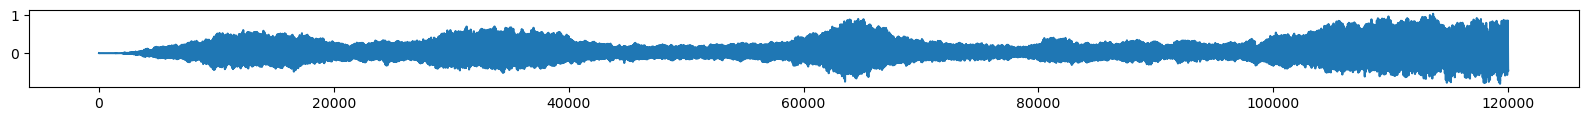

Finished epoch number 78 with a total of 10000 debug_seqs
 time: 2025-10-27 19:24:27.850146, epoch 79,  Loss: 0.2541
  Quantizer 0 Loss: 2.2173
  Quantizer 1 Loss: 3.1548
  Quantizer 2 Loss: 3.9064
  Quantizer 3 Loss: 4.3664
  Quantizer 4 Loss: 4.6717
  Quantizer 5 Loss: 4.8538
  Quantizer 6 Loss: 5.0842
  Quantizer 7 Loss: 5.1833
Latents embedded in 106 of the GRU input size of 128
Conditioning parameters embedded in 22 of the GRU input size of 128
DEVICE going in: model tensors cuda:0, enc_model cpu, c cuda:0
About toInitialize generator with c.shape = torch.Size([8])
params_seq.shape = torch.Size([10, 8])
plot the audio which has shape (120000,)


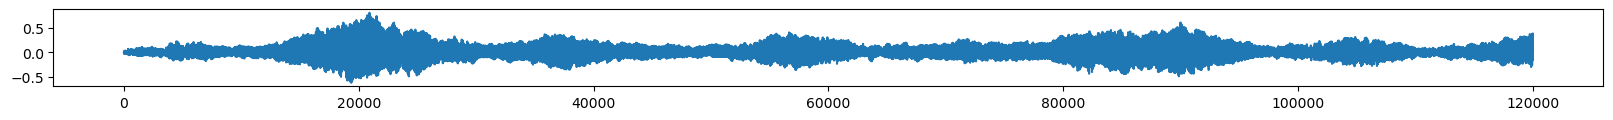

Finished epoch number 79 with a total of 10000 debug_seqs
 time: 2025-10-27 19:25:17.205199, epoch 80,  Loss: 0.2452
  Quantizer 0 Loss: 2.1972
  Quantizer 1 Loss: 3.1273
  Quantizer 2 Loss: 3.8763
  Quantizer 3 Loss: 4.3421
  Quantizer 4 Loss: 4.6523
  Quantizer 5 Loss: 4.8403
  Quantizer 6 Loss: 5.0713
  Quantizer 7 Loss: 5.1717
Latents embedded in 106 of the GRU input size of 128
Conditioning parameters embedded in 22 of the GRU input size of 128
DEVICE going in: model tensors cuda:0, enc_model cpu, c cuda:0
About toInitialize generator with c.shape = torch.Size([8])
params_seq.shape = torch.Size([10, 8])
plot the audio which has shape (120000,)


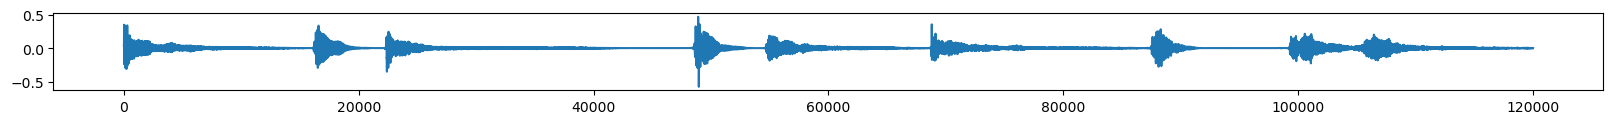

Finished epoch number 80 with a total of 10000 debug_seqs
 time: 2025-10-27 19:26:06.892539, epoch 81,  Loss: 0.2435
  Quantizer 0 Loss: 2.2014
  Quantizer 1 Loss: 3.1307
  Quantizer 2 Loss: 3.8845
  Quantizer 3 Loss: 4.3561
  Quantizer 4 Loss: 4.6562
  Quantizer 5 Loss: 4.8441
  Quantizer 6 Loss: 5.0759
  Quantizer 7 Loss: 5.1737
Latents embedded in 106 of the GRU input size of 128
Conditioning parameters embedded in 22 of the GRU input size of 128
DEVICE going in: model tensors cuda:0, enc_model cpu, c cuda:0
About toInitialize generator with c.shape = torch.Size([8])
params_seq.shape = torch.Size([10, 8])
plot the audio which has shape (120000,)


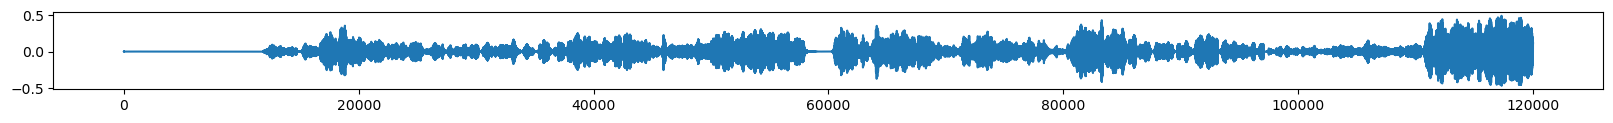

Finished epoch number 81 with a total of 10000 debug_seqs
 time: 2025-10-27 19:26:56.518690, epoch 82,  Loss: 0.2406
  Quantizer 0 Loss: 2.2198
  Quantizer 1 Loss: 3.1481
  Quantizer 2 Loss: 3.8986
  Quantizer 3 Loss: 4.3623
  Quantizer 4 Loss: 4.6704
  Quantizer 5 Loss: 4.8624
  Quantizer 6 Loss: 5.0920
  Quantizer 7 Loss: 5.1927
Latents embedded in 106 of the GRU input size of 128
Conditioning parameters embedded in 22 of the GRU input size of 128
DEVICE going in: model tensors cuda:0, enc_model cpu, c cuda:0
About toInitialize generator with c.shape = torch.Size([8])
params_seq.shape = torch.Size([10, 8])
plot the audio which has shape (120000,)


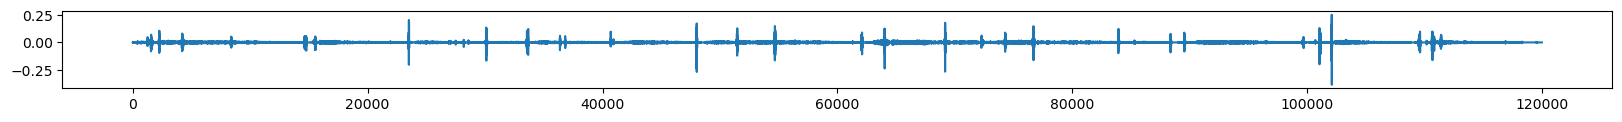

Finished epoch number 82 with a total of 10000 debug_seqs
 time: 2025-10-27 19:27:45.589760, epoch 83,  Loss: 0.2457
  Quantizer 0 Loss: 2.2066
  Quantizer 1 Loss: 3.1184
  Quantizer 2 Loss: 3.8752
  Quantizer 3 Loss: 4.3459
  Quantizer 4 Loss: 4.6502
  Quantizer 5 Loss: 4.8384
  Quantizer 6 Loss: 5.0699
  Quantizer 7 Loss: 5.1690
Latents embedded in 106 of the GRU input size of 128
Conditioning parameters embedded in 22 of the GRU input size of 128
DEVICE going in: model tensors cuda:0, enc_model cpu, c cuda:0
About toInitialize generator with c.shape = torch.Size([8])
params_seq.shape = torch.Size([10, 8])
plot the audio which has shape (120000,)


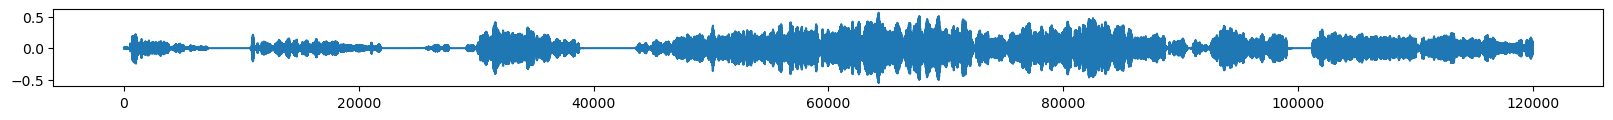

Finished epoch number 83 with a total of 10000 debug_seqs
 time: 2025-10-27 19:28:35.834743, epoch 84,  Loss: 0.2443
  Quantizer 0 Loss: 2.2021
  Quantizer 1 Loss: 3.1198
  Quantizer 2 Loss: 3.8651
  Quantizer 3 Loss: 4.3298
  Quantizer 4 Loss: 4.6380
  Quantizer 5 Loss: 4.8310
  Quantizer 6 Loss: 5.0563
  Quantizer 7 Loss: 5.1630
Latents embedded in 106 of the GRU input size of 128
Conditioning parameters embedded in 22 of the GRU input size of 128
DEVICE going in: model tensors cuda:0, enc_model cpu, c cuda:0
About toInitialize generator with c.shape = torch.Size([8])
params_seq.shape = torch.Size([10, 8])
plot the audio which has shape (120000,)


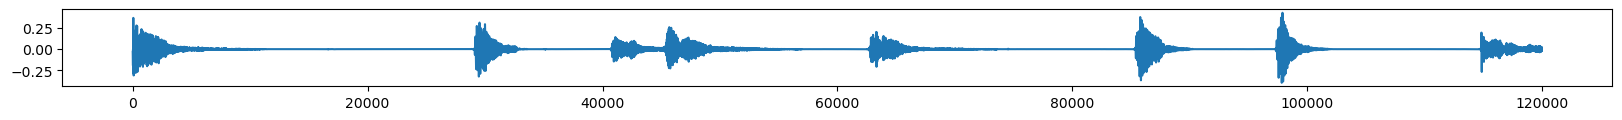

Finished epoch number 84 with a total of 10000 debug_seqs
 time: 2025-10-27 19:29:24.527278, epoch 85,  Loss: 0.2400
  Quantizer 0 Loss: 2.1954
  Quantizer 1 Loss: 3.1173
  Quantizer 2 Loss: 3.8675
  Quantizer 3 Loss: 4.3358
  Quantizer 4 Loss: 4.6466
  Quantizer 5 Loss: 4.8304
  Quantizer 6 Loss: 5.0655
  Quantizer 7 Loss: 5.1688
Latents embedded in 106 of the GRU input size of 128
Conditioning parameters embedded in 22 of the GRU input size of 128
DEVICE going in: model tensors cuda:0, enc_model cpu, c cuda:0
About toInitialize generator with c.shape = torch.Size([8])
params_seq.shape = torch.Size([10, 8])
plot the audio which has shape (120000,)


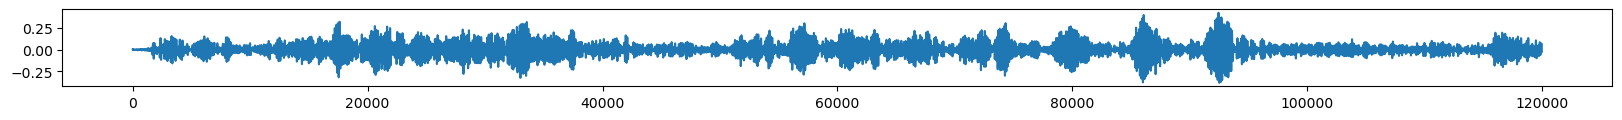

Finished epoch number 85 with a total of 10000 debug_seqs
 time: 2025-10-27 19:30:15.012915, epoch 86,  Loss: 0.2392
  Quantizer 0 Loss: 2.2035
  Quantizer 1 Loss: 3.1228
  Quantizer 2 Loss: 3.8796
  Quantizer 3 Loss: 4.3501
  Quantizer 4 Loss: 4.6588
  Quantizer 5 Loss: 4.8462
  Quantizer 6 Loss: 5.0746
  Quantizer 7 Loss: 5.1750
Latents embedded in 106 of the GRU input size of 128
Conditioning parameters embedded in 22 of the GRU input size of 128
DEVICE going in: model tensors cuda:0, enc_model cpu, c cuda:0
About toInitialize generator with c.shape = torch.Size([8])
params_seq.shape = torch.Size([10, 8])
plot the audio which has shape (120000,)


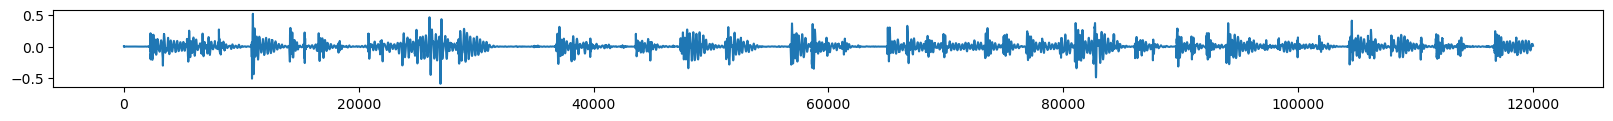

Finished epoch number 86 with a total of 10000 debug_seqs
 time: 2025-10-27 19:31:04.761820, epoch 87,  Loss: 0.2475
  Quantizer 0 Loss: 2.1958
  Quantizer 1 Loss: 3.1136
  Quantizer 2 Loss: 3.8592
  Quantizer 3 Loss: 4.3322
  Quantizer 4 Loss: 4.6408
  Quantizer 5 Loss: 4.8278
  Quantizer 6 Loss: 5.0632
  Quantizer 7 Loss: 5.1619
Latents embedded in 106 of the GRU input size of 128
Conditioning parameters embedded in 22 of the GRU input size of 128
DEVICE going in: model tensors cuda:0, enc_model cpu, c cuda:0
About toInitialize generator with c.shape = torch.Size([8])
params_seq.shape = torch.Size([10, 8])
plot the audio which has shape (120000,)


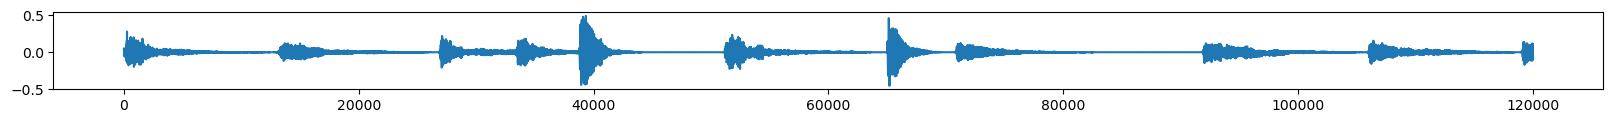

Finished epoch number 87 with a total of 10000 debug_seqs
 time: 2025-10-27 19:31:53.590422, epoch 88,  Loss: 0.2497
  Quantizer 0 Loss: 2.1925
  Quantizer 1 Loss: 3.1063
  Quantizer 2 Loss: 3.8517
  Quantizer 3 Loss: 4.3233
  Quantizer 4 Loss: 4.6275
  Quantizer 5 Loss: 4.8178
  Quantizer 6 Loss: 5.0441
  Quantizer 7 Loss: 5.1450
Latents embedded in 106 of the GRU input size of 128
Conditioning parameters embedded in 22 of the GRU input size of 128
DEVICE going in: model tensors cuda:0, enc_model cpu, c cuda:0
About toInitialize generator with c.shape = torch.Size([8])
params_seq.shape = torch.Size([10, 8])
plot the audio which has shape (120000,)


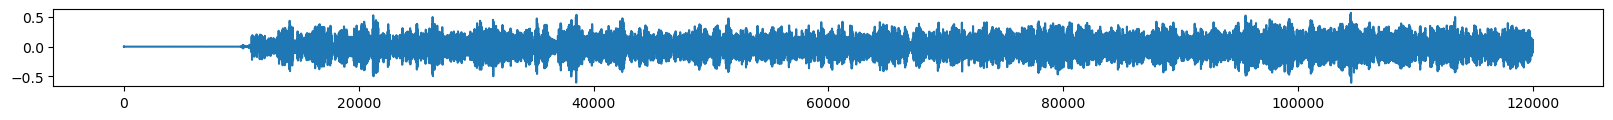

Finished epoch number 88 with a total of 10000 debug_seqs
 time: 2025-10-27 19:32:42.712089, epoch 89,  Loss: 0.2520
  Quantizer 0 Loss: 2.1962
  Quantizer 1 Loss: 3.1062
  Quantizer 2 Loss: 3.8641
  Quantizer 3 Loss: 4.3342
  Quantizer 4 Loss: 4.6426
  Quantizer 5 Loss: 4.8372
  Quantizer 6 Loss: 5.0688
  Quantizer 7 Loss: 5.1686
Latents embedded in 106 of the GRU input size of 128
Conditioning parameters embedded in 22 of the GRU input size of 128
DEVICE going in: model tensors cuda:0, enc_model cpu, c cuda:0
About toInitialize generator with c.shape = torch.Size([8])
params_seq.shape = torch.Size([10, 8])
plot the audio which has shape (120000,)


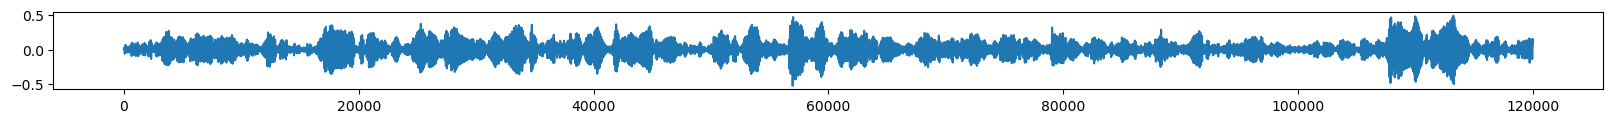

Finished epoch number 89 with a total of 10000 debug_seqs
 time: 2025-10-27 19:33:31.140724, epoch 90,  Loss: 0.2442
  Quantizer 0 Loss: 2.1973
  Quantizer 1 Loss: 3.1140
  Quantizer 2 Loss: 3.8575
  Quantizer 3 Loss: 4.3325
  Quantizer 4 Loss: 4.6392
  Quantizer 5 Loss: 4.8331
  Quantizer 6 Loss: 5.0635
  Quantizer 7 Loss: 5.1697
Latents embedded in 106 of the GRU input size of 128
Conditioning parameters embedded in 22 of the GRU input size of 128
DEVICE going in: model tensors cuda:0, enc_model cpu, c cuda:0
About toInitialize generator with c.shape = torch.Size([8])
params_seq.shape = torch.Size([10, 8])
plot the audio which has shape (120000,)


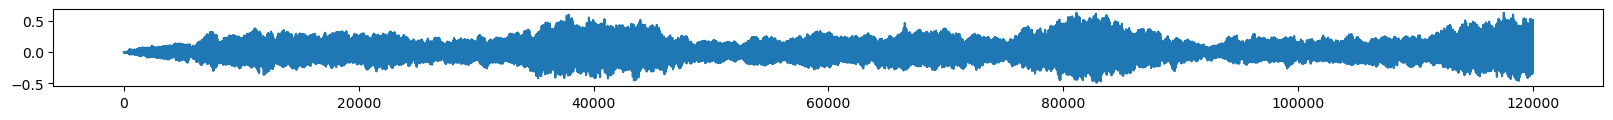

Finished epoch number 90 with a total of 10000 debug_seqs
 time: 2025-10-27 19:34:20.758191, epoch 91,  Loss: 0.2414
  Quantizer 0 Loss: 2.1847
  Quantizer 1 Loss: 3.1044
  Quantizer 2 Loss: 3.8512
  Quantizer 3 Loss: 4.3226
  Quantizer 4 Loss: 4.6329
  Quantizer 5 Loss: 4.8254
  Quantizer 6 Loss: 5.0550
  Quantizer 7 Loss: 5.1568
Latents embedded in 106 of the GRU input size of 128
Conditioning parameters embedded in 22 of the GRU input size of 128
DEVICE going in: model tensors cuda:0, enc_model cpu, c cuda:0
About toInitialize generator with c.shape = torch.Size([8])
params_seq.shape = torch.Size([10, 8])
plot the audio which has shape (120000,)


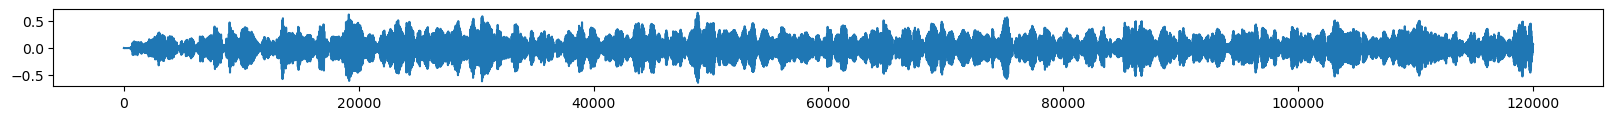

Finished epoch number 91 with a total of 10000 debug_seqs
 time: 2025-10-27 19:35:09.939204, epoch 92,  Loss: 0.2408
  Quantizer 0 Loss: 2.1895
  Quantizer 1 Loss: 3.0990
  Quantizer 2 Loss: 3.8547
  Quantizer 3 Loss: 4.3220
  Quantizer 4 Loss: 4.6318
  Quantizer 5 Loss: 4.8211
  Quantizer 6 Loss: 5.0507
  Quantizer 7 Loss: 5.1557
Latents embedded in 106 of the GRU input size of 128
Conditioning parameters embedded in 22 of the GRU input size of 128
DEVICE going in: model tensors cuda:0, enc_model cpu, c cuda:0
About toInitialize generator with c.shape = torch.Size([8])
params_seq.shape = torch.Size([10, 8])
plot the audio which has shape (120000,)


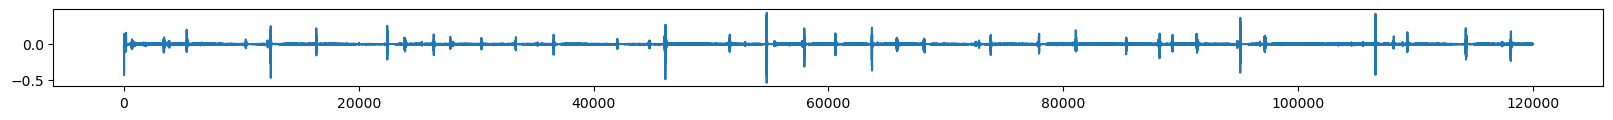

Finished epoch number 92 with a total of 10000 debug_seqs
 time: 2025-10-27 19:36:00.117361, epoch 93,  Loss: 0.2434
  Quantizer 0 Loss: 2.1868
  Quantizer 1 Loss: 3.1007
  Quantizer 2 Loss: 3.8532
  Quantizer 3 Loss: 4.3243
  Quantizer 4 Loss: 4.6336
  Quantizer 5 Loss: 4.8248
  Quantizer 6 Loss: 5.0582
  Quantizer 7 Loss: 5.1582
Latents embedded in 106 of the GRU input size of 128
Conditioning parameters embedded in 22 of the GRU input size of 128
DEVICE going in: model tensors cuda:0, enc_model cpu, c cuda:0
About toInitialize generator with c.shape = torch.Size([8])
params_seq.shape = torch.Size([10, 8])
plot the audio which has shape (120000,)


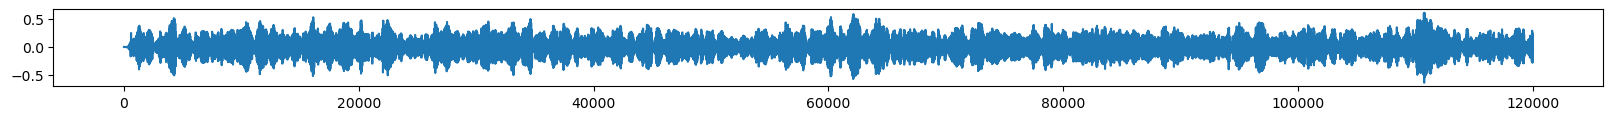

Finished epoch number 93 with a total of 10000 debug_seqs
 time: 2025-10-27 19:36:49.832661, epoch 94,  Loss: 0.2476
  Quantizer 0 Loss: 2.2051
  Quantizer 1 Loss: 3.1177
  Quantizer 2 Loss: 3.8642
  Quantizer 3 Loss: 4.3328
  Quantizer 4 Loss: 4.6406
  Quantizer 5 Loss: 4.8353
  Quantizer 6 Loss: 5.0660
  Quantizer 7 Loss: 5.1679
Latents embedded in 106 of the GRU input size of 128
Conditioning parameters embedded in 22 of the GRU input size of 128
DEVICE going in: model tensors cuda:0, enc_model cpu, c cuda:0
About toInitialize generator with c.shape = torch.Size([8])
params_seq.shape = torch.Size([10, 8])
plot the audio which has shape (120000,)


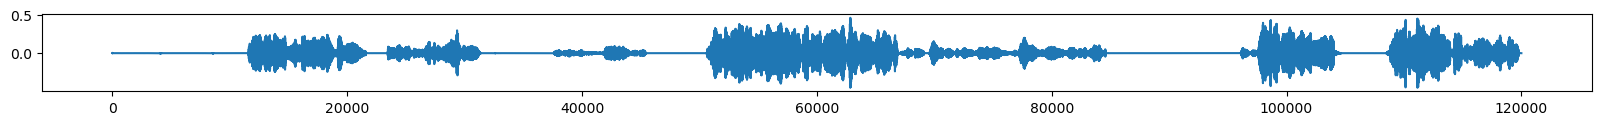

Finished epoch number 94 with a total of 10000 debug_seqs
 time: 2025-10-27 19:37:38.541764, epoch 95,  Loss: 0.2390
  Quantizer 0 Loss: 2.1957
  Quantizer 1 Loss: 3.1072
  Quantizer 2 Loss: 3.8618
  Quantizer 3 Loss: 4.3302
  Quantizer 4 Loss: 4.6424
  Quantizer 5 Loss: 4.8319
  Quantizer 6 Loss: 5.0625
  Quantizer 7 Loss: 5.1651
Latents embedded in 106 of the GRU input size of 128
Conditioning parameters embedded in 22 of the GRU input size of 128
DEVICE going in: model tensors cuda:0, enc_model cpu, c cuda:0
About toInitialize generator with c.shape = torch.Size([8])
params_seq.shape = torch.Size([10, 8])
plot the audio which has shape (120000,)


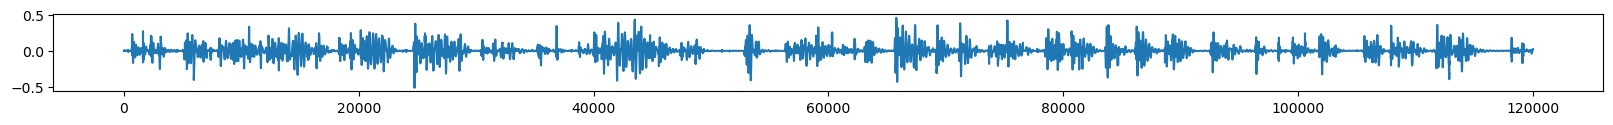

Finished epoch number 95 with a total of 10000 debug_seqs
 time: 2025-10-27 19:38:28.582059, epoch 96,  Loss: 0.2484
  Quantizer 0 Loss: 2.1977
  Quantizer 1 Loss: 3.1101
  Quantizer 2 Loss: 3.8600
  Quantizer 3 Loss: 4.3255
  Quantizer 4 Loss: 4.6312
  Quantizer 5 Loss: 4.8247
  Quantizer 6 Loss: 5.0549
  Quantizer 7 Loss: 5.1567
Latents embedded in 106 of the GRU input size of 128
Conditioning parameters embedded in 22 of the GRU input size of 128
DEVICE going in: model tensors cuda:0, enc_model cpu, c cuda:0
About toInitialize generator with c.shape = torch.Size([8])
params_seq.shape = torch.Size([10, 8])
plot the audio which has shape (120000,)


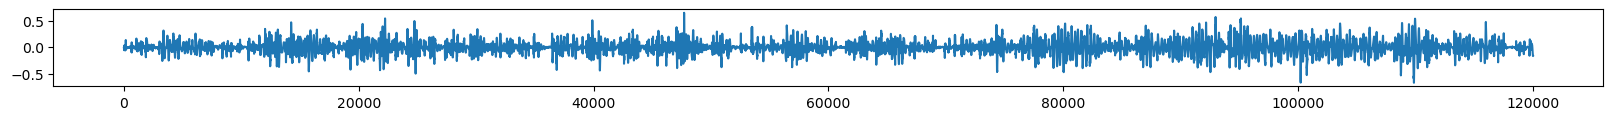

Finished epoch number 96 with a total of 10000 debug_seqs
 time: 2025-10-27 19:39:17.853427, epoch 97,  Loss: 0.2428
  Quantizer 0 Loss: 2.1835
  Quantizer 1 Loss: 3.1084
  Quantizer 2 Loss: 3.8549
  Quantizer 3 Loss: 4.3220
  Quantizer 4 Loss: 4.6363
  Quantizer 5 Loss: 4.8301
  Quantizer 6 Loss: 5.0593
  Quantizer 7 Loss: 5.1606
Latents embedded in 106 of the GRU input size of 128
Conditioning parameters embedded in 22 of the GRU input size of 128
DEVICE going in: model tensors cuda:0, enc_model cpu, c cuda:0
About toInitialize generator with c.shape = torch.Size([8])
params_seq.shape = torch.Size([10, 8])
plot the audio which has shape (120000,)


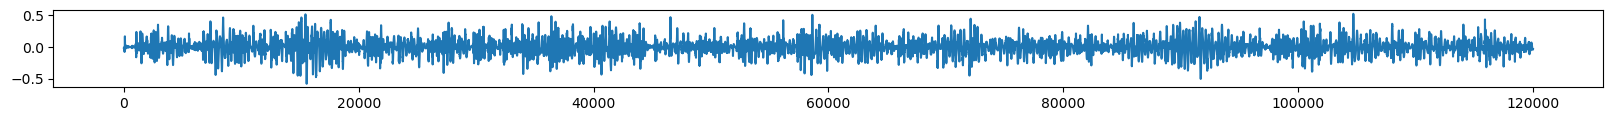

Finished epoch number 97 with a total of 10000 debug_seqs
 time: 2025-10-27 19:40:06.553993, epoch 98,  Loss: 0.2384
  Quantizer 0 Loss: 2.1907
  Quantizer 1 Loss: 3.0922
  Quantizer 2 Loss: 3.8459
  Quantizer 3 Loss: 4.3214
  Quantizer 4 Loss: 4.6319
  Quantizer 5 Loss: 4.8239
  Quantizer 6 Loss: 5.0547
  Quantizer 7 Loss: 5.1633
Latents embedded in 106 of the GRU input size of 128
Conditioning parameters embedded in 22 of the GRU input size of 128
DEVICE going in: model tensors cuda:0, enc_model cpu, c cuda:0
About toInitialize generator with c.shape = torch.Size([8])
params_seq.shape = torch.Size([10, 8])
plot the audio which has shape (120000,)


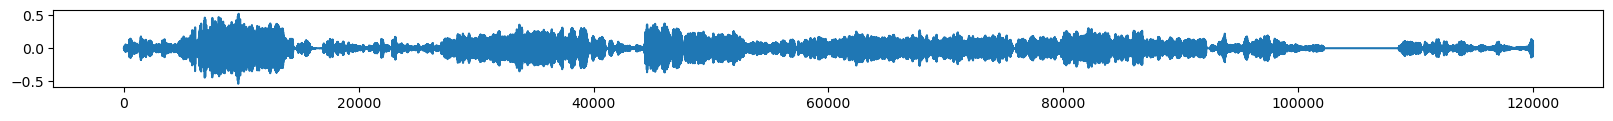

Finished epoch number 98 with a total of 10000 debug_seqs
 time: 2025-10-27 19:40:54.958195, epoch 99,  Loss: 0.2379
  Quantizer 0 Loss: 2.1791
  Quantizer 1 Loss: 3.0988
  Quantizer 2 Loss: 3.8453
  Quantizer 3 Loss: 4.3194
  Quantizer 4 Loss: 4.6277
  Quantizer 5 Loss: 4.8184
  Quantizer 6 Loss: 5.0531
  Quantizer 7 Loss: 5.1555
Latents embedded in 106 of the GRU input size of 128
Conditioning parameters embedded in 22 of the GRU input size of 128
DEVICE going in: model tensors cuda:0, enc_model cpu, c cuda:0
About toInitialize generator with c.shape = torch.Size([8])
params_seq.shape = torch.Size([10, 8])
plot the audio which has shape (120000,)


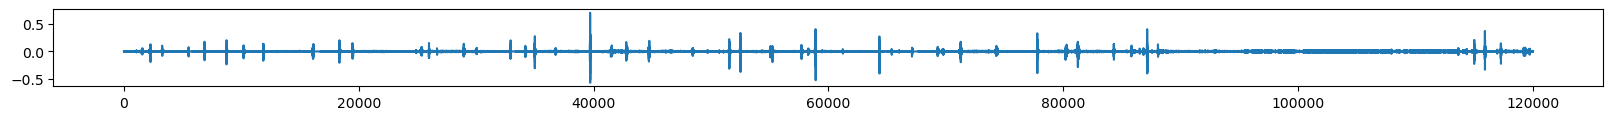

Finished epoch number 99 with a total of 10000 debug_seqs
 time: 2025-10-27 19:41:43.938734, epoch 100,  Loss: 0.2486
  Quantizer 0 Loss: 2.1928
  Quantizer 1 Loss: 3.1069
  Quantizer 2 Loss: 3.8584
  Quantizer 3 Loss: 4.3278
  Quantizer 4 Loss: 4.6365
  Quantizer 5 Loss: 4.8283
  Quantizer 6 Loss: 5.0538
  Quantizer 7 Loss: 5.1551
Latents embedded in 106 of the GRU input size of 128
Conditioning parameters embedded in 22 of the GRU input size of 128
DEVICE going in: model tensors cuda:0, enc_model cpu, c cuda:0
About toInitialize generator with c.shape = torch.Size([8])
params_seq.shape = torch.Size([10, 8])
plot the audio which has shape (120000,)


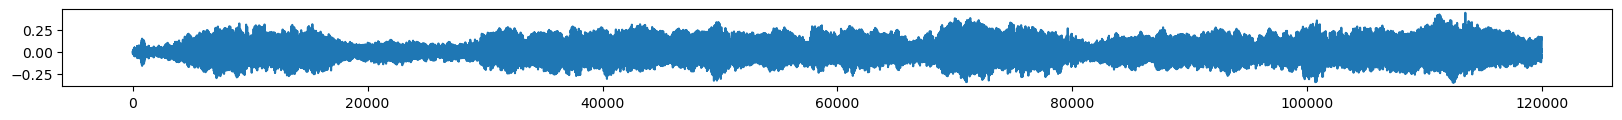

Saved checkpoint at epoch 100
Finished epoch number 100 with a total of 10000 debug_seqs
 time: 2025-10-27 19:42:32.976947, epoch 101,  Loss: 0.2189
  Quantizer 0 Loss: 2.1827
  Quantizer 1 Loss: 2.7343
  Quantizer 2 Loss: 3.4283
  Quantizer 3 Loss: 3.8990
  Quantizer 4 Loss: 4.2225
  Quantizer 5 Loss: 4.4311
  Quantizer 6 Loss: 4.6755
  Quantizer 7 Loss: 4.8020
Latents embedded in 106 of the GRU input size of 128
Conditioning parameters embedded in 22 of the GRU input size of 128
DEVICE going in: model tensors cuda:0, enc_model cpu, c cuda:0
About toInitialize generator with c.shape = torch.Size([8])
params_seq.shape = torch.Size([10, 8])
plot the audio which has shape (120000,)


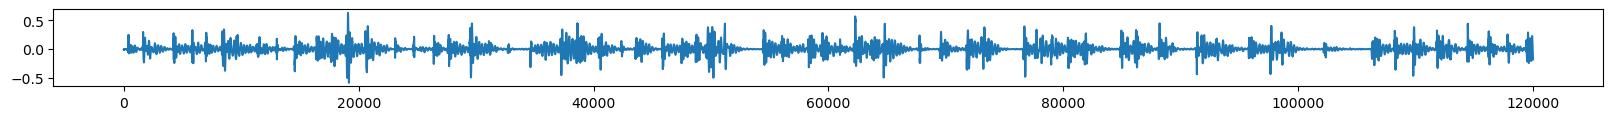

Finished epoch number 101 with a total of 10000 debug_seqs
 time: 2025-10-27 19:43:22.738284, epoch 102,  Loss: 0.2151
  Quantizer 0 Loss: 2.1598
  Quantizer 1 Loss: 2.6788
  Quantizer 2 Loss: 3.3503
  Quantizer 3 Loss: 3.8177
  Quantizer 4 Loss: 4.1340
  Quantizer 5 Loss: 4.3457
  Quantizer 6 Loss: 4.5877
  Quantizer 7 Loss: 4.7146
Latents embedded in 106 of the GRU input size of 128
Conditioning parameters embedded in 22 of the GRU input size of 128
DEVICE going in: model tensors cuda:0, enc_model cpu, c cuda:0
About toInitialize generator with c.shape = torch.Size([8])
params_seq.shape = torch.Size([10, 8])
plot the audio which has shape (120000,)


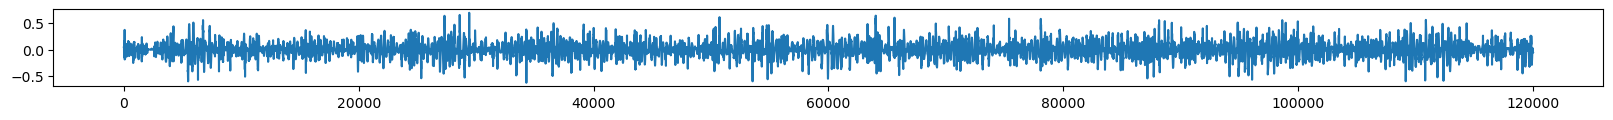

Finished epoch number 102 with a total of 10000 debug_seqs
 time: 2025-10-27 19:44:12.456443, epoch 103,  Loss: 0.2152
  Quantizer 0 Loss: 2.1703
  Quantizer 1 Loss: 2.6825
  Quantizer 2 Loss: 3.3503
  Quantizer 3 Loss: 3.8090
  Quantizer 4 Loss: 4.1319
  Quantizer 5 Loss: 4.3379
  Quantizer 6 Loss: 4.5864
  Quantizer 7 Loss: 4.7178
Latents embedded in 106 of the GRU input size of 128
Conditioning parameters embedded in 22 of the GRU input size of 128
DEVICE going in: model tensors cuda:0, enc_model cpu, c cuda:0
About toInitialize generator with c.shape = torch.Size([8])
params_seq.shape = torch.Size([10, 8])
plot the audio which has shape (120000,)


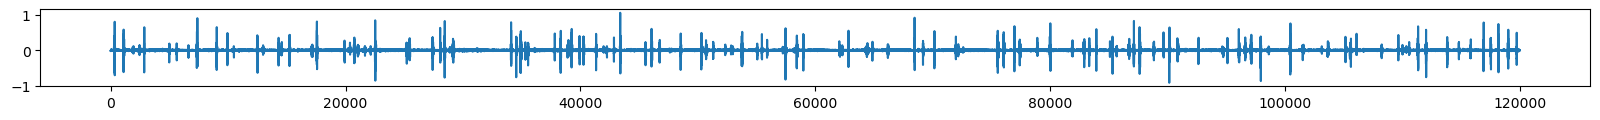

Finished epoch number 103 with a total of 10000 debug_seqs
 time: 2025-10-27 19:45:00.507440, epoch 104,  Loss: 0.2246
  Quantizer 0 Loss: 2.1747
  Quantizer 1 Loss: 2.6862
  Quantizer 2 Loss: 3.3507
  Quantizer 3 Loss: 3.8050
  Quantizer 4 Loss: 4.1270
  Quantizer 5 Loss: 4.3302
  Quantizer 6 Loss: 4.5794
  Quantizer 7 Loss: 4.7075
Latents embedded in 106 of the GRU input size of 128
Conditioning parameters embedded in 22 of the GRU input size of 128
DEVICE going in: model tensors cuda:0, enc_model cpu, c cuda:0
About toInitialize generator with c.shape = torch.Size([8])
params_seq.shape = torch.Size([10, 8])
plot the audio which has shape (120000,)


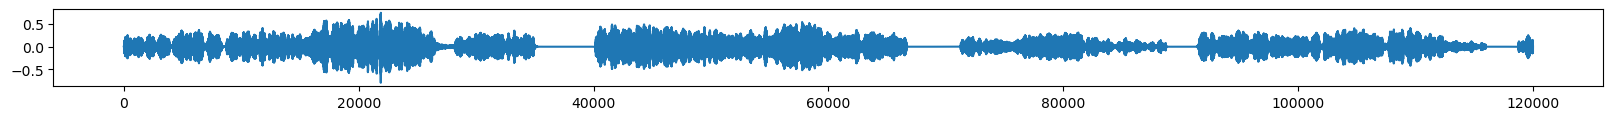

Finished epoch number 104 with a total of 10000 debug_seqs
 time: 2025-10-27 19:45:49.691861, epoch 105,  Loss: 0.2133
  Quantizer 0 Loss: 2.1744
  Quantizer 1 Loss: 2.6797
  Quantizer 2 Loss: 3.3400
  Quantizer 3 Loss: 3.7971
  Quantizer 4 Loss: 4.1150
  Quantizer 5 Loss: 4.3177
  Quantizer 6 Loss: 4.5653
  Quantizer 7 Loss: 4.6934
Latents embedded in 106 of the GRU input size of 128
Conditioning parameters embedded in 22 of the GRU input size of 128
DEVICE going in: model tensors cuda:0, enc_model cpu, c cuda:0
About toInitialize generator with c.shape = torch.Size([8])
params_seq.shape = torch.Size([10, 8])
plot the audio which has shape (120000,)


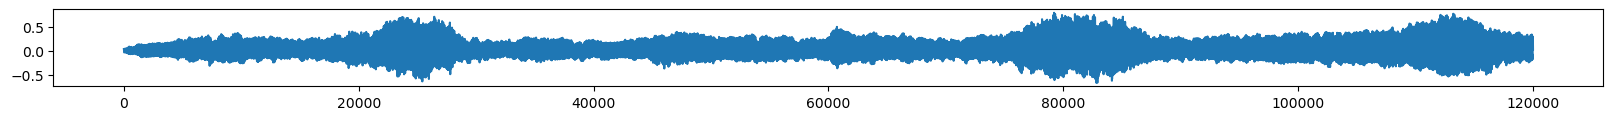

Finished epoch number 105 with a total of 10000 debug_seqs
 time: 2025-10-27 19:46:38.658817, epoch 106,  Loss: 0.2241
  Quantizer 0 Loss: 2.1654
  Quantizer 1 Loss: 2.6750
  Quantizer 2 Loss: 3.3362
  Quantizer 3 Loss: 3.7917
  Quantizer 4 Loss: 4.1056
  Quantizer 5 Loss: 4.3094
  Quantizer 6 Loss: 4.5544
  Quantizer 7 Loss: 4.6840
Latents embedded in 106 of the GRU input size of 128
Conditioning parameters embedded in 22 of the GRU input size of 128
DEVICE going in: model tensors cuda:0, enc_model cpu, c cuda:0
About toInitialize generator with c.shape = torch.Size([8])
params_seq.shape = torch.Size([10, 8])
plot the audio which has shape (120000,)


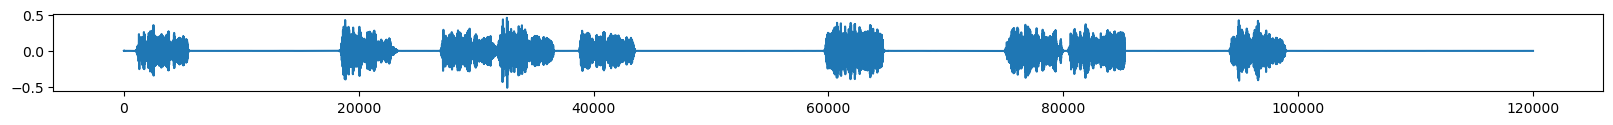

Finished epoch number 106 with a total of 10000 debug_seqs
 time: 2025-10-27 19:47:27.119460, epoch 107,  Loss: 0.2153
  Quantizer 0 Loss: 2.1868
  Quantizer 1 Loss: 2.6919
  Quantizer 2 Loss: 3.3490
  Quantizer 3 Loss: 3.8051
  Quantizer 4 Loss: 4.1184
  Quantizer 5 Loss: 4.3255
  Quantizer 6 Loss: 4.5683
  Quantizer 7 Loss: 4.6989
Latents embedded in 106 of the GRU input size of 128
Conditioning parameters embedded in 22 of the GRU input size of 128
DEVICE going in: model tensors cuda:0, enc_model cpu, c cuda:0
About toInitialize generator with c.shape = torch.Size([8])
params_seq.shape = torch.Size([10, 8])
plot the audio which has shape (120000,)


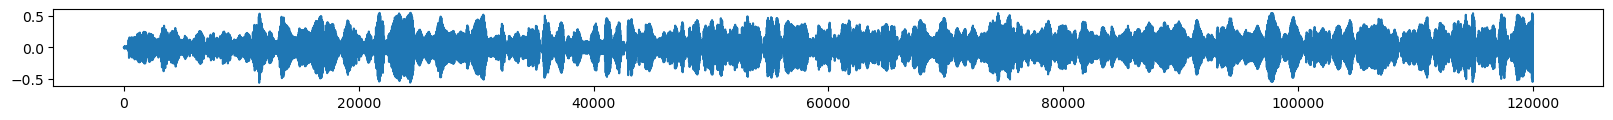

Finished epoch number 107 with a total of 10000 debug_seqs
 time: 2025-10-27 19:48:16.089237, epoch 108,  Loss: 0.2191
  Quantizer 0 Loss: 2.1769
  Quantizer 1 Loss: 2.6886
  Quantizer 2 Loss: 3.3473
  Quantizer 3 Loss: 3.7988
  Quantizer 4 Loss: 4.1166
  Quantizer 5 Loss: 4.3215
  Quantizer 6 Loss: 4.5683
  Quantizer 7 Loss: 4.6983
Latents embedded in 106 of the GRU input size of 128
Conditioning parameters embedded in 22 of the GRU input size of 128
DEVICE going in: model tensors cuda:0, enc_model cpu, c cuda:0
About toInitialize generator with c.shape = torch.Size([8])
params_seq.shape = torch.Size([10, 8])
plot the audio which has shape (120000,)


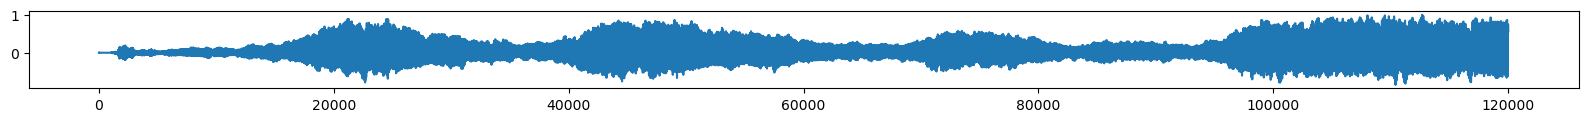

Finished epoch number 108 with a total of 10000 debug_seqs
 time: 2025-10-27 19:49:06.274911, epoch 109,  Loss: 0.2179
  Quantizer 0 Loss: 2.1722
  Quantizer 1 Loss: 2.6766
  Quantizer 2 Loss: 3.3372
  Quantizer 3 Loss: 3.7859
  Quantizer 4 Loss: 4.1066
  Quantizer 5 Loss: 4.3148
  Quantizer 6 Loss: 4.5562
  Quantizer 7 Loss: 4.6918
Latents embedded in 106 of the GRU input size of 128
Conditioning parameters embedded in 22 of the GRU input size of 128
DEVICE going in: model tensors cuda:0, enc_model cpu, c cuda:0
About toInitialize generator with c.shape = torch.Size([8])
params_seq.shape = torch.Size([10, 8])
plot the audio which has shape (120000,)


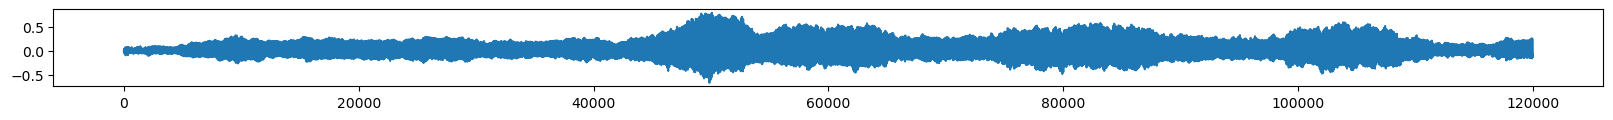

Finished epoch number 109 with a total of 10000 debug_seqs
 time: 2025-10-27 19:49:55.083333, epoch 110,  Loss: 0.2231
  Quantizer 0 Loss: 2.1793
  Quantizer 1 Loss: 2.6889
  Quantizer 2 Loss: 3.3420
  Quantizer 3 Loss: 3.7936
  Quantizer 4 Loss: 4.1164
  Quantizer 5 Loss: 4.3217
  Quantizer 6 Loss: 4.5608
  Quantizer 7 Loss: 4.6977
Latents embedded in 106 of the GRU input size of 128
Conditioning parameters embedded in 22 of the GRU input size of 128
DEVICE going in: model tensors cuda:0, enc_model cpu, c cuda:0
About toInitialize generator with c.shape = torch.Size([8])
params_seq.shape = torch.Size([10, 8])
plot the audio which has shape (120000,)


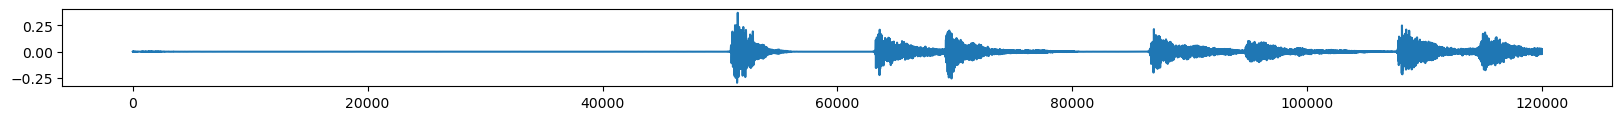

Finished epoch number 110 with a total of 10000 debug_seqs
 time: 2025-10-27 19:50:43.712787, epoch 111,  Loss: 0.2206
  Quantizer 0 Loss: 2.1751
  Quantizer 1 Loss: 2.6734
  Quantizer 2 Loss: 3.3292
  Quantizer 3 Loss: 3.7821
  Quantizer 4 Loss: 4.0917
  Quantizer 5 Loss: 4.3025
  Quantizer 6 Loss: 4.5443
  Quantizer 7 Loss: 4.6760
Latents embedded in 106 of the GRU input size of 128
Conditioning parameters embedded in 22 of the GRU input size of 128
DEVICE going in: model tensors cuda:0, enc_model cpu, c cuda:0
About toInitialize generator with c.shape = torch.Size([8])
params_seq.shape = torch.Size([10, 8])
plot the audio which has shape (120000,)


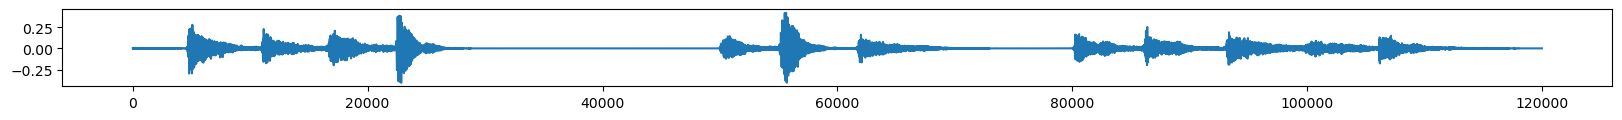

Finished epoch number 111 with a total of 10000 debug_seqs
 time: 2025-10-27 19:51:33.309091, epoch 112,  Loss: 0.2196
  Quantizer 0 Loss: 2.1708
  Quantizer 1 Loss: 2.6787
  Quantizer 2 Loss: 3.3361
  Quantizer 3 Loss: 3.7873
  Quantizer 4 Loss: 4.1060
  Quantizer 5 Loss: 4.3123
  Quantizer 6 Loss: 4.5547
  Quantizer 7 Loss: 4.6940
Latents embedded in 106 of the GRU input size of 128
Conditioning parameters embedded in 22 of the GRU input size of 128
DEVICE going in: model tensors cuda:0, enc_model cpu, c cuda:0
About toInitialize generator with c.shape = torch.Size([8])
params_seq.shape = torch.Size([10, 8])
plot the audio which has shape (120000,)


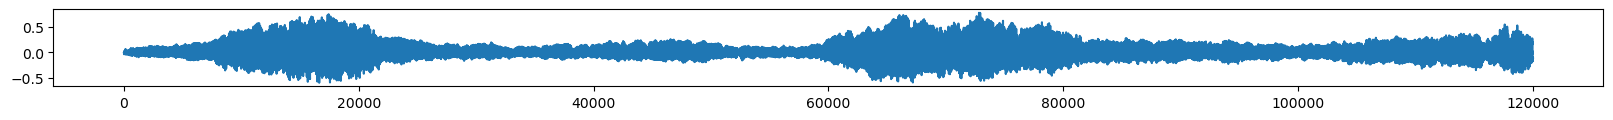

Finished epoch number 112 with a total of 10000 debug_seqs
 time: 2025-10-27 19:52:22.407246, epoch 113,  Loss: 0.2158
  Quantizer 0 Loss: 2.1733
  Quantizer 1 Loss: 2.6794
  Quantizer 2 Loss: 3.3284
  Quantizer 3 Loss: 3.7824
  Quantizer 4 Loss: 4.0997
  Quantizer 5 Loss: 4.3041
  Quantizer 6 Loss: 4.5581
  Quantizer 7 Loss: 4.6901
Latents embedded in 106 of the GRU input size of 128
Conditioning parameters embedded in 22 of the GRU input size of 128
DEVICE going in: model tensors cuda:0, enc_model cpu, c cuda:0
About toInitialize generator with c.shape = torch.Size([8])
params_seq.shape = torch.Size([10, 8])
plot the audio which has shape (120000,)


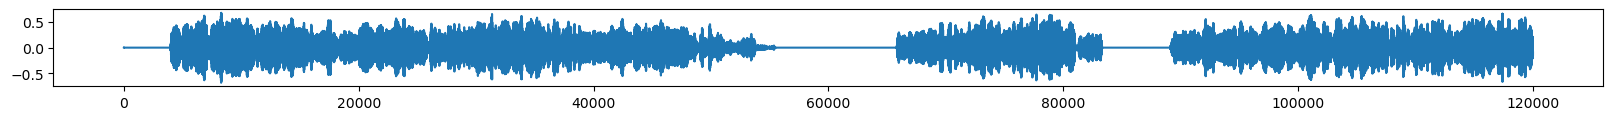

Finished epoch number 113 with a total of 10000 debug_seqs
 time: 2025-10-27 19:53:11.539629, epoch 114,  Loss: 0.2117
  Quantizer 0 Loss: 2.1714
  Quantizer 1 Loss: 2.6763
  Quantizer 2 Loss: 3.3287
  Quantizer 3 Loss: 3.7827
  Quantizer 4 Loss: 4.0974
  Quantizer 5 Loss: 4.3030
  Quantizer 6 Loss: 4.5450
  Quantizer 7 Loss: 4.6768
Latents embedded in 106 of the GRU input size of 128
Conditioning parameters embedded in 22 of the GRU input size of 128
DEVICE going in: model tensors cuda:0, enc_model cpu, c cuda:0
About toInitialize generator with c.shape = torch.Size([8])
params_seq.shape = torch.Size([10, 8])
plot the audio which has shape (120000,)


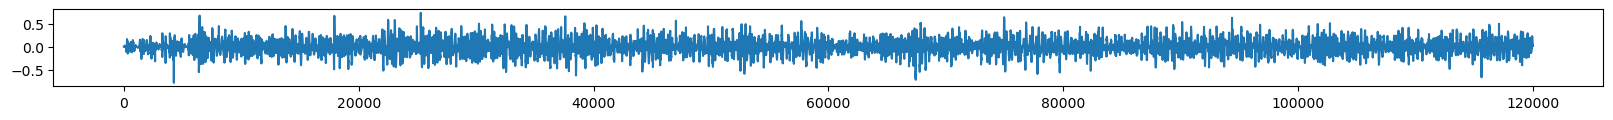

Finished epoch number 114 with a total of 10000 debug_seqs
 time: 2025-10-27 19:53:59.497463, epoch 115,  Loss: 0.2168
  Quantizer 0 Loss: 2.1546
  Quantizer 1 Loss: 2.6567
  Quantizer 2 Loss: 3.3110
  Quantizer 3 Loss: 3.7621
  Quantizer 4 Loss: 4.0828
  Quantizer 5 Loss: 4.2887
  Quantizer 6 Loss: 4.5303
  Quantizer 7 Loss: 4.6654
Latents embedded in 106 of the GRU input size of 128
Conditioning parameters embedded in 22 of the GRU input size of 128
DEVICE going in: model tensors cuda:0, enc_model cpu, c cuda:0
About toInitialize generator with c.shape = torch.Size([8])
params_seq.shape = torch.Size([10, 8])
plot the audio which has shape (120000,)


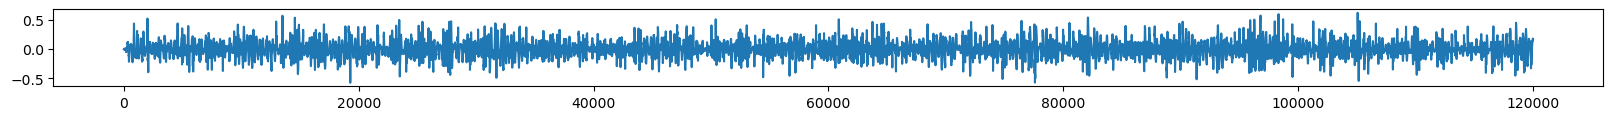

Finished epoch number 115 with a total of 10000 debug_seqs
 time: 2025-10-27 19:54:47.535525, epoch 116,  Loss: 0.2233
  Quantizer 0 Loss: 2.1732
  Quantizer 1 Loss: 2.6697
  Quantizer 2 Loss: 3.3212
  Quantizer 3 Loss: 3.7769
  Quantizer 4 Loss: 4.0928
  Quantizer 5 Loss: 4.2945
  Quantizer 6 Loss: 4.5348
  Quantizer 7 Loss: 4.6696
Latents embedded in 106 of the GRU input size of 128
Conditioning parameters embedded in 22 of the GRU input size of 128
DEVICE going in: model tensors cuda:0, enc_model cpu, c cuda:0
About toInitialize generator with c.shape = torch.Size([8])
params_seq.shape = torch.Size([10, 8])
plot the audio which has shape (120000,)


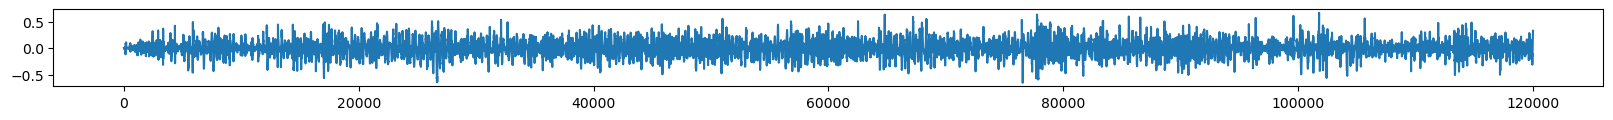

Finished epoch number 116 with a total of 10000 debug_seqs
 time: 2025-10-27 19:55:36.706257, epoch 117,  Loss: 0.2160
  Quantizer 0 Loss: 2.1754
  Quantizer 1 Loss: 2.6788
  Quantizer 2 Loss: 3.3388
  Quantizer 3 Loss: 3.7839
  Quantizer 4 Loss: 4.1038
  Quantizer 5 Loss: 4.3065
  Quantizer 6 Loss: 4.5507
  Quantizer 7 Loss: 4.6812
Latents embedded in 106 of the GRU input size of 128
Conditioning parameters embedded in 22 of the GRU input size of 128
DEVICE going in: model tensors cuda:0, enc_model cpu, c cuda:0
About toInitialize generator with c.shape = torch.Size([8])
params_seq.shape = torch.Size([10, 8])
plot the audio which has shape (120000,)


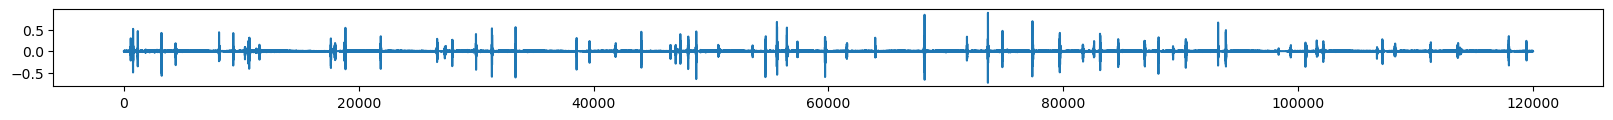

Finished epoch number 117 with a total of 10000 debug_seqs
 time: 2025-10-27 19:56:24.620741, epoch 118,  Loss: 0.2163
  Quantizer 0 Loss: 2.1610
  Quantizer 1 Loss: 2.6703
  Quantizer 2 Loss: 3.3158
  Quantizer 3 Loss: 3.7684
  Quantizer 4 Loss: 4.0829
  Quantizer 5 Loss: 4.2950
  Quantizer 6 Loss: 4.5376
  Quantizer 7 Loss: 4.6727
Latents embedded in 106 of the GRU input size of 128
Conditioning parameters embedded in 22 of the GRU input size of 128
DEVICE going in: model tensors cuda:0, enc_model cpu, c cuda:0
About toInitialize generator with c.shape = torch.Size([8])
params_seq.shape = torch.Size([10, 8])
plot the audio which has shape (120000,)


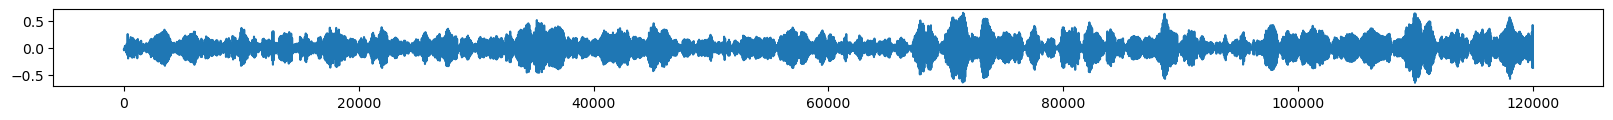

Finished epoch number 118 with a total of 10000 debug_seqs
 time: 2025-10-27 19:57:12.944840, epoch 119,  Loss: 0.2190
  Quantizer 0 Loss: 2.1768
  Quantizer 1 Loss: 2.6784
  Quantizer 2 Loss: 3.3267
  Quantizer 3 Loss: 3.7819
  Quantizer 4 Loss: 4.0919
  Quantizer 5 Loss: 4.3024
  Quantizer 6 Loss: 4.5459
  Quantizer 7 Loss: 4.6775
Latents embedded in 106 of the GRU input size of 128
Conditioning parameters embedded in 22 of the GRU input size of 128
DEVICE going in: model tensors cuda:0, enc_model cpu, c cuda:0
About toInitialize generator with c.shape = torch.Size([8])
params_seq.shape = torch.Size([10, 8])
plot the audio which has shape (120000,)


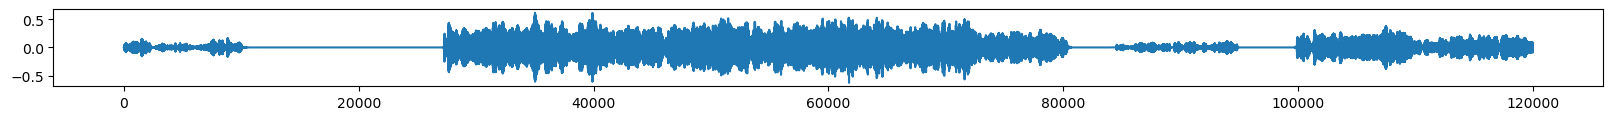

Finished epoch number 119 with a total of 10000 debug_seqs
 time: 2025-10-27 19:58:01.793149, epoch 120,  Loss: 0.2255
  Quantizer 0 Loss: 2.1884
  Quantizer 1 Loss: 2.6869
  Quantizer 2 Loss: 3.3443
  Quantizer 3 Loss: 3.7942
  Quantizer 4 Loss: 4.1083
  Quantizer 5 Loss: 4.3157
  Quantizer 6 Loss: 4.5581
  Quantizer 7 Loss: 4.6912
Latents embedded in 106 of the GRU input size of 128
Conditioning parameters embedded in 22 of the GRU input size of 128
DEVICE going in: model tensors cuda:0, enc_model cpu, c cuda:0
About toInitialize generator with c.shape = torch.Size([8])
params_seq.shape = torch.Size([10, 8])
plot the audio which has shape (120000,)


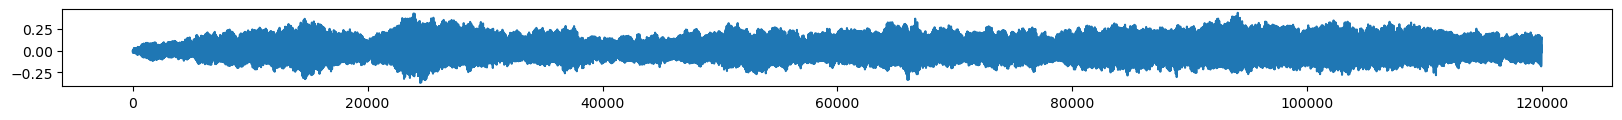

Finished epoch number 120 with a total of 10000 debug_seqs
 time: 2025-10-27 19:58:49.736752, epoch 121,  Loss: 0.2132
  Quantizer 0 Loss: 2.1729
  Quantizer 1 Loss: 2.6757
  Quantizer 2 Loss: 3.3222
  Quantizer 3 Loss: 3.7718
  Quantizer 4 Loss: 4.0842
  Quantizer 5 Loss: 4.2830
  Quantizer 6 Loss: 4.5341
  Quantizer 7 Loss: 4.6658
Latents embedded in 106 of the GRU input size of 128
Conditioning parameters embedded in 22 of the GRU input size of 128
DEVICE going in: model tensors cuda:0, enc_model cpu, c cuda:0
About toInitialize generator with c.shape = torch.Size([8])
params_seq.shape = torch.Size([10, 8])
plot the audio which has shape (120000,)


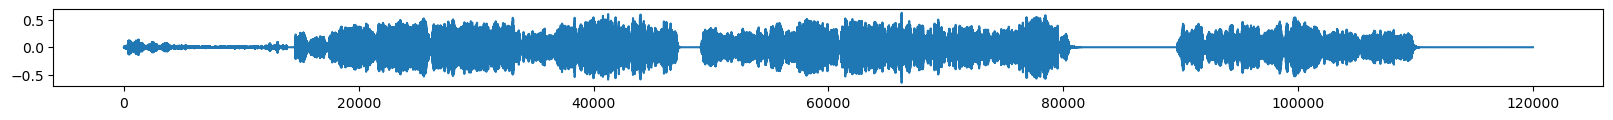

Finished epoch number 121 with a total of 10000 debug_seqs
 time: 2025-10-27 19:59:38.122550, epoch 122,  Loss: 0.2167
  Quantizer 0 Loss: 2.1771
  Quantizer 1 Loss: 2.6792
  Quantizer 2 Loss: 3.3317
  Quantizer 3 Loss: 3.7841
  Quantizer 4 Loss: 4.1018
  Quantizer 5 Loss: 4.3070
  Quantizer 6 Loss: 4.5548
  Quantizer 7 Loss: 4.6888
Latents embedded in 106 of the GRU input size of 128
Conditioning parameters embedded in 22 of the GRU input size of 128
DEVICE going in: model tensors cuda:0, enc_model cpu, c cuda:0
About toInitialize generator with c.shape = torch.Size([8])
params_seq.shape = torch.Size([10, 8])
plot the audio which has shape (120000,)


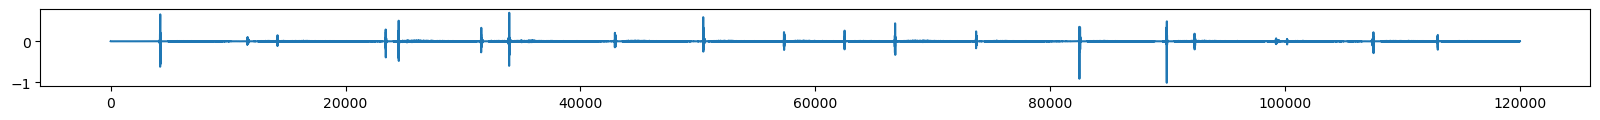

Finished epoch number 122 with a total of 10000 debug_seqs
 time: 2025-10-27 20:00:26.707734, epoch 123,  Loss: 0.2257
  Quantizer 0 Loss: 2.1611
  Quantizer 1 Loss: 2.6617
  Quantizer 2 Loss: 3.3142
  Quantizer 3 Loss: 3.7697
  Quantizer 4 Loss: 4.0892
  Quantizer 5 Loss: 4.2897
  Quantizer 6 Loss: 4.5383
  Quantizer 7 Loss: 4.6718
Latents embedded in 106 of the GRU input size of 128
Conditioning parameters embedded in 22 of the GRU input size of 128
DEVICE going in: model tensors cuda:0, enc_model cpu, c cuda:0
About toInitialize generator with c.shape = torch.Size([8])
params_seq.shape = torch.Size([10, 8])
plot the audio which has shape (120000,)


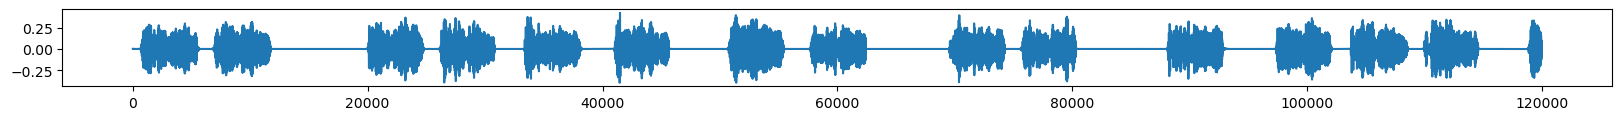

Finished epoch number 123 with a total of 10000 debug_seqs
 time: 2025-10-27 20:01:15.026895, epoch 124,  Loss: 0.2120
  Quantizer 0 Loss: 2.1798
  Quantizer 1 Loss: 2.6764
  Quantizer 2 Loss: 3.3307
  Quantizer 3 Loss: 3.7798
  Quantizer 4 Loss: 4.0997
  Quantizer 5 Loss: 4.3013
  Quantizer 6 Loss: 4.5477
  Quantizer 7 Loss: 4.6787
Latents embedded in 106 of the GRU input size of 128
Conditioning parameters embedded in 22 of the GRU input size of 128
DEVICE going in: model tensors cuda:0, enc_model cpu, c cuda:0
About toInitialize generator with c.shape = torch.Size([8])
params_seq.shape = torch.Size([10, 8])
plot the audio which has shape (120000,)


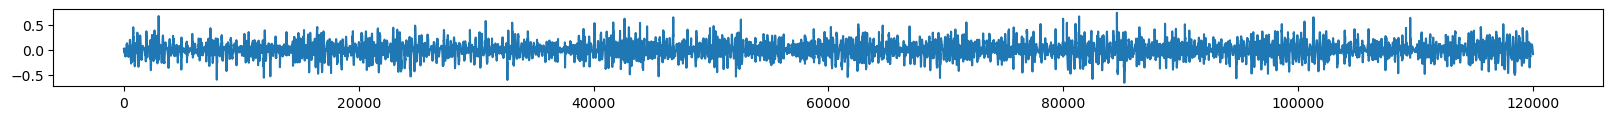

Finished epoch number 124 with a total of 10000 debug_seqs
 time: 2025-10-27 20:02:02.995604, epoch 125,  Loss: 0.2140
  Quantizer 0 Loss: 2.1687
  Quantizer 1 Loss: 2.6698
  Quantizer 2 Loss: 3.3201
  Quantizer 3 Loss: 3.7729
  Quantizer 4 Loss: 4.0882
  Quantizer 5 Loss: 4.2888
  Quantizer 6 Loss: 4.5319
  Quantizer 7 Loss: 4.6668
Latents embedded in 106 of the GRU input size of 128
Conditioning parameters embedded in 22 of the GRU input size of 128
DEVICE going in: model tensors cuda:0, enc_model cpu, c cuda:0
About toInitialize generator with c.shape = torch.Size([8])
params_seq.shape = torch.Size([10, 8])
plot the audio which has shape (120000,)


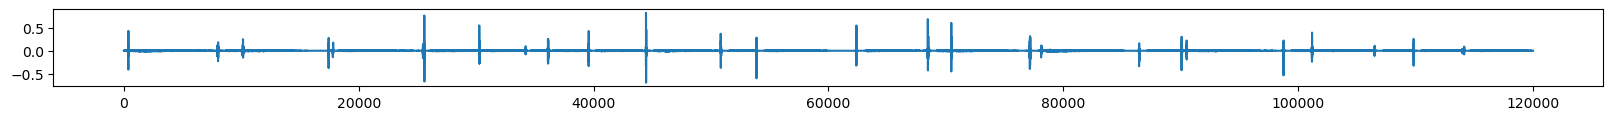

Saved checkpoint at epoch 125
Finished epoch number 125 with a total of 10000 debug_seqs
 time: 2025-10-27 20:02:50.495567, epoch 126,  Loss: 0.2472
  Quantizer 0 Loss: 2.2895
  Quantizer 1 Loss: 3.3593
  Quantizer 2 Loss: 4.0530
  Quantizer 3 Loss: 4.4667
  Quantizer 4 Loss: 4.7458
  Quantizer 5 Loss: 4.9263
  Quantizer 6 Loss: 5.1439
  Quantizer 7 Loss: 5.2394
Latents embedded in 106 of the GRU input size of 128
Conditioning parameters embedded in 22 of the GRU input size of 128
DEVICE going in: model tensors cuda:0, enc_model cpu, c cuda:0
About toInitialize generator with c.shape = torch.Size([8])
params_seq.shape = torch.Size([10, 8])
plot the audio which has shape (120000,)


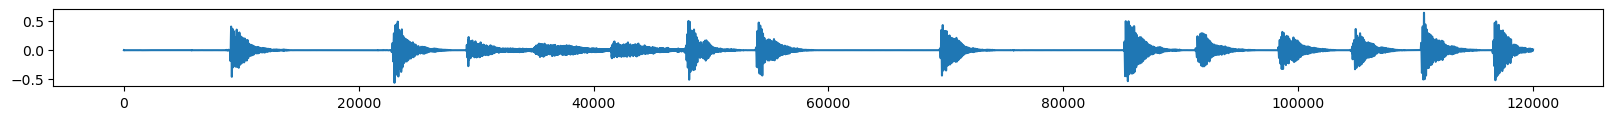

Finished epoch number 126 with a total of 10000 debug_seqs
 time: 2025-10-27 20:03:39.234448, epoch 127,  Loss: 0.2525
  Quantizer 0 Loss: 2.2043
  Quantizer 1 Loss: 3.1726
  Quantizer 2 Loss: 3.9180
  Quantizer 3 Loss: 4.3732
  Quantizer 4 Loss: 4.6827
  Quantizer 5 Loss: 4.8680
  Quantizer 6 Loss: 5.1017
  Quantizer 7 Loss: 5.2001
Latents embedded in 106 of the GRU input size of 128
Conditioning parameters embedded in 22 of the GRU input size of 128
DEVICE going in: model tensors cuda:0, enc_model cpu, c cuda:0
About toInitialize generator with c.shape = torch.Size([8])
params_seq.shape = torch.Size([10, 8])
plot the audio which has shape (120000,)


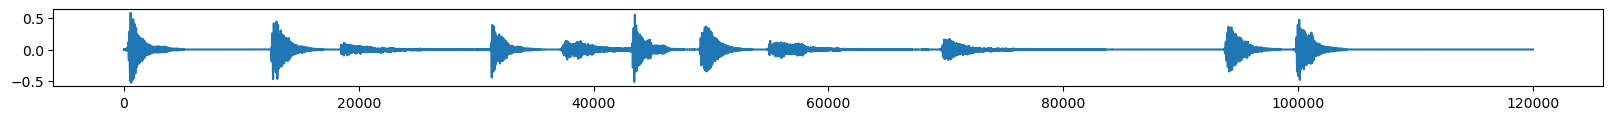

Finished epoch number 127 with a total of 10000 debug_seqs
 time: 2025-10-27 20:04:28.205778, epoch 128,  Loss: 0.2431
  Quantizer 0 Loss: 2.1952
  Quantizer 1 Loss: 3.1410
  Quantizer 2 Loss: 3.8853
  Quantizer 3 Loss: 4.3529
  Quantizer 4 Loss: 4.6497
  Quantizer 5 Loss: 4.8434
  Quantizer 6 Loss: 5.0744
  Quantizer 7 Loss: 5.1789
Latents embedded in 106 of the GRU input size of 128
Conditioning parameters embedded in 22 of the GRU input size of 128
DEVICE going in: model tensors cuda:0, enc_model cpu, c cuda:0
About toInitialize generator with c.shape = torch.Size([8])
params_seq.shape = torch.Size([10, 8])
plot the audio which has shape (120000,)


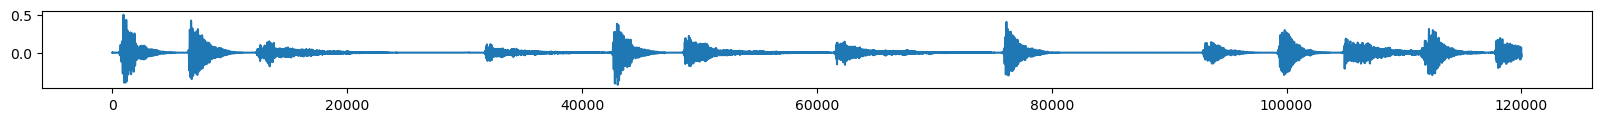

Finished epoch number 128 with a total of 10000 debug_seqs
 time: 2025-10-27 20:05:16.022788, epoch 129,  Loss: 0.2451
  Quantizer 0 Loss: 2.1929
  Quantizer 1 Loss: 3.1299
  Quantizer 2 Loss: 3.8768
  Quantizer 3 Loss: 4.3398
  Quantizer 4 Loss: 4.6488
  Quantizer 5 Loss: 4.8393
  Quantizer 6 Loss: 5.0694
  Quantizer 7 Loss: 5.1712
Latents embedded in 106 of the GRU input size of 128
Conditioning parameters embedded in 22 of the GRU input size of 128
DEVICE going in: model tensors cuda:0, enc_model cpu, c cuda:0
About toInitialize generator with c.shape = torch.Size([8])
params_seq.shape = torch.Size([10, 8])
plot the audio which has shape (120000,)


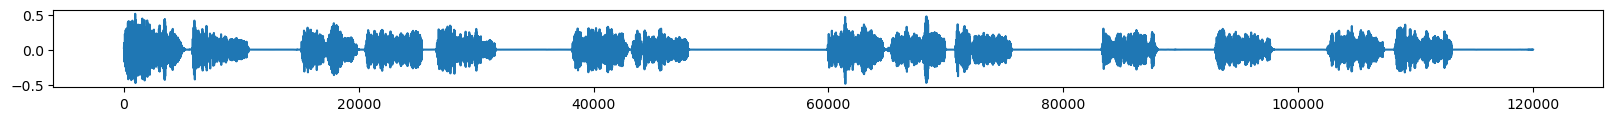

Finished epoch number 129 with a total of 10000 debug_seqs
 time: 2025-10-27 20:06:03.707089, epoch 130,  Loss: 0.2489
  Quantizer 0 Loss: 2.2011
  Quantizer 1 Loss: 3.1348
  Quantizer 2 Loss: 3.8858
  Quantizer 3 Loss: 4.3592
  Quantizer 4 Loss: 4.6643
  Quantizer 5 Loss: 4.8539
  Quantizer 6 Loss: 5.0813
  Quantizer 7 Loss: 5.1883
Latents embedded in 106 of the GRU input size of 128
Conditioning parameters embedded in 22 of the GRU input size of 128
DEVICE going in: model tensors cuda:0, enc_model cpu, c cuda:0
About toInitialize generator with c.shape = torch.Size([8])
params_seq.shape = torch.Size([10, 8])
plot the audio which has shape (120000,)


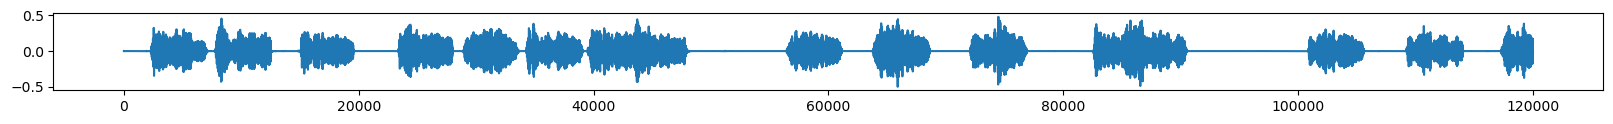

Finished epoch number 130 with a total of 10000 debug_seqs
 time: 2025-10-27 20:06:52.405734, epoch 131,  Loss: 0.2455
  Quantizer 0 Loss: 2.1731
  Quantizer 1 Loss: 3.0961
  Quantizer 2 Loss: 3.8467
  Quantizer 3 Loss: 4.3153
  Quantizer 4 Loss: 4.6226
  Quantizer 5 Loss: 4.8199
  Quantizer 6 Loss: 5.0487
  Quantizer 7 Loss: 5.1492
Latents embedded in 106 of the GRU input size of 128
Conditioning parameters embedded in 22 of the GRU input size of 128
DEVICE going in: model tensors cuda:0, enc_model cpu, c cuda:0
About toInitialize generator with c.shape = torch.Size([8])
params_seq.shape = torch.Size([10, 8])
plot the audio which has shape (120000,)


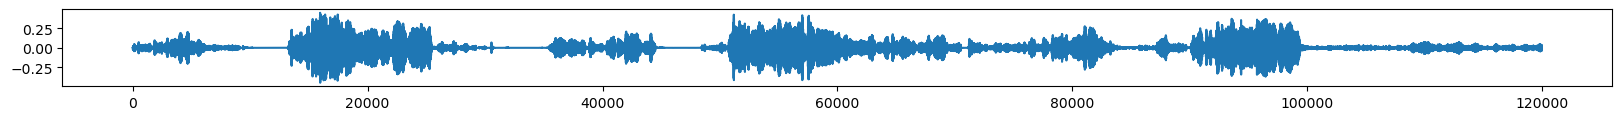

Finished epoch number 131 with a total of 10000 debug_seqs
 time: 2025-10-27 20:07:39.753873, epoch 132,  Loss: 0.2359
  Quantizer 0 Loss: 2.1839
  Quantizer 1 Loss: 3.1060
  Quantizer 2 Loss: 3.8634
  Quantizer 3 Loss: 4.3366
  Quantizer 4 Loss: 4.6416
  Quantizer 5 Loss: 4.8414
  Quantizer 6 Loss: 5.0689
  Quantizer 7 Loss: 5.1719
Latents embedded in 106 of the GRU input size of 128
Conditioning parameters embedded in 22 of the GRU input size of 128
DEVICE going in: model tensors cuda:0, enc_model cpu, c cuda:0
About toInitialize generator with c.shape = torch.Size([8])
params_seq.shape = torch.Size([10, 8])
plot the audio which has shape (120000,)


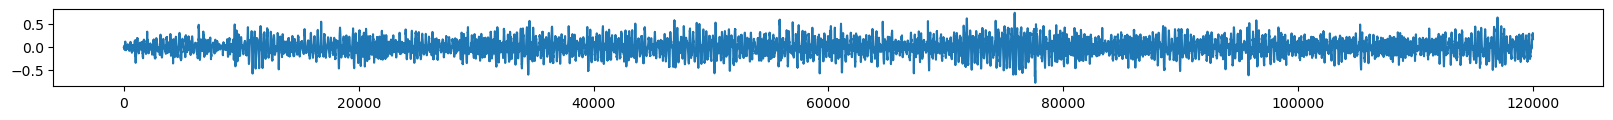

Finished epoch number 132 with a total of 10000 debug_seqs
 time: 2025-10-27 20:08:27.029921, epoch 133,  Loss: 0.2398
  Quantizer 0 Loss: 2.1878
  Quantizer 1 Loss: 3.1170
  Quantizer 2 Loss: 3.8678
  Quantizer 3 Loss: 4.3310
  Quantizer 4 Loss: 4.6434
  Quantizer 5 Loss: 4.8354
  Quantizer 6 Loss: 5.0686
  Quantizer 7 Loss: 5.1679
Latents embedded in 106 of the GRU input size of 128
Conditioning parameters embedded in 22 of the GRU input size of 128
DEVICE going in: model tensors cuda:0, enc_model cpu, c cuda:0
About toInitialize generator with c.shape = torch.Size([8])
params_seq.shape = torch.Size([10, 8])
plot the audio which has shape (120000,)


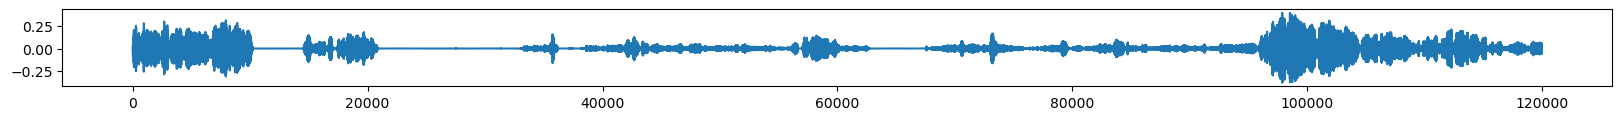

Finished epoch number 133 with a total of 10000 debug_seqs
 time: 2025-10-27 20:09:15.112752, epoch 134,  Loss: 0.2415
  Quantizer 0 Loss: 2.1679
  Quantizer 1 Loss: 3.0870
  Quantizer 2 Loss: 3.8383
  Quantizer 3 Loss: 4.3098
  Quantizer 4 Loss: 4.6211
  Quantizer 5 Loss: 4.8127
  Quantizer 6 Loss: 5.0441
  Quantizer 7 Loss: 5.1494
Latents embedded in 106 of the GRU input size of 128
Conditioning parameters embedded in 22 of the GRU input size of 128
DEVICE going in: model tensors cuda:0, enc_model cpu, c cuda:0
About toInitialize generator with c.shape = torch.Size([8])
params_seq.shape = torch.Size([10, 8])
plot the audio which has shape (120000,)


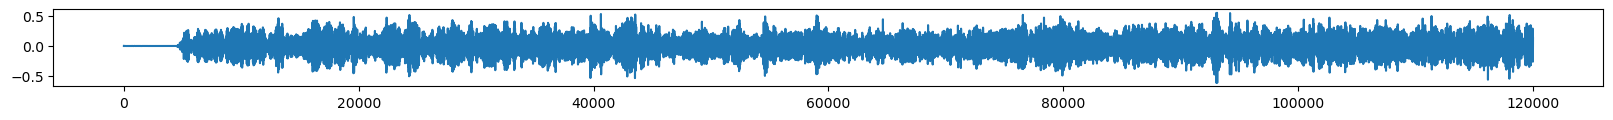

Finished epoch number 134 with a total of 10000 debug_seqs
 time: 2025-10-27 20:10:03.391631, epoch 135,  Loss: 0.2467
  Quantizer 0 Loss: 2.1740
  Quantizer 1 Loss: 3.0926
  Quantizer 2 Loss: 3.8411
  Quantizer 3 Loss: 4.3218
  Quantizer 4 Loss: 4.6290
  Quantizer 5 Loss: 4.8227
  Quantizer 6 Loss: 5.0554
  Quantizer 7 Loss: 5.1574
Latents embedded in 106 of the GRU input size of 128
Conditioning parameters embedded in 22 of the GRU input size of 128
DEVICE going in: model tensors cuda:0, enc_model cpu, c cuda:0
About toInitialize generator with c.shape = torch.Size([8])
params_seq.shape = torch.Size([10, 8])
plot the audio which has shape (120000,)


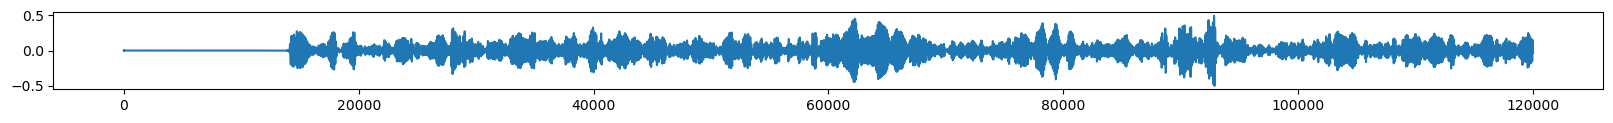

Finished epoch number 135 with a total of 10000 debug_seqs
 time: 2025-10-27 20:10:51.902343, epoch 136,  Loss: 0.2496
  Quantizer 0 Loss: 2.1853
  Quantizer 1 Loss: 3.1030
  Quantizer 2 Loss: 3.8552
  Quantizer 3 Loss: 4.3225
  Quantizer 4 Loss: 4.6320
  Quantizer 5 Loss: 4.8276
  Quantizer 6 Loss: 5.0583
  Quantizer 7 Loss: 5.1641
Latents embedded in 106 of the GRU input size of 128
Conditioning parameters embedded in 22 of the GRU input size of 128
DEVICE going in: model tensors cuda:0, enc_model cpu, c cuda:0
About toInitialize generator with c.shape = torch.Size([8])
params_seq.shape = torch.Size([10, 8])
plot the audio which has shape (120000,)


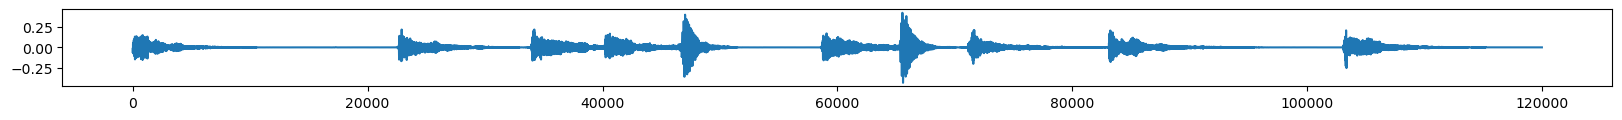

Finished epoch number 136 with a total of 10000 debug_seqs
 time: 2025-10-27 20:11:40.328461, epoch 137,  Loss: 0.2423
  Quantizer 0 Loss: 2.1757
  Quantizer 1 Loss: 3.0916
  Quantizer 2 Loss: 3.8472
  Quantizer 3 Loss: 4.3212
  Quantizer 4 Loss: 4.6361
  Quantizer 5 Loss: 4.8244
  Quantizer 6 Loss: 5.0590
  Quantizer 7 Loss: 5.1627
Latents embedded in 106 of the GRU input size of 128
Conditioning parameters embedded in 22 of the GRU input size of 128
DEVICE going in: model tensors cuda:0, enc_model cpu, c cuda:0
About toInitialize generator with c.shape = torch.Size([8])
params_seq.shape = torch.Size([10, 8])
plot the audio which has shape (120000,)


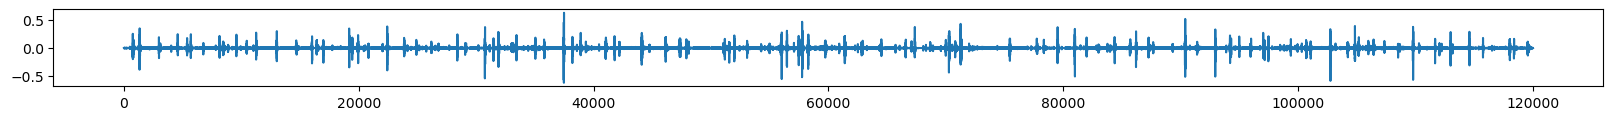

Finished epoch number 137 with a total of 10000 debug_seqs
 time: 2025-10-27 20:12:28.340527, epoch 138,  Loss: 0.2473
  Quantizer 0 Loss: 2.1770
  Quantizer 1 Loss: 3.0921
  Quantizer 2 Loss: 3.8480
  Quantizer 3 Loss: 4.3170
  Quantizer 4 Loss: 4.6309
  Quantizer 5 Loss: 4.8252
  Quantizer 6 Loss: 5.0548
  Quantizer 7 Loss: 5.1591
Latents embedded in 106 of the GRU input size of 128
Conditioning parameters embedded in 22 of the GRU input size of 128
DEVICE going in: model tensors cuda:0, enc_model cpu, c cuda:0
About toInitialize generator with c.shape = torch.Size([8])
params_seq.shape = torch.Size([10, 8])
plot the audio which has shape (120000,)


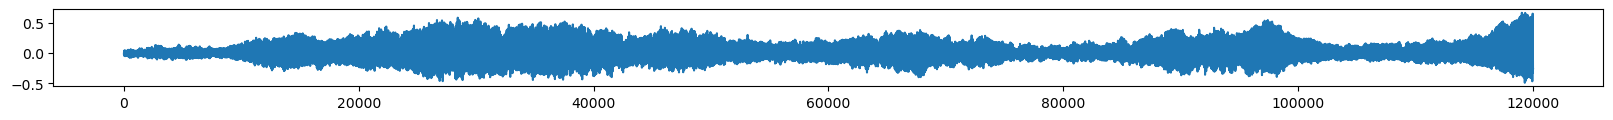

Finished epoch number 138 with a total of 10000 debug_seqs
 time: 2025-10-27 20:13:17.512820, epoch 139,  Loss: 0.2401
  Quantizer 0 Loss: 2.1788
  Quantizer 1 Loss: 3.0961
  Quantizer 2 Loss: 3.8460
  Quantizer 3 Loss: 4.3144
  Quantizer 4 Loss: 4.6192
  Quantizer 5 Loss: 4.8172
  Quantizer 6 Loss: 5.0428
  Quantizer 7 Loss: 5.1503
Latents embedded in 106 of the GRU input size of 128
Conditioning parameters embedded in 22 of the GRU input size of 128
DEVICE going in: model tensors cuda:0, enc_model cpu, c cuda:0
About toInitialize generator with c.shape = torch.Size([8])
params_seq.shape = torch.Size([10, 8])
plot the audio which has shape (120000,)


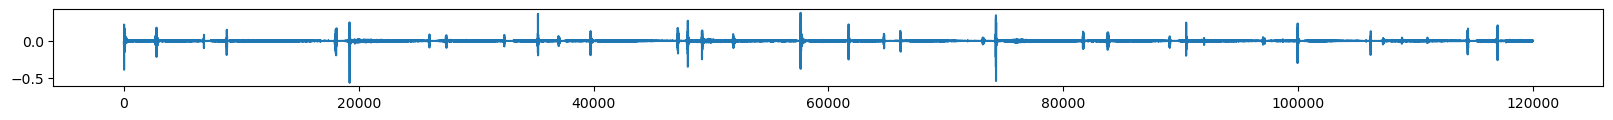

Finished epoch number 139 with a total of 10000 debug_seqs
 time: 2025-10-27 20:14:06.122595, epoch 140,  Loss: 0.2421
  Quantizer 0 Loss: 2.1750
  Quantizer 1 Loss: 3.0911
  Quantizer 2 Loss: 3.8409
  Quantizer 3 Loss: 4.3089
  Quantizer 4 Loss: 4.6192
  Quantizer 5 Loss: 4.8142
  Quantizer 6 Loss: 5.0442
  Quantizer 7 Loss: 5.1495
Latents embedded in 106 of the GRU input size of 128
Conditioning parameters embedded in 22 of the GRU input size of 128
DEVICE going in: model tensors cuda:0, enc_model cpu, c cuda:0
About toInitialize generator with c.shape = torch.Size([8])
params_seq.shape = torch.Size([10, 8])
plot the audio which has shape (120000,)


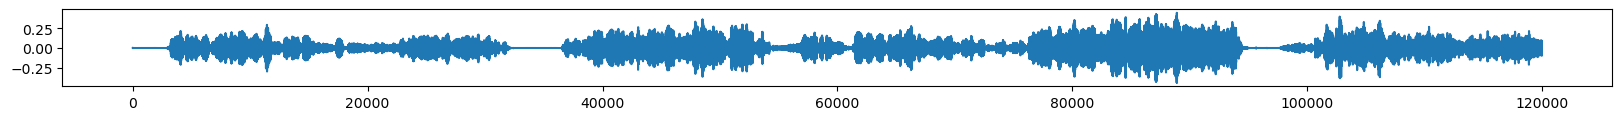

Finished epoch number 140 with a total of 10000 debug_seqs
 time: 2025-10-27 20:14:53.357823, epoch 141,  Loss: 0.2544
  Quantizer 0 Loss: 2.1755
  Quantizer 1 Loss: 3.0889
  Quantizer 2 Loss: 3.8400
  Quantizer 3 Loss: 4.3133
  Quantizer 4 Loss: 4.6229
  Quantizer 5 Loss: 4.8190
  Quantizer 6 Loss: 5.0448
  Quantizer 7 Loss: 5.1502
Latents embedded in 106 of the GRU input size of 128
Conditioning parameters embedded in 22 of the GRU input size of 128
DEVICE going in: model tensors cuda:0, enc_model cpu, c cuda:0
About toInitialize generator with c.shape = torch.Size([8])
params_seq.shape = torch.Size([10, 8])
plot the audio which has shape (120000,)


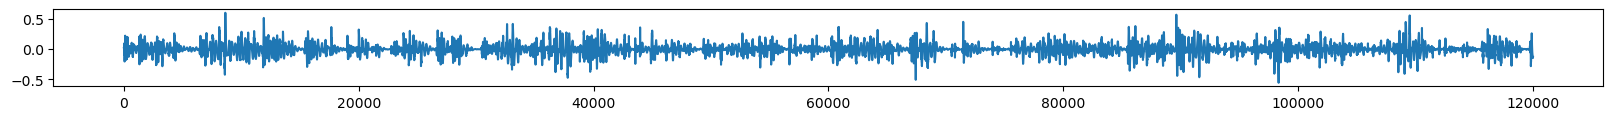

Finished epoch number 141 with a total of 10000 debug_seqs
 time: 2025-10-27 20:15:42.382409, epoch 142,  Loss: 0.2436
  Quantizer 0 Loss: 2.1529
  Quantizer 1 Loss: 3.0642
  Quantizer 2 Loss: 3.8160
  Quantizer 3 Loss: 4.2896
  Quantizer 4 Loss: 4.6029
  Quantizer 5 Loss: 4.7995
  Quantizer 6 Loss: 5.0237
  Quantizer 7 Loss: 5.1299
Latents embedded in 106 of the GRU input size of 128
Conditioning parameters embedded in 22 of the GRU input size of 128
DEVICE going in: model tensors cuda:0, enc_model cpu, c cuda:0
About toInitialize generator with c.shape = torch.Size([8])
params_seq.shape = torch.Size([10, 8])
plot the audio which has shape (120000,)


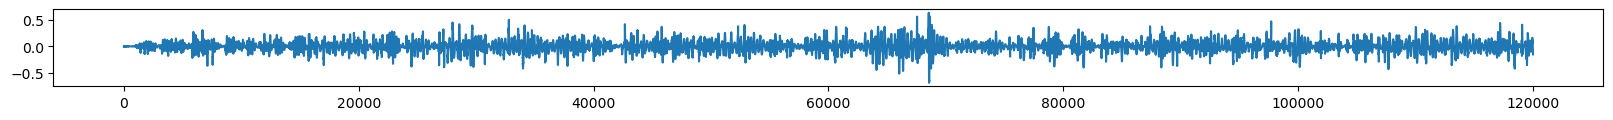

Finished epoch number 142 with a total of 10000 debug_seqs
 time: 2025-10-27 20:16:30.463521, epoch 143,  Loss: 0.2426
  Quantizer 0 Loss: 2.1675
  Quantizer 1 Loss: 3.0783
  Quantizer 2 Loss: 3.8338
  Quantizer 3 Loss: 4.2998
  Quantizer 4 Loss: 4.6132
  Quantizer 5 Loss: 4.8046
  Quantizer 6 Loss: 5.0386
  Quantizer 7 Loss: 5.1451
Latents embedded in 106 of the GRU input size of 128
Conditioning parameters embedded in 22 of the GRU input size of 128
DEVICE going in: model tensors cuda:0, enc_model cpu, c cuda:0
About toInitialize generator with c.shape = torch.Size([8])
params_seq.shape = torch.Size([10, 8])
plot the audio which has shape (120000,)


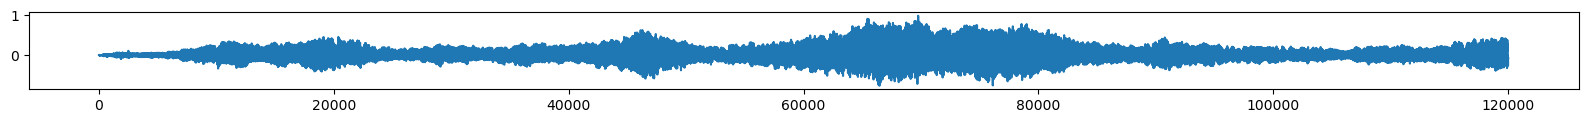

Finished epoch number 143 with a total of 10000 debug_seqs
 time: 2025-10-27 20:17:19.119998, epoch 144,  Loss: 0.2473
  Quantizer 0 Loss: 2.1627
  Quantizer 1 Loss: 3.0731
  Quantizer 2 Loss: 3.8249
  Quantizer 3 Loss: 4.2973
  Quantizer 4 Loss: 4.6039
  Quantizer 5 Loss: 4.8030
  Quantizer 6 Loss: 5.0276
  Quantizer 7 Loss: 5.1356
Latents embedded in 106 of the GRU input size of 128
Conditioning parameters embedded in 22 of the GRU input size of 128
DEVICE going in: model tensors cuda:0, enc_model cpu, c cuda:0
About toInitialize generator with c.shape = torch.Size([8])
params_seq.shape = torch.Size([10, 8])
plot the audio which has shape (120000,)


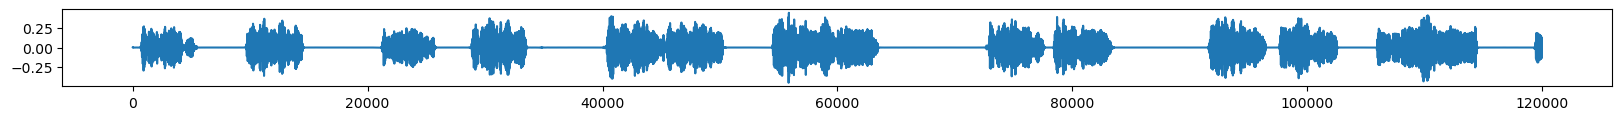

Finished epoch number 144 with a total of 10000 debug_seqs
 time: 2025-10-27 20:18:06.734799, epoch 145,  Loss: 0.2401
  Quantizer 0 Loss: 2.1708
  Quantizer 1 Loss: 3.0846
  Quantizer 2 Loss: 3.8354
  Quantizer 3 Loss: 4.3066
  Quantizer 4 Loss: 4.6167
  Quantizer 5 Loss: 4.8106
  Quantizer 6 Loss: 5.0461
  Quantizer 7 Loss: 5.1453
Latents embedded in 106 of the GRU input size of 128
Conditioning parameters embedded in 22 of the GRU input size of 128
DEVICE going in: model tensors cuda:0, enc_model cpu, c cuda:0
About toInitialize generator with c.shape = torch.Size([8])
params_seq.shape = torch.Size([10, 8])
plot the audio which has shape (120000,)


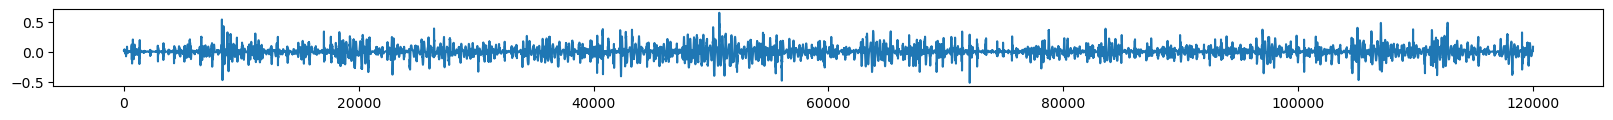

Finished epoch number 145 with a total of 10000 debug_seqs
 time: 2025-10-27 20:18:55.334044, epoch 146,  Loss: 0.2500
  Quantizer 0 Loss: 2.1831
  Quantizer 1 Loss: 3.1011
  Quantizer 2 Loss: 3.8462
  Quantizer 3 Loss: 4.3188
  Quantizer 4 Loss: 4.6296
  Quantizer 5 Loss: 4.8199
  Quantizer 6 Loss: 5.0530
  Quantizer 7 Loss: 5.1548
Latents embedded in 106 of the GRU input size of 128
Conditioning parameters embedded in 22 of the GRU input size of 128
DEVICE going in: model tensors cuda:0, enc_model cpu, c cuda:0
About toInitialize generator with c.shape = torch.Size([8])
params_seq.shape = torch.Size([10, 8])
plot the audio which has shape (120000,)


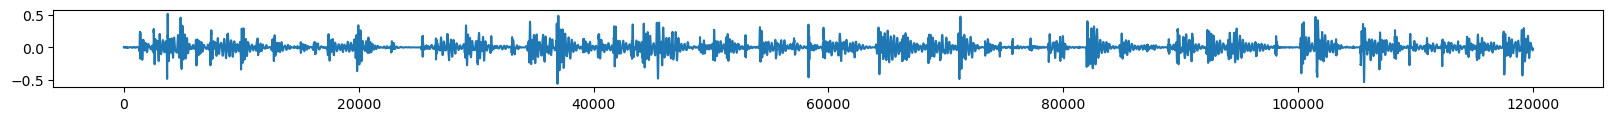

Finished epoch number 146 with a total of 10000 debug_seqs
 time: 2025-10-27 20:19:42.937040, epoch 147,  Loss: 0.2432
  Quantizer 0 Loss: 2.1698
  Quantizer 1 Loss: 3.0817
  Quantizer 2 Loss: 3.8371
  Quantizer 3 Loss: 4.3071
  Quantizer 4 Loss: 4.6142
  Quantizer 5 Loss: 4.8096
  Quantizer 6 Loss: 5.0413
  Quantizer 7 Loss: 5.1455
Latents embedded in 106 of the GRU input size of 128
Conditioning parameters embedded in 22 of the GRU input size of 128
DEVICE going in: model tensors cuda:0, enc_model cpu, c cuda:0
About toInitialize generator with c.shape = torch.Size([8])
params_seq.shape = torch.Size([10, 8])
plot the audio which has shape (120000,)


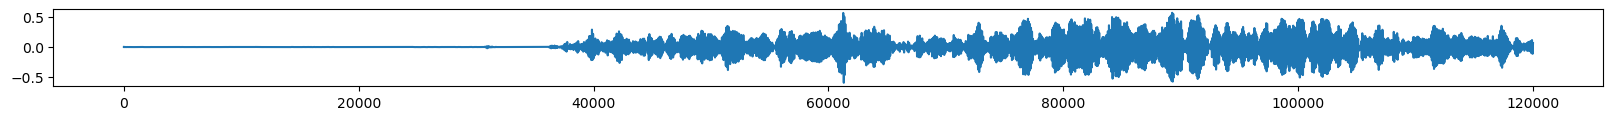

Finished epoch number 147 with a total of 10000 debug_seqs
 time: 2025-10-27 20:20:30.845886, epoch 148,  Loss: 0.2399
  Quantizer 0 Loss: 2.1672
  Quantizer 1 Loss: 3.0769
  Quantizer 2 Loss: 3.8323
  Quantizer 3 Loss: 4.3013
  Quantizer 4 Loss: 4.6161
  Quantizer 5 Loss: 4.8117
  Quantizer 6 Loss: 5.0434
  Quantizer 7 Loss: 5.1438
Latents embedded in 106 of the GRU input size of 128
Conditioning parameters embedded in 22 of the GRU input size of 128
DEVICE going in: model tensors cuda:0, enc_model cpu, c cuda:0
About toInitialize generator with c.shape = torch.Size([8])
params_seq.shape = torch.Size([10, 8])
plot the audio which has shape (120000,)


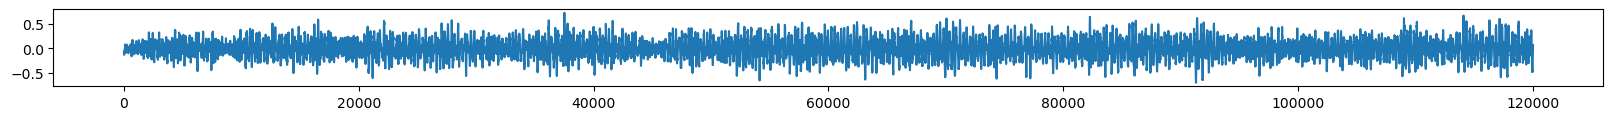

Finished epoch number 148 with a total of 10000 debug_seqs
 time: 2025-10-27 20:21:18.377877, epoch 149,  Loss: 0.2518
  Quantizer 0 Loss: 2.1827
  Quantizer 1 Loss: 3.0932
  Quantizer 2 Loss: 3.8526
  Quantizer 3 Loss: 4.3217
  Quantizer 4 Loss: 4.6294
  Quantizer 5 Loss: 4.8222
  Quantizer 6 Loss: 5.0540
  Quantizer 7 Loss: 5.1557
Latents embedded in 106 of the GRU input size of 128
Conditioning parameters embedded in 22 of the GRU input size of 128
DEVICE going in: model tensors cuda:0, enc_model cpu, c cuda:0
About toInitialize generator with c.shape = torch.Size([8])
params_seq.shape = torch.Size([10, 8])
plot the audio which has shape (120000,)


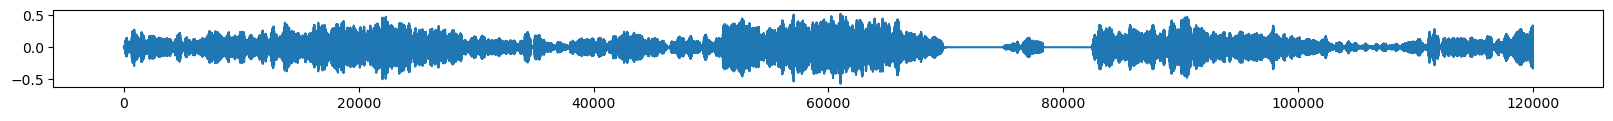

Finished epoch number 149 with a total of 10000 debug_seqs
 time: 2025-10-27 20:22:06.065336, epoch 150,  Loss: 0.2510
  Quantizer 0 Loss: 2.1653
  Quantizer 1 Loss: 3.0705
  Quantizer 2 Loss: 3.8208
  Quantizer 3 Loss: 4.2919
  Quantizer 4 Loss: 4.6000
  Quantizer 5 Loss: 4.7983
  Quantizer 6 Loss: 5.0238
  Quantizer 7 Loss: 5.1283
Latents embedded in 106 of the GRU input size of 128
Conditioning parameters embedded in 22 of the GRU input size of 128
DEVICE going in: model tensors cuda:0, enc_model cpu, c cuda:0
About toInitialize generator with c.shape = torch.Size([8])
params_seq.shape = torch.Size([10, 8])
plot the audio which has shape (120000,)


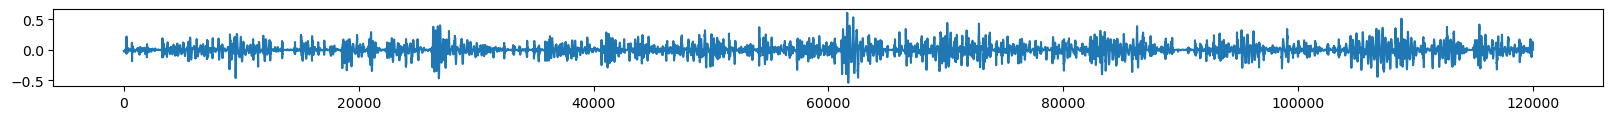

Saved checkpoint at epoch 150
Finished epoch number 150 with a total of 10000 debug_seqs
 time: 2025-10-27 20:22:52.781228, epoch 151,  Loss: 0.2130
  Quantizer 0 Loss: 2.1589
  Quantizer 1 Loss: 2.7139
  Quantizer 2 Loss: 3.4054
  Quantizer 3 Loss: 3.8699
  Quantizer 4 Loss: 4.1976
  Quantizer 5 Loss: 4.4060
  Quantizer 6 Loss: 4.6611
  Quantizer 7 Loss: 4.7915
Latents embedded in 106 of the GRU input size of 128
Conditioning parameters embedded in 22 of the GRU input size of 128
DEVICE going in: model tensors cuda:0, enc_model cpu, c cuda:0
About toInitialize generator with c.shape = torch.Size([8])
params_seq.shape = torch.Size([10, 8])
plot the audio which has shape (120000,)


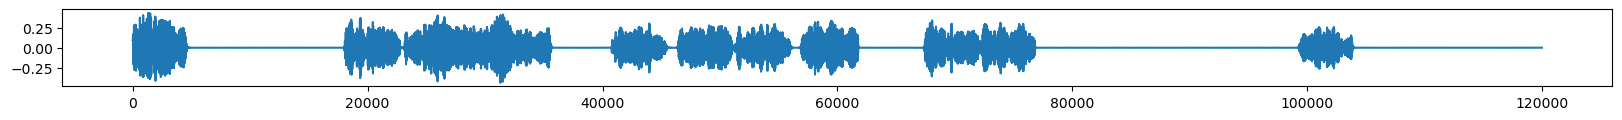

Finished epoch number 151 with a total of 10000 debug_seqs
 time: 2025-10-27 20:23:40.315242, epoch 152,  Loss: 0.2209
  Quantizer 0 Loss: 2.1643
  Quantizer 1 Loss: 2.6859
  Quantizer 2 Loss: 3.3614
  Quantizer 3 Loss: 3.8226
  Quantizer 4 Loss: 4.1451
  Quantizer 5 Loss: 4.3501
  Quantizer 6 Loss: 4.6025
  Quantizer 7 Loss: 4.7352
Latents embedded in 106 of the GRU input size of 128
Conditioning parameters embedded in 22 of the GRU input size of 128
DEVICE going in: model tensors cuda:0, enc_model cpu, c cuda:0
About toInitialize generator with c.shape = torch.Size([8])
params_seq.shape = torch.Size([10, 8])
plot the audio which has shape (120000,)


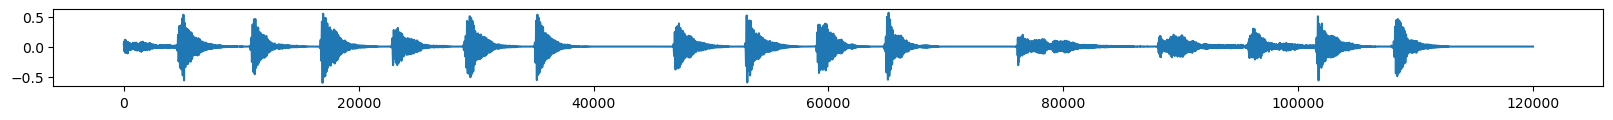

Finished epoch number 152 with a total of 10000 debug_seqs
 time: 2025-10-27 20:24:27.619808, epoch 153,  Loss: 0.2158
  Quantizer 0 Loss: 2.1587
  Quantizer 1 Loss: 2.6695
  Quantizer 2 Loss: 3.3350
  Quantizer 3 Loss: 3.7950
  Quantizer 4 Loss: 4.1181
  Quantizer 5 Loss: 4.3264
  Quantizer 6 Loss: 4.5748
  Quantizer 7 Loss: 4.7038
Latents embedded in 106 of the GRU input size of 128
Conditioning parameters embedded in 22 of the GRU input size of 128
DEVICE going in: model tensors cuda:0, enc_model cpu, c cuda:0
About toInitialize generator with c.shape = torch.Size([8])
params_seq.shape = torch.Size([10, 8])
plot the audio which has shape (120000,)


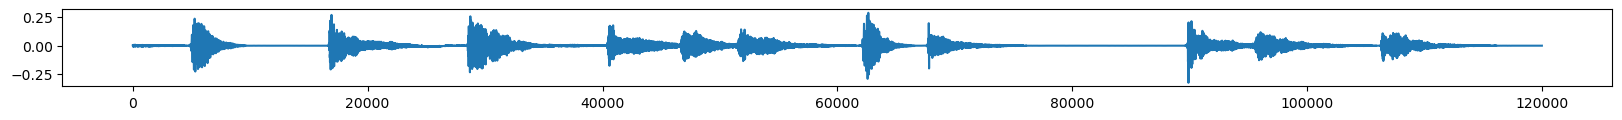

Finished epoch number 153 with a total of 10000 debug_seqs
 time: 2025-10-27 20:25:14.940483, epoch 154,  Loss: 0.2157
  Quantizer 0 Loss: 2.1548
  Quantizer 1 Loss: 2.6538
  Quantizer 2 Loss: 3.3210
  Quantizer 3 Loss: 3.7778
  Quantizer 4 Loss: 4.0961
  Quantizer 5 Loss: 4.3060
  Quantizer 6 Loss: 4.5549
  Quantizer 7 Loss: 4.6823
Latents embedded in 106 of the GRU input size of 128
Conditioning parameters embedded in 22 of the GRU input size of 128
DEVICE going in: model tensors cuda:0, enc_model cpu, c cuda:0
About toInitialize generator with c.shape = torch.Size([8])
params_seq.shape = torch.Size([10, 8])
plot the audio which has shape (120000,)


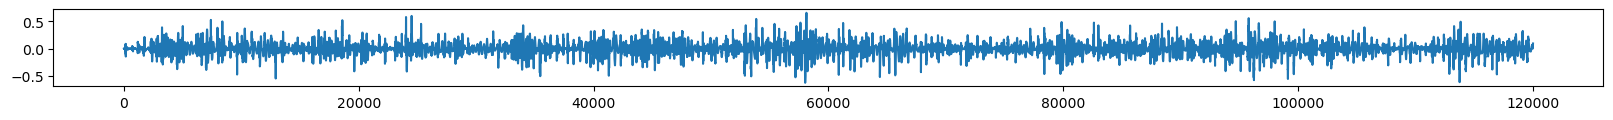

Finished epoch number 154 with a total of 10000 debug_seqs
 time: 2025-10-27 20:26:02.269979, epoch 155,  Loss: 0.2185
  Quantizer 0 Loss: 2.1569
  Quantizer 1 Loss: 2.6527
  Quantizer 2 Loss: 3.3171
  Quantizer 3 Loss: 3.7754
  Quantizer 4 Loss: 4.0952
  Quantizer 5 Loss: 4.2997
  Quantizer 6 Loss: 4.5471
  Quantizer 7 Loss: 4.6835
Latents embedded in 106 of the GRU input size of 128
Conditioning parameters embedded in 22 of the GRU input size of 128
DEVICE going in: model tensors cuda:0, enc_model cpu, c cuda:0
About toInitialize generator with c.shape = torch.Size([8])
params_seq.shape = torch.Size([10, 8])
plot the audio which has shape (120000,)


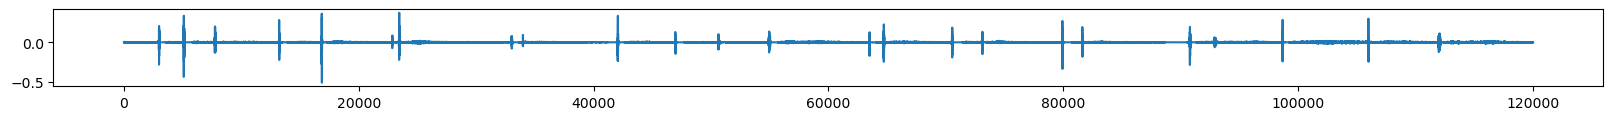

Finished epoch number 155 with a total of 10000 debug_seqs
 time: 2025-10-27 20:26:49.479270, epoch 156,  Loss: 0.2157
  Quantizer 0 Loss: 2.1567
  Quantizer 1 Loss: 2.6576
  Quantizer 2 Loss: 3.3187
  Quantizer 3 Loss: 3.7717
  Quantizer 4 Loss: 4.0948
  Quantizer 5 Loss: 4.2977
  Quantizer 6 Loss: 4.5423
  Quantizer 7 Loss: 4.6769
Latents embedded in 106 of the GRU input size of 128
Conditioning parameters embedded in 22 of the GRU input size of 128
DEVICE going in: model tensors cuda:0, enc_model cpu, c cuda:0
About toInitialize generator with c.shape = torch.Size([8])
params_seq.shape = torch.Size([10, 8])
plot the audio which has shape (120000,)


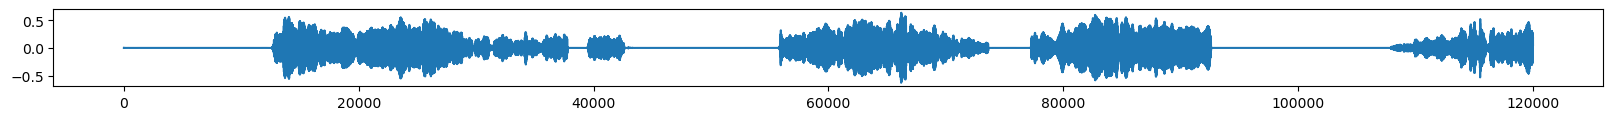

Finished epoch number 156 with a total of 10000 debug_seqs
 time: 2025-10-27 20:27:36.250681, epoch 157,  Loss: 0.2198
  Quantizer 0 Loss: 2.1389
  Quantizer 1 Loss: 2.6443
  Quantizer 2 Loss: 3.2970
  Quantizer 3 Loss: 3.7588
  Quantizer 4 Loss: 4.0790
  Quantizer 5 Loss: 4.2864
  Quantizer 6 Loss: 4.5320
  Quantizer 7 Loss: 4.6644
Latents embedded in 106 of the GRU input size of 128
Conditioning parameters embedded in 22 of the GRU input size of 128
DEVICE going in: model tensors cuda:0, enc_model cpu, c cuda:0
About toInitialize generator with c.shape = torch.Size([8])
params_seq.shape = torch.Size([10, 8])
plot the audio which has shape (120000,)


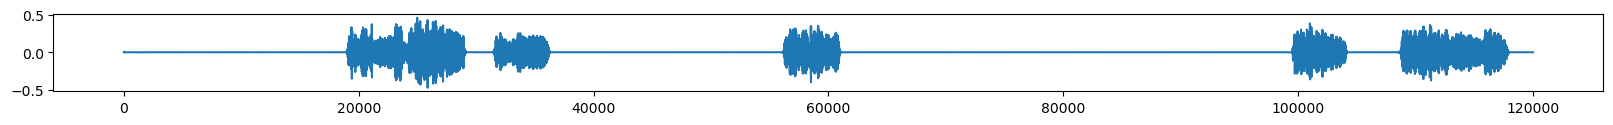

Finished epoch number 157 with a total of 10000 debug_seqs
 time: 2025-10-27 20:28:23.529134, epoch 158,  Loss: 0.2196
  Quantizer 0 Loss: 2.1438
  Quantizer 1 Loss: 2.6459
  Quantizer 2 Loss: 3.3004
  Quantizer 3 Loss: 3.7579
  Quantizer 4 Loss: 4.0725
  Quantizer 5 Loss: 4.2819
  Quantizer 6 Loss: 4.5271
  Quantizer 7 Loss: 4.6605
Latents embedded in 106 of the GRU input size of 128
Conditioning parameters embedded in 22 of the GRU input size of 128
DEVICE going in: model tensors cuda:0, enc_model cpu, c cuda:0
About toInitialize generator with c.shape = torch.Size([8])
params_seq.shape = torch.Size([10, 8])
plot the audio which has shape (120000,)


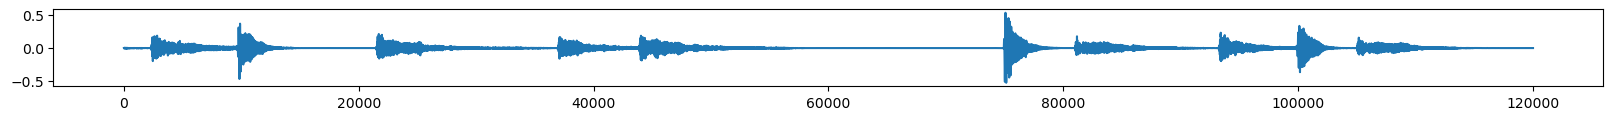

Finished epoch number 158 with a total of 10000 debug_seqs
 time: 2025-10-27 20:29:10.214940, epoch 159,  Loss: 0.2214
  Quantizer 0 Loss: 2.1630
  Quantizer 1 Loss: 2.6666
  Quantizer 2 Loss: 3.3233
  Quantizer 3 Loss: 3.7780
  Quantizer 4 Loss: 4.0948
  Quantizer 5 Loss: 4.2984
  Quantizer 6 Loss: 4.5469
  Quantizer 7 Loss: 4.6791
Latents embedded in 106 of the GRU input size of 128
Conditioning parameters embedded in 22 of the GRU input size of 128
DEVICE going in: model tensors cuda:0, enc_model cpu, c cuda:0
About toInitialize generator with c.shape = torch.Size([8])
params_seq.shape = torch.Size([10, 8])
plot the audio which has shape (120000,)


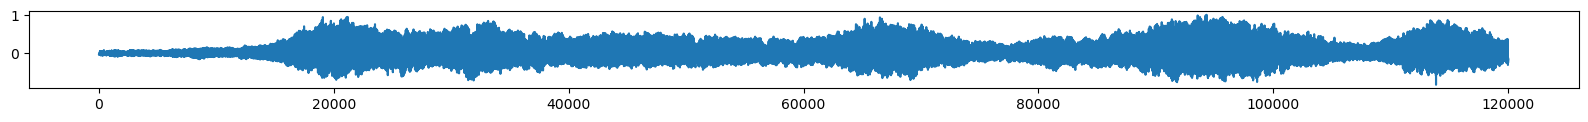

Finished epoch number 159 with a total of 10000 debug_seqs
 time: 2025-10-27 20:29:57.541720, epoch 160,  Loss: 0.2200
  Quantizer 0 Loss: 2.1519
  Quantizer 1 Loss: 2.6493
  Quantizer 2 Loss: 3.3020
  Quantizer 3 Loss: 3.7629
  Quantizer 4 Loss: 4.0826
  Quantizer 5 Loss: 4.2861
  Quantizer 6 Loss: 4.5290
  Quantizer 7 Loss: 4.6584
Latents embedded in 106 of the GRU input size of 128
Conditioning parameters embedded in 22 of the GRU input size of 128
DEVICE going in: model tensors cuda:0, enc_model cpu, c cuda:0
About toInitialize generator with c.shape = torch.Size([8])
params_seq.shape = torch.Size([10, 8])
plot the audio which has shape (120000,)


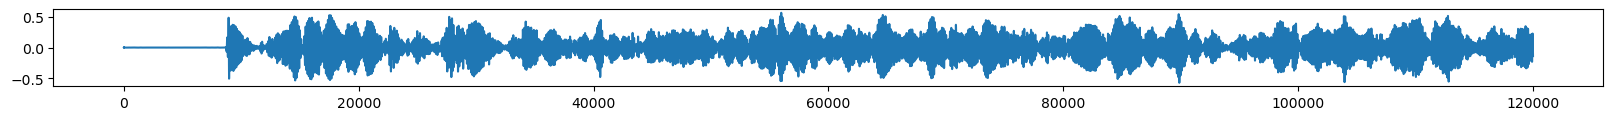

Finished epoch number 160 with a total of 10000 debug_seqs
 time: 2025-10-27 20:30:44.140256, epoch 161,  Loss: 0.2188
  Quantizer 0 Loss: 2.1549
  Quantizer 1 Loss: 2.6595
  Quantizer 2 Loss: 3.3055
  Quantizer 3 Loss: 3.7669
  Quantizer 4 Loss: 4.0796
  Quantizer 5 Loss: 4.2928
  Quantizer 6 Loss: 4.5367
  Quantizer 7 Loss: 4.6697
Latents embedded in 106 of the GRU input size of 128
Conditioning parameters embedded in 22 of the GRU input size of 128
DEVICE going in: model tensors cuda:0, enc_model cpu, c cuda:0
About toInitialize generator with c.shape = torch.Size([8])
params_seq.shape = torch.Size([10, 8])
plot the audio which has shape (120000,)


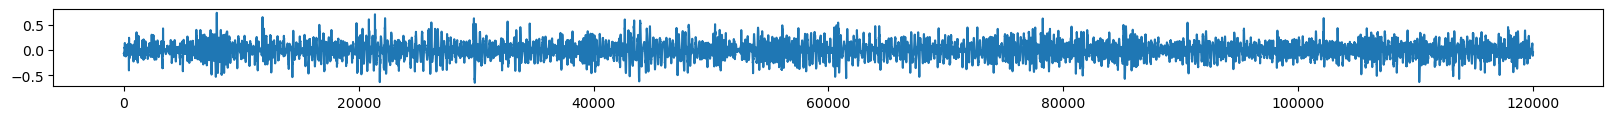

Finished epoch number 161 with a total of 10000 debug_seqs
 time: 2025-10-27 20:31:31.075088, epoch 162,  Loss: 0.2236
  Quantizer 0 Loss: 2.1562
  Quantizer 1 Loss: 2.6586
  Quantizer 2 Loss: 3.3124
  Quantizer 3 Loss: 3.7637
  Quantizer 4 Loss: 4.0753
  Quantizer 5 Loss: 4.2855
  Quantizer 6 Loss: 4.5278
  Quantizer 7 Loss: 4.6628
Latents embedded in 106 of the GRU input size of 128
Conditioning parameters embedded in 22 of the GRU input size of 128
DEVICE going in: model tensors cuda:0, enc_model cpu, c cuda:0
About toInitialize generator with c.shape = torch.Size([8])
params_seq.shape = torch.Size([10, 8])
plot the audio which has shape (120000,)


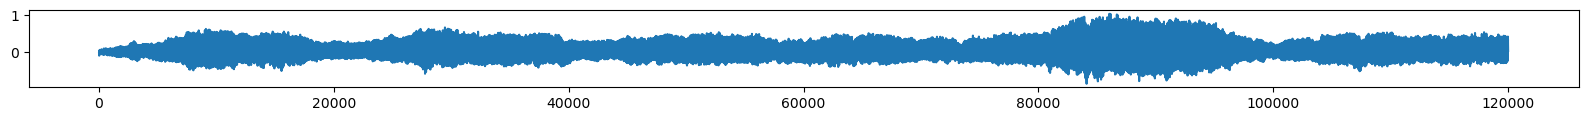

Finished epoch number 162 with a total of 10000 debug_seqs
 time: 2025-10-27 20:32:17.492843, epoch 163,  Loss: 0.2091
  Quantizer 0 Loss: 2.1492
  Quantizer 1 Loss: 2.6461
  Quantizer 2 Loss: 3.3043
  Quantizer 3 Loss: 3.7594
  Quantizer 4 Loss: 4.0759
  Quantizer 5 Loss: 4.2826
  Quantizer 6 Loss: 4.5299
  Quantizer 7 Loss: 4.6628
Latents embedded in 106 of the GRU input size of 128
Conditioning parameters embedded in 22 of the GRU input size of 128
DEVICE going in: model tensors cuda:0, enc_model cpu, c cuda:0
About toInitialize generator with c.shape = torch.Size([8])
params_seq.shape = torch.Size([10, 8])
plot the audio which has shape (120000,)


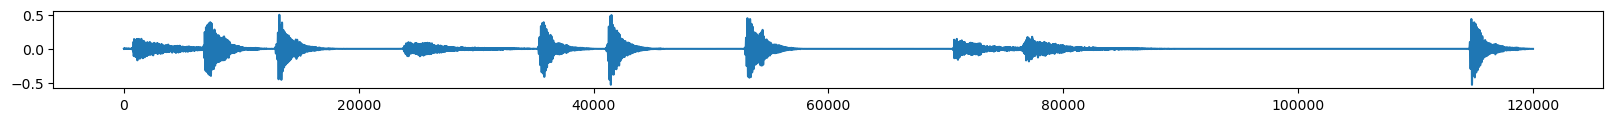

Finished epoch number 163 with a total of 10000 debug_seqs
 time: 2025-10-27 20:33:04.785055, epoch 164,  Loss: 0.2116
  Quantizer 0 Loss: 2.1654
  Quantizer 1 Loss: 2.6570
  Quantizer 2 Loss: 3.3154
  Quantizer 3 Loss: 3.7671
  Quantizer 4 Loss: 4.0871
  Quantizer 5 Loss: 4.2901
  Quantizer 6 Loss: 4.5340
  Quantizer 7 Loss: 4.6684
Latents embedded in 106 of the GRU input size of 128
Conditioning parameters embedded in 22 of the GRU input size of 128
DEVICE going in: model tensors cuda:0, enc_model cpu, c cuda:0
About toInitialize generator with c.shape = torch.Size([8])
params_seq.shape = torch.Size([10, 8])
plot the audio which has shape (120000,)


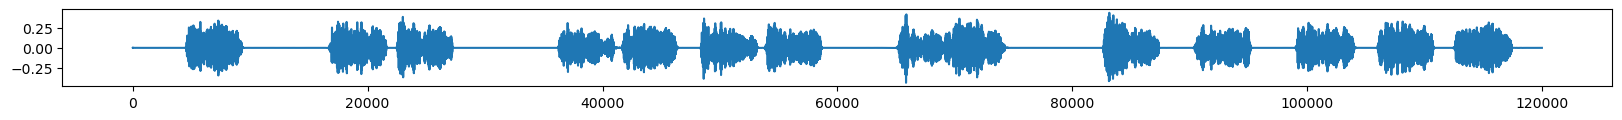

Finished epoch number 164 with a total of 10000 debug_seqs
 time: 2025-10-27 20:33:51.397824, epoch 165,  Loss: 0.2133
  Quantizer 0 Loss: 2.1675
  Quantizer 1 Loss: 2.6588
  Quantizer 2 Loss: 3.3182
  Quantizer 3 Loss: 3.7675
  Quantizer 4 Loss: 4.0803
  Quantizer 5 Loss: 4.2895
  Quantizer 6 Loss: 4.5313
  Quantizer 7 Loss: 4.6591
Latents embedded in 106 of the GRU input size of 128
Conditioning parameters embedded in 22 of the GRU input size of 128
DEVICE going in: model tensors cuda:0, enc_model cpu, c cuda:0
About toInitialize generator with c.shape = torch.Size([8])
params_seq.shape = torch.Size([10, 8])
plot the audio which has shape (120000,)


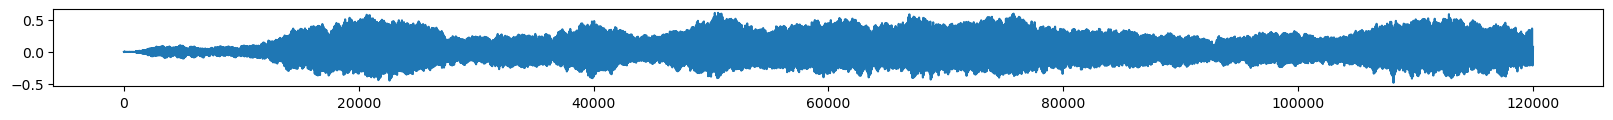

Finished epoch number 165 with a total of 10000 debug_seqs
 time: 2025-10-27 20:34:38.592240, epoch 166,  Loss: 0.2260
  Quantizer 0 Loss: 2.1593
  Quantizer 1 Loss: 2.6628
  Quantizer 2 Loss: 3.3160
  Quantizer 3 Loss: 3.7707
  Quantizer 4 Loss: 4.0930
  Quantizer 5 Loss: 4.2997
  Quantizer 6 Loss: 4.5491
  Quantizer 7 Loss: 4.6801
Latents embedded in 106 of the GRU input size of 128
Conditioning parameters embedded in 22 of the GRU input size of 128
DEVICE going in: model tensors cuda:0, enc_model cpu, c cuda:0
About toInitialize generator with c.shape = torch.Size([8])
params_seq.shape = torch.Size([10, 8])
plot the audio which has shape (120000,)


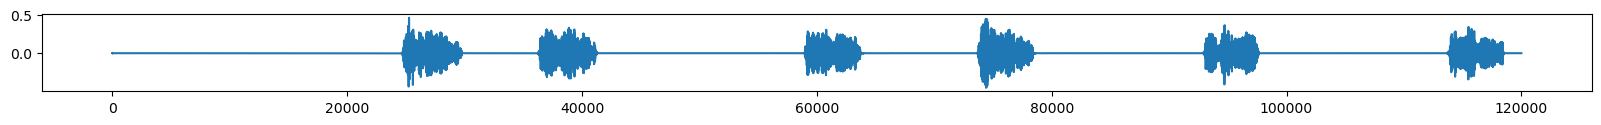

Finished epoch number 166 with a total of 10000 debug_seqs
 time: 2025-10-27 20:35:25.320068, epoch 167,  Loss: 0.2167
  Quantizer 0 Loss: 2.1639
  Quantizer 1 Loss: 2.6608
  Quantizer 2 Loss: 3.3125
  Quantizer 3 Loss: 3.7662
  Quantizer 4 Loss: 4.0821
  Quantizer 5 Loss: 4.2857
  Quantizer 6 Loss: 4.5329
  Quantizer 7 Loss: 4.6636
Latents embedded in 106 of the GRU input size of 128
Conditioning parameters embedded in 22 of the GRU input size of 128
DEVICE going in: model tensors cuda:0, enc_model cpu, c cuda:0
About toInitialize generator with c.shape = torch.Size([8])
params_seq.shape = torch.Size([10, 8])
plot the audio which has shape (120000,)


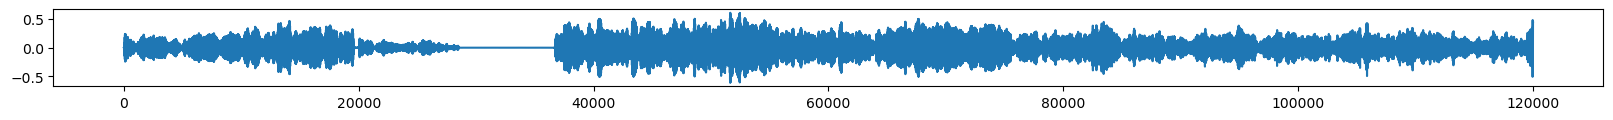

Finished epoch number 167 with a total of 10000 debug_seqs
 time: 2025-10-27 20:36:11.962705, epoch 168,  Loss: 0.2137
  Quantizer 0 Loss: 2.1451
  Quantizer 1 Loss: 2.6480
  Quantizer 2 Loss: 3.2924
  Quantizer 3 Loss: 3.7423
  Quantizer 4 Loss: 4.0555
  Quantizer 5 Loss: 4.2687
  Quantizer 6 Loss: 4.5109
  Quantizer 7 Loss: 4.6462
Latents embedded in 106 of the GRU input size of 128
Conditioning parameters embedded in 22 of the GRU input size of 128
DEVICE going in: model tensors cuda:0, enc_model cpu, c cuda:0
About toInitialize generator with c.shape = torch.Size([8])
params_seq.shape = torch.Size([10, 8])
plot the audio which has shape (120000,)


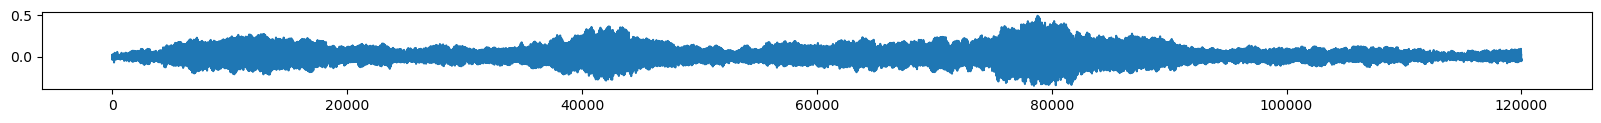

Finished epoch number 168 with a total of 10000 debug_seqs
 time: 2025-10-27 20:36:59.664657, epoch 169,  Loss: 0.2198
  Quantizer 0 Loss: 2.1551
  Quantizer 1 Loss: 2.6495
  Quantizer 2 Loss: 3.3071
  Quantizer 3 Loss: 3.7640
  Quantizer 4 Loss: 4.0776
  Quantizer 5 Loss: 4.2856
  Quantizer 6 Loss: 4.5324
  Quantizer 7 Loss: 4.6692
Latents embedded in 106 of the GRU input size of 128
Conditioning parameters embedded in 22 of the GRU input size of 128
DEVICE going in: model tensors cuda:0, enc_model cpu, c cuda:0
About toInitialize generator with c.shape = torch.Size([8])
params_seq.shape = torch.Size([10, 8])
plot the audio which has shape (120000,)


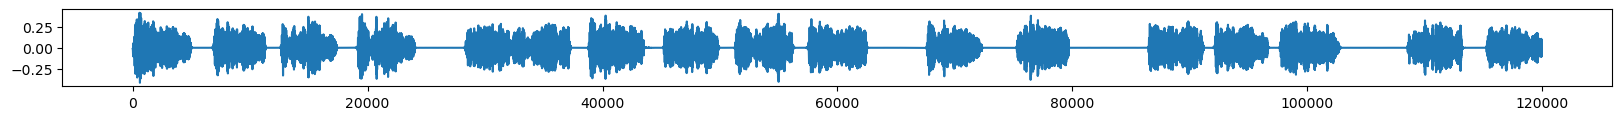

Finished epoch number 169 with a total of 10000 debug_seqs
 time: 2025-10-27 20:37:46.151924, epoch 170,  Loss: 0.2253
  Quantizer 0 Loss: 2.1608
  Quantizer 1 Loss: 2.6545
  Quantizer 2 Loss: 3.3033
  Quantizer 3 Loss: 3.7521
  Quantizer 4 Loss: 4.0720
  Quantizer 5 Loss: 4.2724
  Quantizer 6 Loss: 4.5209
  Quantizer 7 Loss: 4.6535
Latents embedded in 106 of the GRU input size of 128
Conditioning parameters embedded in 22 of the GRU input size of 128
DEVICE going in: model tensors cuda:0, enc_model cpu, c cuda:0
About toInitialize generator with c.shape = torch.Size([8])
params_seq.shape = torch.Size([10, 8])
plot the audio which has shape (120000,)


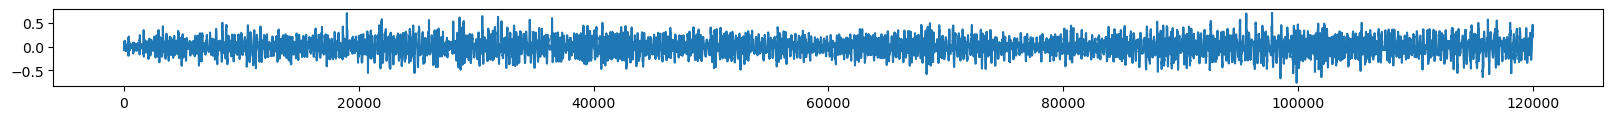

Finished epoch number 170 with a total of 10000 debug_seqs
 time: 2025-10-27 20:38:32.833907, epoch 171,  Loss: 0.2122
  Quantizer 0 Loss: 2.1612
  Quantizer 1 Loss: 2.6518
  Quantizer 2 Loss: 3.3098
  Quantizer 3 Loss: 3.7608
  Quantizer 4 Loss: 4.0799
  Quantizer 5 Loss: 4.2848
  Quantizer 6 Loss: 4.5313
  Quantizer 7 Loss: 4.6622
Latents embedded in 106 of the GRU input size of 128
Conditioning parameters embedded in 22 of the GRU input size of 128
DEVICE going in: model tensors cuda:0, enc_model cpu, c cuda:0
About toInitialize generator with c.shape = torch.Size([8])
params_seq.shape = torch.Size([10, 8])
plot the audio which has shape (120000,)


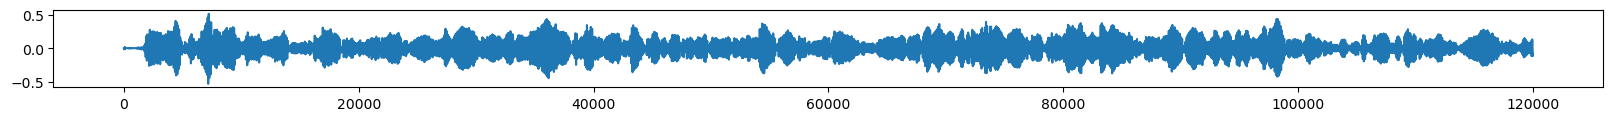

Finished epoch number 171 with a total of 10000 debug_seqs
 time: 2025-10-27 20:39:19.927817, epoch 172,  Loss: 0.2182
  Quantizer 0 Loss: 2.1562
  Quantizer 1 Loss: 2.6428
  Quantizer 2 Loss: 3.3029
  Quantizer 3 Loss: 3.7532
  Quantizer 4 Loss: 4.0699
  Quantizer 5 Loss: 4.2770
  Quantizer 6 Loss: 4.5233
  Quantizer 7 Loss: 4.6538
Latents embedded in 106 of the GRU input size of 128
Conditioning parameters embedded in 22 of the GRU input size of 128
DEVICE going in: model tensors cuda:0, enc_model cpu, c cuda:0
About toInitialize generator with c.shape = torch.Size([8])
params_seq.shape = torch.Size([10, 8])
plot the audio which has shape (120000,)


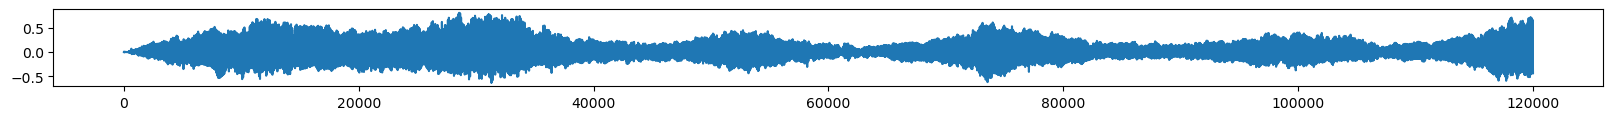

Finished epoch number 172 with a total of 10000 debug_seqs
 time: 2025-10-27 20:40:06.479282, epoch 173,  Loss: 0.2132
  Quantizer 0 Loss: 2.1662
  Quantizer 1 Loss: 2.6597
  Quantizer 2 Loss: 3.3100
  Quantizer 3 Loss: 3.7601
  Quantizer 4 Loss: 4.0782
  Quantizer 5 Loss: 4.2822
  Quantizer 6 Loss: 4.5245
  Quantizer 7 Loss: 4.6586
Latents embedded in 106 of the GRU input size of 128
Conditioning parameters embedded in 22 of the GRU input size of 128
DEVICE going in: model tensors cuda:0, enc_model cpu, c cuda:0
About toInitialize generator with c.shape = torch.Size([8])
params_seq.shape = torch.Size([10, 8])
plot the audio which has shape (120000,)


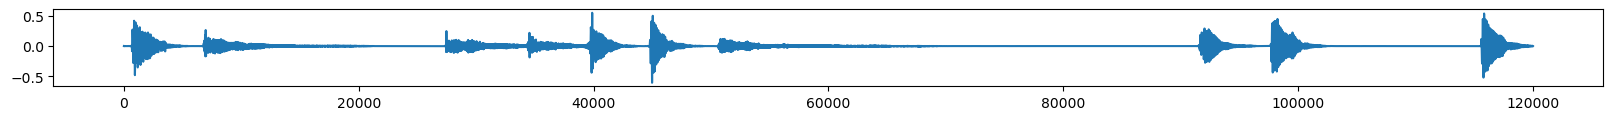

Finished epoch number 173 with a total of 10000 debug_seqs
 time: 2025-10-27 20:40:53.922931, epoch 174,  Loss: 0.2157
  Quantizer 0 Loss: 2.1753
  Quantizer 1 Loss: 2.6793
  Quantizer 2 Loss: 3.3251
  Quantizer 3 Loss: 3.7762
  Quantizer 4 Loss: 4.0874
  Quantizer 5 Loss: 4.2946
  Quantizer 6 Loss: 4.5411
  Quantizer 7 Loss: 4.6731
Latents embedded in 106 of the GRU input size of 128
Conditioning parameters embedded in 22 of the GRU input size of 128
DEVICE going in: model tensors cuda:0, enc_model cpu, c cuda:0
About toInitialize generator with c.shape = torch.Size([8])
params_seq.shape = torch.Size([10, 8])
plot the audio which has shape (120000,)


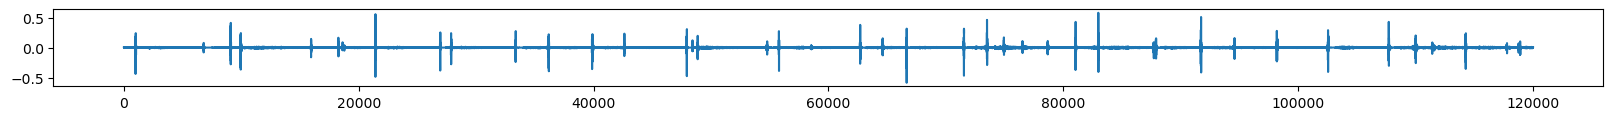

Finished epoch number 174 with a total of 10000 debug_seqs
 time: 2025-10-27 20:41:40.588222, epoch 175,  Loss: 0.2199
  Quantizer 0 Loss: 2.1556
  Quantizer 1 Loss: 2.6564
  Quantizer 2 Loss: 3.3065
  Quantizer 3 Loss: 3.7595
  Quantizer 4 Loss: 4.0754
  Quantizer 5 Loss: 4.2816
  Quantizer 6 Loss: 4.5281
  Quantizer 7 Loss: 4.6658
Latents embedded in 106 of the GRU input size of 128
Conditioning parameters embedded in 22 of the GRU input size of 128
DEVICE going in: model tensors cuda:0, enc_model cpu, c cuda:0
About toInitialize generator with c.shape = torch.Size([8])
params_seq.shape = torch.Size([10, 8])
plot the audio which has shape (120000,)


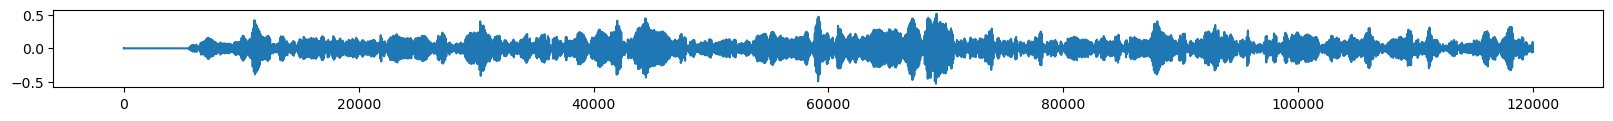

Saved checkpoint at epoch 175
Finished epoch number 175 with a total of 10000 debug_seqs
 time: 2025-10-27 20:42:27.328788, epoch 176,  Loss: 0.2362
  Quantizer 0 Loss: 2.2364
  Quantizer 1 Loss: 3.3274
  Quantizer 2 Loss: 3.9973
  Quantizer 3 Loss: 4.4276
  Quantizer 4 Loss: 4.7189
  Quantizer 5 Loss: 4.8999
  Quantizer 6 Loss: 5.1324
  Quantizer 7 Loss: 5.2273
Latents embedded in 106 of the GRU input size of 128
Conditioning parameters embedded in 22 of the GRU input size of 128
DEVICE going in: model tensors cuda:0, enc_model cpu, c cuda:0
About toInitialize generator with c.shape = torch.Size([8])
params_seq.shape = torch.Size([10, 8])
plot the audio which has shape (120000,)


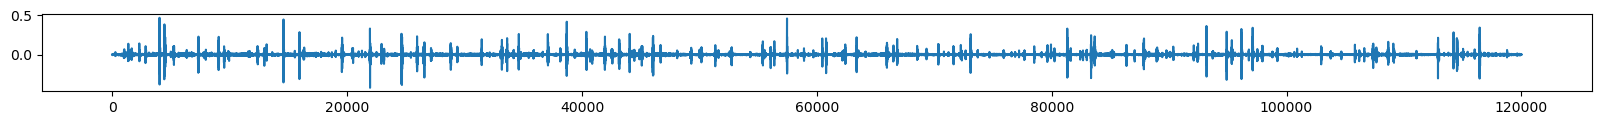

Finished epoch number 176 with a total of 10000 debug_seqs
 time: 2025-10-27 20:43:14.433028, epoch 177,  Loss: 0.2505
  Quantizer 0 Loss: 2.1954
  Quantizer 1 Loss: 3.1568
  Quantizer 2 Loss: 3.9034
  Quantizer 3 Loss: 4.3632
  Quantizer 4 Loss: 4.6604
  Quantizer 5 Loss: 4.8518
  Quantizer 6 Loss: 5.0808
  Quantizer 7 Loss: 5.1841
Latents embedded in 106 of the GRU input size of 128
Conditioning parameters embedded in 22 of the GRU input size of 128
DEVICE going in: model tensors cuda:0, enc_model cpu, c cuda:0
About toInitialize generator with c.shape = torch.Size([8])
params_seq.shape = torch.Size([10, 8])
plot the audio which has shape (120000,)


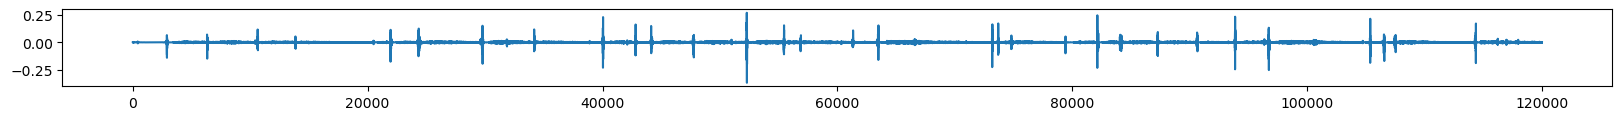

Finished epoch number 177 with a total of 10000 debug_seqs
 time: 2025-10-27 20:44:01.280951, epoch 178,  Loss: 0.2440
  Quantizer 0 Loss: 2.1766
  Quantizer 1 Loss: 3.1081
  Quantizer 2 Loss: 3.8673
  Quantizer 3 Loss: 4.3303
  Quantizer 4 Loss: 4.6344
  Quantizer 5 Loss: 4.8230
  Quantizer 6 Loss: 5.0507
  Quantizer 7 Loss: 5.1529
Latents embedded in 106 of the GRU input size of 128
Conditioning parameters embedded in 22 of the GRU input size of 128
DEVICE going in: model tensors cuda:0, enc_model cpu, c cuda:0
About toInitialize generator with c.shape = torch.Size([8])
params_seq.shape = torch.Size([10, 8])
plot the audio which has shape (120000,)


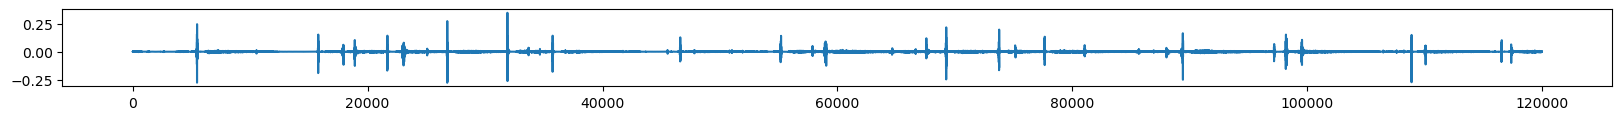

Finished epoch number 178 with a total of 10000 debug_seqs
 time: 2025-10-27 20:44:48.647450, epoch 179,  Loss: 0.2400
  Quantizer 0 Loss: 2.1929
  Quantizer 1 Loss: 3.1308
  Quantizer 2 Loss: 3.8849
  Quantizer 3 Loss: 4.3524
  Quantizer 4 Loss: 4.6537
  Quantizer 5 Loss: 4.8472
  Quantizer 6 Loss: 5.0758
  Quantizer 7 Loss: 5.1841
Latents embedded in 106 of the GRU input size of 128
Conditioning parameters embedded in 22 of the GRU input size of 128
DEVICE going in: model tensors cuda:0, enc_model cpu, c cuda:0
About toInitialize generator with c.shape = torch.Size([8])
params_seq.shape = torch.Size([10, 8])
plot the audio which has shape (120000,)


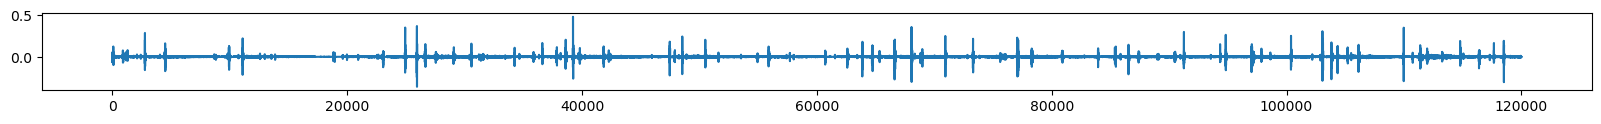

Finished epoch number 179 with a total of 10000 debug_seqs
 time: 2025-10-27 20:45:36.686473, epoch 180,  Loss: 0.2395
  Quantizer 0 Loss: 2.1702
  Quantizer 1 Loss: 3.0998
  Quantizer 2 Loss: 3.8522
  Quantizer 3 Loss: 4.3255
  Quantizer 4 Loss: 4.6335
  Quantizer 5 Loss: 4.8213
  Quantizer 6 Loss: 5.0615
  Quantizer 7 Loss: 5.1610
Latents embedded in 106 of the GRU input size of 128
Conditioning parameters embedded in 22 of the GRU input size of 128
DEVICE going in: model tensors cuda:0, enc_model cpu, c cuda:0
About toInitialize generator with c.shape = torch.Size([8])
params_seq.shape = torch.Size([10, 8])
plot the audio which has shape (120000,)


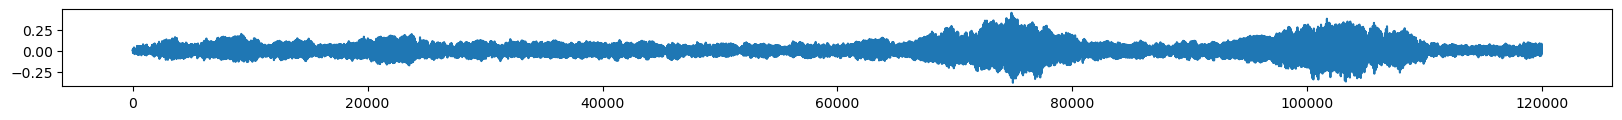

Finished epoch number 180 with a total of 10000 debug_seqs
 time: 2025-10-27 20:46:23.160674, epoch 181,  Loss: 0.2492
  Quantizer 0 Loss: 2.1804
  Quantizer 1 Loss: 3.1049
  Quantizer 2 Loss: 3.8596
  Quantizer 3 Loss: 4.3275
  Quantizer 4 Loss: 4.6360
  Quantizer 5 Loss: 4.8315
  Quantizer 6 Loss: 5.0595
  Quantizer 7 Loss: 5.1636
Latents embedded in 106 of the GRU input size of 128
Conditioning parameters embedded in 22 of the GRU input size of 128
DEVICE going in: model tensors cuda:0, enc_model cpu, c cuda:0
About toInitialize generator with c.shape = torch.Size([8])
params_seq.shape = torch.Size([10, 8])
plot the audio which has shape (120000,)


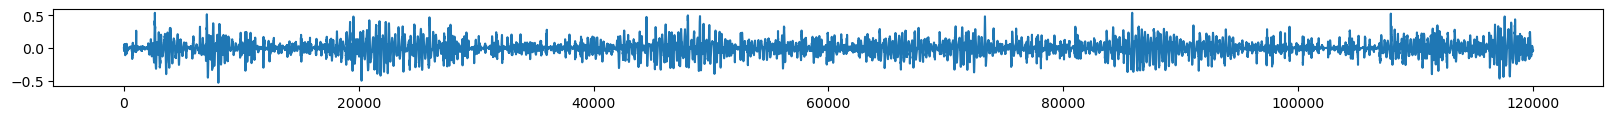

Finished epoch number 181 with a total of 10000 debug_seqs
 time: 2025-10-27 20:47:09.684320, epoch 182,  Loss: 0.2430
  Quantizer 0 Loss: 2.1597
  Quantizer 1 Loss: 3.0747
  Quantizer 2 Loss: 3.8269
  Quantizer 3 Loss: 4.2982
  Quantizer 4 Loss: 4.6144
  Quantizer 5 Loss: 4.8079
  Quantizer 6 Loss: 5.0363
  Quantizer 7 Loss: 5.1425
Latents embedded in 106 of the GRU input size of 128
Conditioning parameters embedded in 22 of the GRU input size of 128
DEVICE going in: model tensors cuda:0, enc_model cpu, c cuda:0
About toInitialize generator with c.shape = torch.Size([8])
params_seq.shape = torch.Size([10, 8])
plot the audio which has shape (120000,)


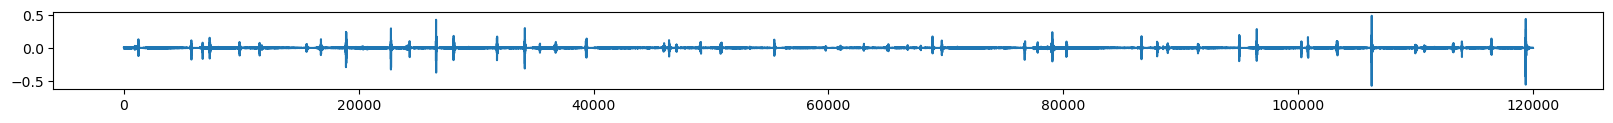

Finished epoch number 182 with a total of 10000 debug_seqs
 time: 2025-10-27 20:47:56.354274, epoch 183,  Loss: 0.2410
  Quantizer 0 Loss: 2.1630
  Quantizer 1 Loss: 3.0840
  Quantizer 2 Loss: 3.8385
  Quantizer 3 Loss: 4.3085
  Quantizer 4 Loss: 4.6157
  Quantizer 5 Loss: 4.8159
  Quantizer 6 Loss: 5.0502
  Quantizer 7 Loss: 5.1548
Latents embedded in 106 of the GRU input size of 128
Conditioning parameters embedded in 22 of the GRU input size of 128
DEVICE going in: model tensors cuda:0, enc_model cpu, c cuda:0
About toInitialize generator with c.shape = torch.Size([8])
params_seq.shape = torch.Size([10, 8])
plot the audio which has shape (120000,)


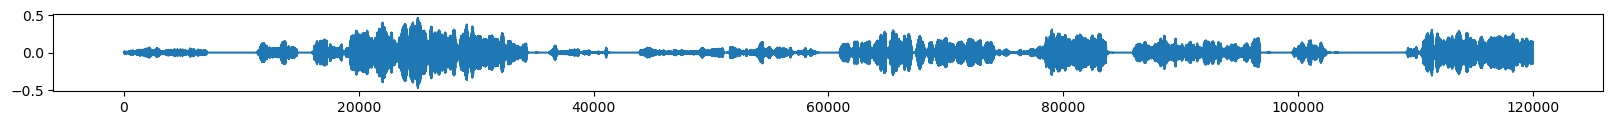

Finished epoch number 183 with a total of 10000 debug_seqs
 time: 2025-10-27 20:48:42.700621, epoch 184,  Loss: 0.2451
  Quantizer 0 Loss: 2.1631
  Quantizer 1 Loss: 3.0802
  Quantizer 2 Loss: 3.8374
  Quantizer 3 Loss: 4.3114
  Quantizer 4 Loss: 4.6233
  Quantizer 5 Loss: 4.8098
  Quantizer 6 Loss: 5.0419
  Quantizer 7 Loss: 5.1476
Latents embedded in 106 of the GRU input size of 128
Conditioning parameters embedded in 22 of the GRU input size of 128
DEVICE going in: model tensors cuda:0, enc_model cpu, c cuda:0
About toInitialize generator with c.shape = torch.Size([8])
params_seq.shape = torch.Size([10, 8])
plot the audio which has shape (120000,)


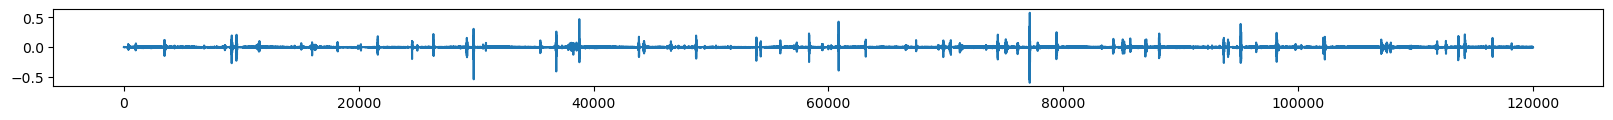

Finished epoch number 184 with a total of 10000 debug_seqs
 time: 2025-10-27 20:49:30.356992, epoch 185,  Loss: 0.2328
  Quantizer 0 Loss: 2.1592
  Quantizer 1 Loss: 3.0766
  Quantizer 2 Loss: 3.8259
  Quantizer 3 Loss: 4.2978
  Quantizer 4 Loss: 4.6090
  Quantizer 5 Loss: 4.8032
  Quantizer 6 Loss: 5.0310
  Quantizer 7 Loss: 5.1387
Latents embedded in 106 of the GRU input size of 128
Conditioning parameters embedded in 22 of the GRU input size of 128
DEVICE going in: model tensors cuda:0, enc_model cpu, c cuda:0
About toInitialize generator with c.shape = torch.Size([8])
params_seq.shape = torch.Size([10, 8])
plot the audio which has shape (120000,)


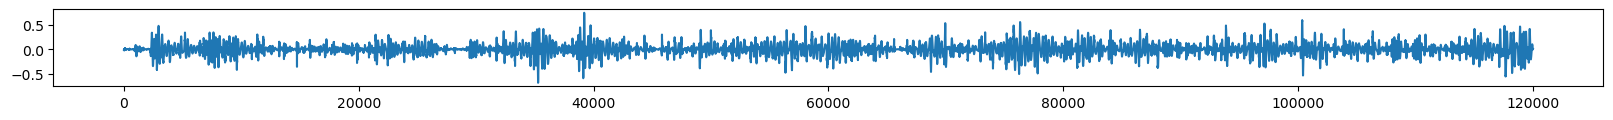

Finished epoch number 185 with a total of 10000 debug_seqs
 time: 2025-10-27 20:50:18.326734, epoch 186,  Loss: 0.2372
  Quantizer 0 Loss: 2.1650
  Quantizer 1 Loss: 3.0805
  Quantizer 2 Loss: 3.8333
  Quantizer 3 Loss: 4.3023
  Quantizer 4 Loss: 4.6167
  Quantizer 5 Loss: 4.8119
  Quantizer 6 Loss: 5.0380
  Quantizer 7 Loss: 5.1420
Latents embedded in 106 of the GRU input size of 128
Conditioning parameters embedded in 22 of the GRU input size of 128
DEVICE going in: model tensors cuda:0, enc_model cpu, c cuda:0
About toInitialize generator with c.shape = torch.Size([8])
params_seq.shape = torch.Size([10, 8])
plot the audio which has shape (120000,)


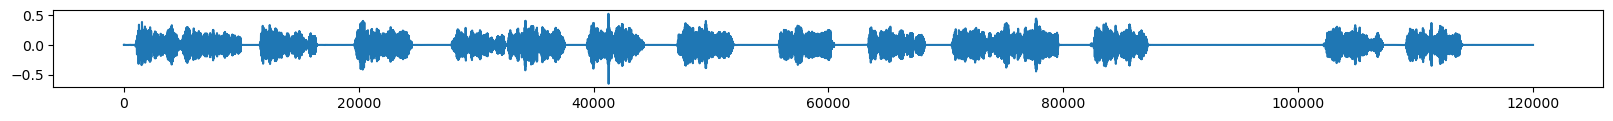

Finished epoch number 186 with a total of 10000 debug_seqs
 time: 2025-10-27 20:51:05.821745, epoch 187,  Loss: 0.2336
  Quantizer 0 Loss: 2.1723
  Quantizer 1 Loss: 3.0843
  Quantizer 2 Loss: 3.8313
  Quantizer 3 Loss: 4.3053
  Quantizer 4 Loss: 4.6147
  Quantizer 5 Loss: 4.8055
  Quantizer 6 Loss: 5.0343
  Quantizer 7 Loss: 5.1343
Latents embedded in 106 of the GRU input size of 128
Conditioning parameters embedded in 22 of the GRU input size of 128
DEVICE going in: model tensors cuda:0, enc_model cpu, c cuda:0
About toInitialize generator with c.shape = torch.Size([8])
params_seq.shape = torch.Size([10, 8])
plot the audio which has shape (120000,)


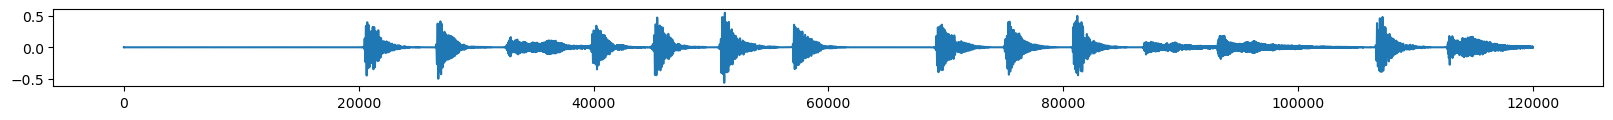

Finished epoch number 187 with a total of 10000 debug_seqs
 time: 2025-10-27 20:51:52.436227, epoch 188,  Loss: 0.2445
  Quantizer 0 Loss: 2.1632
  Quantizer 1 Loss: 3.0746
  Quantizer 2 Loss: 3.8339
  Quantizer 3 Loss: 4.3105
  Quantizer 4 Loss: 4.6276
  Quantizer 5 Loss: 4.8271
  Quantizer 6 Loss: 5.0599
  Quantizer 7 Loss: 5.1623
Latents embedded in 106 of the GRU input size of 128
Conditioning parameters embedded in 22 of the GRU input size of 128
DEVICE going in: model tensors cuda:0, enc_model cpu, c cuda:0
About toInitialize generator with c.shape = torch.Size([8])
params_seq.shape = torch.Size([10, 8])
plot the audio which has shape (120000,)


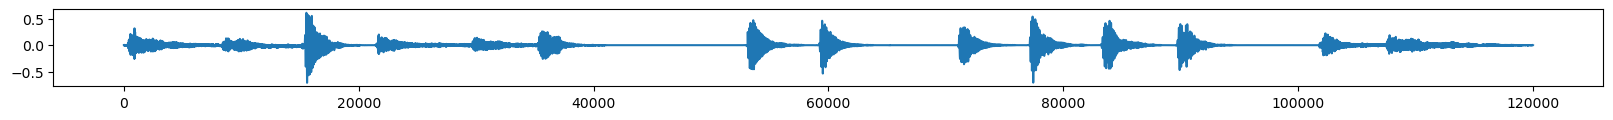

Finished epoch number 188 with a total of 10000 debug_seqs
 time: 2025-10-27 20:52:38.887186, epoch 189,  Loss: 0.2424
  Quantizer 0 Loss: 2.1716
  Quantizer 1 Loss: 3.0842
  Quantizer 2 Loss: 3.8427
  Quantizer 3 Loss: 4.3152
  Quantizer 4 Loss: 4.6276
  Quantizer 5 Loss: 4.8226
  Quantizer 6 Loss: 5.0535
  Quantizer 7 Loss: 5.1610
Latents embedded in 106 of the GRU input size of 128
Conditioning parameters embedded in 22 of the GRU input size of 128
DEVICE going in: model tensors cuda:0, enc_model cpu, c cuda:0
About toInitialize generator with c.shape = torch.Size([8])
params_seq.shape = torch.Size([10, 8])
plot the audio which has shape (120000,)


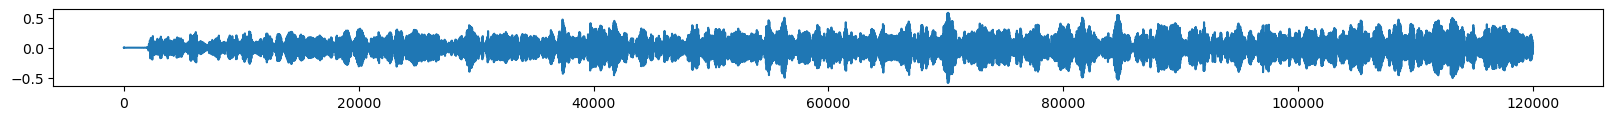

Finished epoch number 189 with a total of 10000 debug_seqs
 time: 2025-10-27 20:53:25.682081, epoch 190,  Loss: 0.2543
  Quantizer 0 Loss: 2.1732
  Quantizer 1 Loss: 3.0838
  Quantizer 2 Loss: 3.8453
  Quantizer 3 Loss: 4.3154
  Quantizer 4 Loss: 4.6284
  Quantizer 5 Loss: 4.8181
  Quantizer 6 Loss: 5.0468
  Quantizer 7 Loss: 5.1535
Latents embedded in 106 of the GRU input size of 128
Conditioning parameters embedded in 22 of the GRU input size of 128
DEVICE going in: model tensors cuda:0, enc_model cpu, c cuda:0
About toInitialize generator with c.shape = torch.Size([8])
params_seq.shape = torch.Size([10, 8])
plot the audio which has shape (120000,)


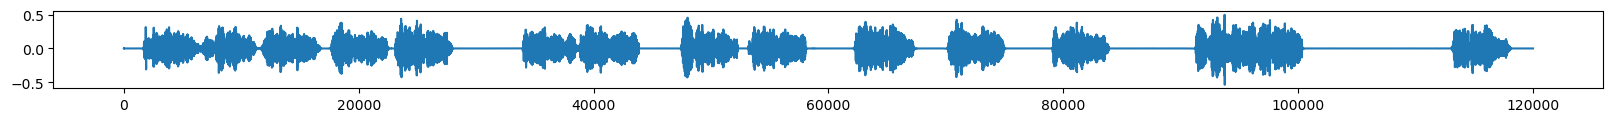

Finished epoch number 190 with a total of 10000 debug_seqs
 time: 2025-10-27 20:54:12.639220, epoch 191,  Loss: 0.2405
  Quantizer 0 Loss: 2.1602
  Quantizer 1 Loss: 3.0827
  Quantizer 2 Loss: 3.8288
  Quantizer 3 Loss: 4.3049
  Quantizer 4 Loss: 4.6197
  Quantizer 5 Loss: 4.8184
  Quantizer 6 Loss: 5.0500
  Quantizer 7 Loss: 5.1552
Latents embedded in 106 of the GRU input size of 128
Conditioning parameters embedded in 22 of the GRU input size of 128
DEVICE going in: model tensors cuda:0, enc_model cpu, c cuda:0
About toInitialize generator with c.shape = torch.Size([8])
params_seq.shape = torch.Size([10, 8])
plot the audio which has shape (120000,)


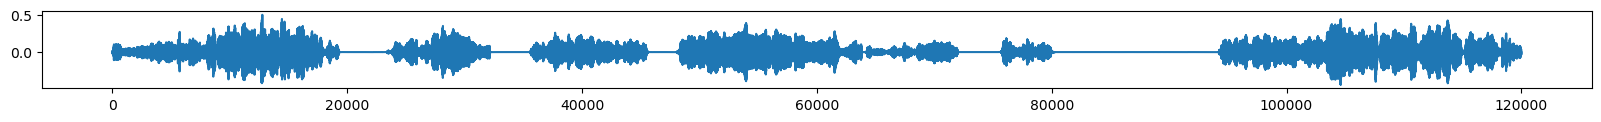

Finished epoch number 191 with a total of 10000 debug_seqs
 time: 2025-10-27 20:55:00.811096, epoch 192,  Loss: 0.2474
  Quantizer 0 Loss: 2.1706
  Quantizer 1 Loss: 3.0724
  Quantizer 2 Loss: 3.8334
  Quantizer 3 Loss: 4.3072
  Quantizer 4 Loss: 4.6222
  Quantizer 5 Loss: 4.8166
  Quantizer 6 Loss: 5.0448
  Quantizer 7 Loss: 5.1513
Latents embedded in 106 of the GRU input size of 128
Conditioning parameters embedded in 22 of the GRU input size of 128
DEVICE going in: model tensors cuda:0, enc_model cpu, c cuda:0
About toInitialize generator with c.shape = torch.Size([8])
params_seq.shape = torch.Size([10, 8])
plot the audio which has shape (120000,)


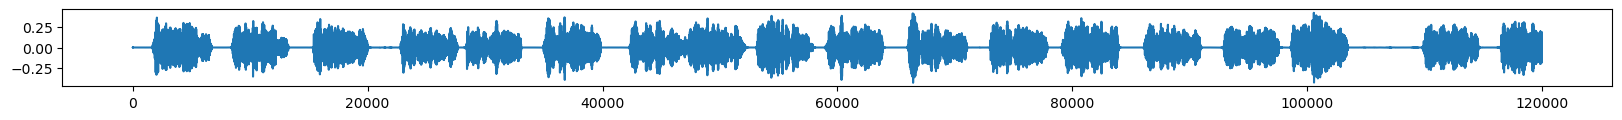

Finished epoch number 192 with a total of 10000 debug_seqs
 time: 2025-10-27 20:55:48.252912, epoch 193,  Loss: 0.2482
  Quantizer 0 Loss: 2.1532
  Quantizer 1 Loss: 3.0630
  Quantizer 2 Loss: 3.8198
  Quantizer 3 Loss: 4.2925
  Quantizer 4 Loss: 4.6045
  Quantizer 5 Loss: 4.7999
  Quantizer 6 Loss: 5.0352
  Quantizer 7 Loss: 5.1425
Latents embedded in 106 of the GRU input size of 128
Conditioning parameters embedded in 22 of the GRU input size of 128
DEVICE going in: model tensors cuda:0, enc_model cpu, c cuda:0
About toInitialize generator with c.shape = torch.Size([8])
params_seq.shape = torch.Size([10, 8])
plot the audio which has shape (120000,)


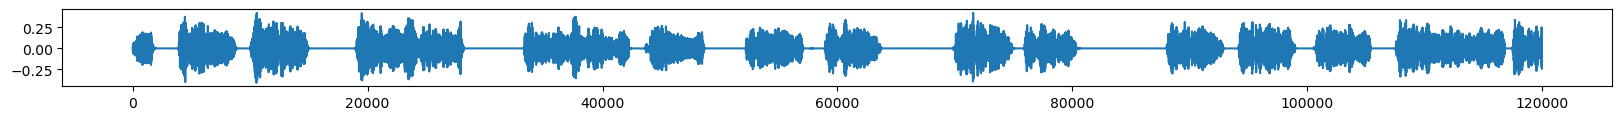

Finished epoch number 193 with a total of 10000 debug_seqs
 time: 2025-10-27 20:56:34.681976, epoch 194,  Loss: 0.2425
  Quantizer 0 Loss: 2.1545
  Quantizer 1 Loss: 3.0635
  Quantizer 2 Loss: 3.8167
  Quantizer 3 Loss: 4.2891
  Quantizer 4 Loss: 4.6007
  Quantizer 5 Loss: 4.7989
  Quantizer 6 Loss: 5.0300
  Quantizer 7 Loss: 5.1319
Latents embedded in 106 of the GRU input size of 128
Conditioning parameters embedded in 22 of the GRU input size of 128
DEVICE going in: model tensors cuda:0, enc_model cpu, c cuda:0
About toInitialize generator with c.shape = torch.Size([8])
params_seq.shape = torch.Size([10, 8])
plot the audio which has shape (120000,)


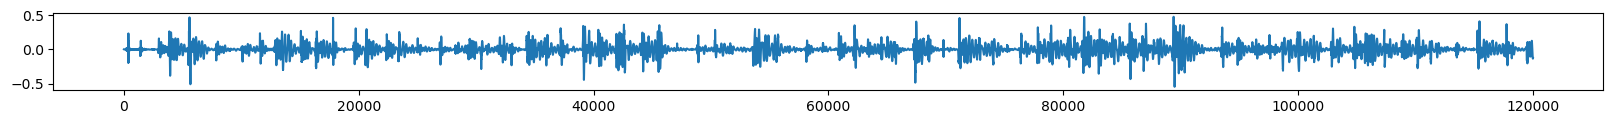

Finished epoch number 194 with a total of 10000 debug_seqs
 time: 2025-10-27 20:57:21.438167, epoch 195,  Loss: 0.2470
  Quantizer 0 Loss: 2.1517
  Quantizer 1 Loss: 3.0625
  Quantizer 2 Loss: 3.8149
  Quantizer 3 Loss: 4.2806
  Quantizer 4 Loss: 4.5924
  Quantizer 5 Loss: 4.7933
  Quantizer 6 Loss: 5.0223
  Quantizer 7 Loss: 5.1290
Latents embedded in 106 of the GRU input size of 128
Conditioning parameters embedded in 22 of the GRU input size of 128
DEVICE going in: model tensors cuda:0, enc_model cpu, c cuda:0
About toInitialize generator with c.shape = torch.Size([8])
params_seq.shape = torch.Size([10, 8])
plot the audio which has shape (120000,)


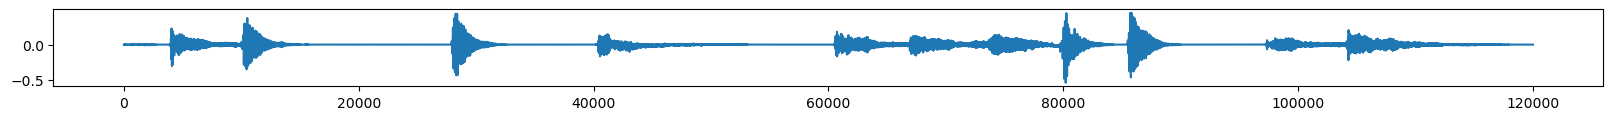

Finished epoch number 195 with a total of 10000 debug_seqs
 time: 2025-10-27 20:58:07.775749, epoch 196,  Loss: 0.2433
  Quantizer 0 Loss: 2.1602
  Quantizer 1 Loss: 3.0750
  Quantizer 2 Loss: 3.8364
  Quantizer 3 Loss: 4.3035
  Quantizer 4 Loss: 4.6182
  Quantizer 5 Loss: 4.8145
  Quantizer 6 Loss: 5.0439
  Quantizer 7 Loss: 5.1468
Latents embedded in 106 of the GRU input size of 128
Conditioning parameters embedded in 22 of the GRU input size of 128
DEVICE going in: model tensors cuda:0, enc_model cpu, c cuda:0
About toInitialize generator with c.shape = torch.Size([8])
params_seq.shape = torch.Size([10, 8])
plot the audio which has shape (120000,)


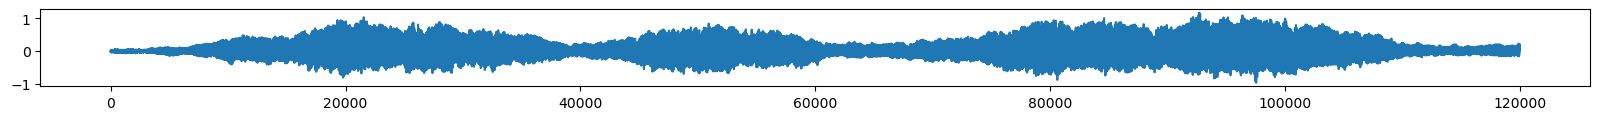

Finished epoch number 196 with a total of 10000 debug_seqs
 time: 2025-10-27 20:58:56.269553, epoch 197,  Loss: 0.2414
  Quantizer 0 Loss: 2.1764
  Quantizer 1 Loss: 3.0856
  Quantizer 2 Loss: 3.8434
  Quantizer 3 Loss: 4.3113
  Quantizer 4 Loss: 4.6234
  Quantizer 5 Loss: 4.8172
  Quantizer 6 Loss: 5.0434
  Quantizer 7 Loss: 5.1523
Latents embedded in 106 of the GRU input size of 128
Conditioning parameters embedded in 22 of the GRU input size of 128
DEVICE going in: model tensors cuda:0, enc_model cpu, c cuda:0
About toInitialize generator with c.shape = torch.Size([8])
params_seq.shape = torch.Size([10, 8])
plot the audio which has shape (120000,)


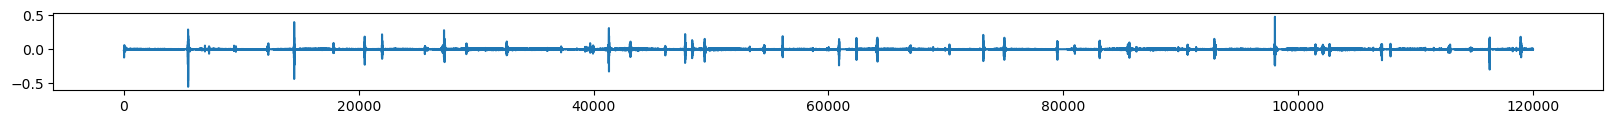

Finished epoch number 197 with a total of 10000 debug_seqs
 time: 2025-10-27 20:59:43.684548, epoch 198,  Loss: 0.2485
  Quantizer 0 Loss: 2.1577
  Quantizer 1 Loss: 3.0714
  Quantizer 2 Loss: 3.8300
  Quantizer 3 Loss: 4.3094
  Quantizer 4 Loss: 4.6151
  Quantizer 5 Loss: 4.8123
  Quantizer 6 Loss: 5.0425
  Quantizer 7 Loss: 5.1499
Latents embedded in 106 of the GRU input size of 128
Conditioning parameters embedded in 22 of the GRU input size of 128
DEVICE going in: model tensors cuda:0, enc_model cpu, c cuda:0
About toInitialize generator with c.shape = torch.Size([8])
params_seq.shape = torch.Size([10, 8])
plot the audio which has shape (120000,)


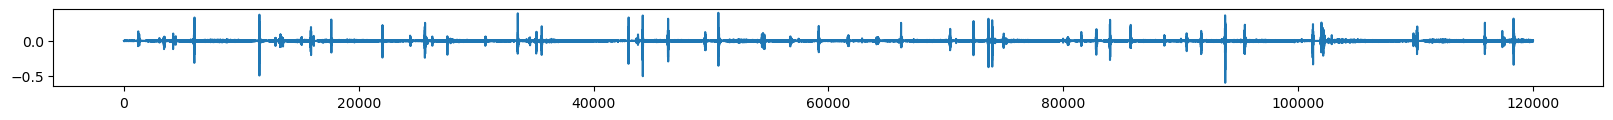

Finished epoch number 198 with a total of 10000 debug_seqs
 time: 2025-10-27 21:00:30.334640, epoch 199,  Loss: 0.2413
  Quantizer 0 Loss: 2.1521
  Quantizer 1 Loss: 3.0666
  Quantizer 2 Loss: 3.8195
  Quantizer 3 Loss: 4.2910
  Quantizer 4 Loss: 4.6020
  Quantizer 5 Loss: 4.7979
  Quantizer 6 Loss: 5.0261
  Quantizer 7 Loss: 5.1347
Latents embedded in 106 of the GRU input size of 128
Conditioning parameters embedded in 22 of the GRU input size of 128
DEVICE going in: model tensors cuda:0, enc_model cpu, c cuda:0
About toInitialize generator with c.shape = torch.Size([8])
params_seq.shape = torch.Size([10, 8])
plot the audio which has shape (120000,)


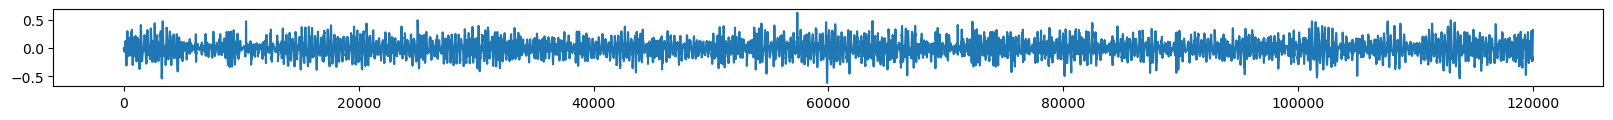

Finished epoch number 199 with a total of 10000 debug_seqs
 time: 2025-10-27 21:01:18.635035, epoch 200,  Loss: 0.2372
  Quantizer 0 Loss: 2.1618
  Quantizer 1 Loss: 3.0625
  Quantizer 2 Loss: 3.8161
  Quantizer 3 Loss: 4.2917
  Quantizer 4 Loss: 4.5991
  Quantizer 5 Loss: 4.7947
  Quantizer 6 Loss: 5.0279
  Quantizer 7 Loss: 5.1329
Latents embedded in 106 of the GRU input size of 128
Conditioning parameters embedded in 22 of the GRU input size of 128
DEVICE going in: model tensors cuda:0, enc_model cpu, c cuda:0
About toInitialize generator with c.shape = torch.Size([8])
params_seq.shape = torch.Size([10, 8])
plot the audio which has shape (120000,)


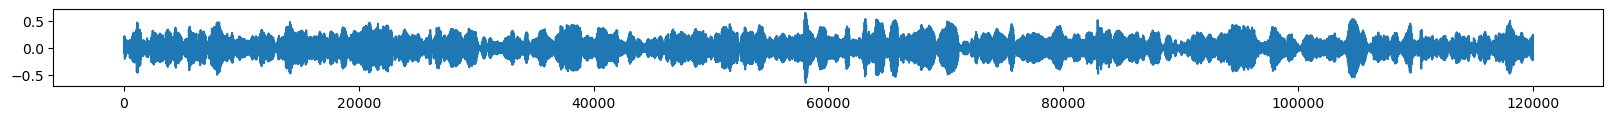

Saved checkpoint at epoch 200
Finished epoch number 200 with a total of 10000 debug_seqs
 time: 2025-10-27 21:02:05.156966, epoch 201,  Loss: 0.2220
  Quantizer 0 Loss: 2.1487
  Quantizer 1 Loss: 2.6989
  Quantizer 2 Loss: 3.3882
  Quantizer 3 Loss: 3.8522
  Quantizer 4 Loss: 4.1821
  Quantizer 5 Loss: 4.3894
  Quantizer 6 Loss: 4.6406
  Quantizer 7 Loss: 4.7705
Latents embedded in 106 of the GRU input size of 128
Conditioning parameters embedded in 22 of the GRU input size of 128
DEVICE going in: model tensors cuda:0, enc_model cpu, c cuda:0
About toInitialize generator with c.shape = torch.Size([8])
params_seq.shape = torch.Size([10, 8])
plot the audio which has shape (120000,)


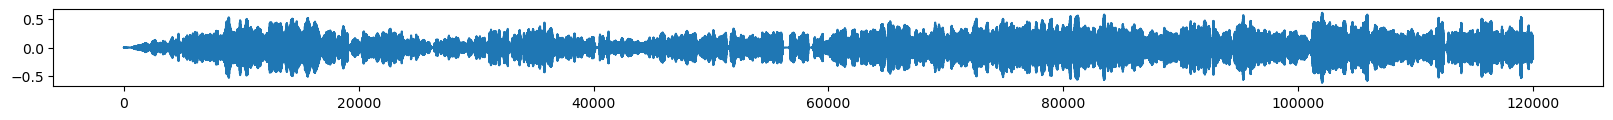

Finished epoch number 201 with a total of 10000 debug_seqs
 time: 2025-10-27 21:02:51.862876, epoch 202,  Loss: 0.2142
  Quantizer 0 Loss: 2.1459
  Quantizer 1 Loss: 2.6619
  Quantizer 2 Loss: 3.3364
  Quantizer 3 Loss: 3.7986
  Quantizer 4 Loss: 4.1246
  Quantizer 5 Loss: 4.3412
  Quantizer 6 Loss: 4.5866
  Quantizer 7 Loss: 4.7200
Latents embedded in 106 of the GRU input size of 128
Conditioning parameters embedded in 22 of the GRU input size of 128
DEVICE going in: model tensors cuda:0, enc_model cpu, c cuda:0
About toInitialize generator with c.shape = torch.Size([8])
params_seq.shape = torch.Size([10, 8])
plot the audio which has shape (120000,)


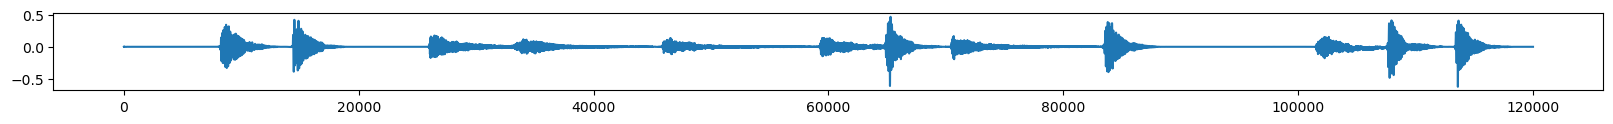

Finished epoch number 202 with a total of 10000 debug_seqs
 time: 2025-10-27 21:03:38.308123, epoch 203,  Loss: 0.2108
  Quantizer 0 Loss: 2.1449
  Quantizer 1 Loss: 2.6491
  Quantizer 2 Loss: 3.3170
  Quantizer 3 Loss: 3.7770
  Quantizer 4 Loss: 4.1021
  Quantizer 5 Loss: 4.3136
  Quantizer 6 Loss: 4.5598
  Quantizer 7 Loss: 4.6921
Latents embedded in 106 of the GRU input size of 128
Conditioning parameters embedded in 22 of the GRU input size of 128
DEVICE going in: model tensors cuda:0, enc_model cpu, c cuda:0
About toInitialize generator with c.shape = torch.Size([8])
params_seq.shape = torch.Size([10, 8])
plot the audio which has shape (120000,)


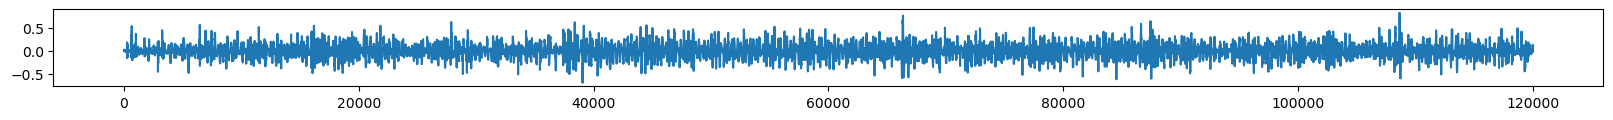

Finished epoch number 203 with a total of 10000 debug_seqs
 time: 2025-10-27 21:04:25.536201, epoch 204,  Loss: 0.2140
  Quantizer 0 Loss: 2.1354
  Quantizer 1 Loss: 2.6395
  Quantizer 2 Loss: 3.3025
  Quantizer 3 Loss: 3.7606
  Quantizer 4 Loss: 4.0815
  Quantizer 5 Loss: 4.2872
  Quantizer 6 Loss: 4.5376
  Quantizer 7 Loss: 4.6659
Latents embedded in 106 of the GRU input size of 128
Conditioning parameters embedded in 22 of the GRU input size of 128
DEVICE going in: model tensors cuda:0, enc_model cpu, c cuda:0
About toInitialize generator with c.shape = torch.Size([8])
params_seq.shape = torch.Size([10, 8])
plot the audio which has shape (120000,)


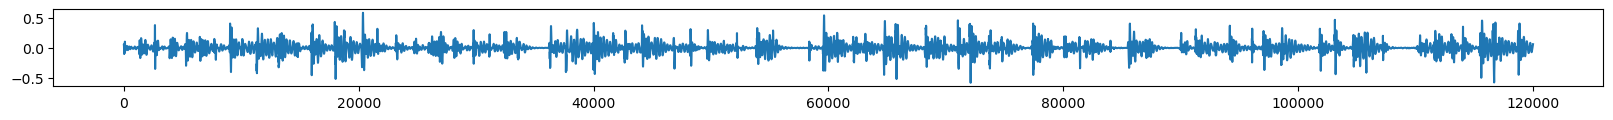

Finished epoch number 204 with a total of 10000 debug_seqs
 time: 2025-10-27 21:05:11.988768, epoch 205,  Loss: 0.2092
  Quantizer 0 Loss: 2.1469
  Quantizer 1 Loss: 2.6484
  Quantizer 2 Loss: 3.3027
  Quantizer 3 Loss: 3.7649
  Quantizer 4 Loss: 4.0813
  Quantizer 5 Loss: 4.2867
  Quantizer 6 Loss: 4.5456
  Quantizer 7 Loss: 4.6759
Latents embedded in 106 of the GRU input size of 128
Conditioning parameters embedded in 22 of the GRU input size of 128
DEVICE going in: model tensors cuda:0, enc_model cpu, c cuda:0
About toInitialize generator with c.shape = torch.Size([8])
params_seq.shape = torch.Size([10, 8])
plot the audio which has shape (120000,)


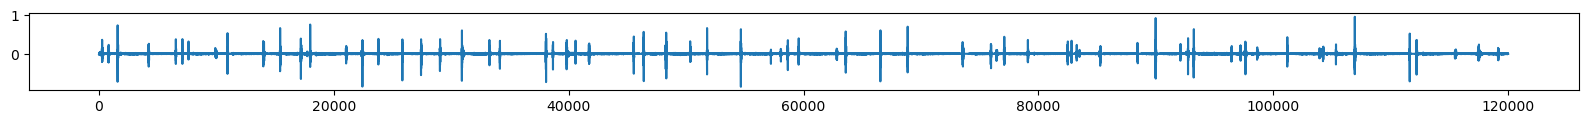

Finished epoch number 205 with a total of 10000 debug_seqs
 time: 2025-10-27 21:05:59.145906, epoch 206,  Loss: 0.2156
  Quantizer 0 Loss: 2.1399
  Quantizer 1 Loss: 2.6392
  Quantizer 2 Loss: 3.2955
  Quantizer 3 Loss: 3.7517
  Quantizer 4 Loss: 4.0730
  Quantizer 5 Loss: 4.2803
  Quantizer 6 Loss: 4.5245
  Quantizer 7 Loss: 4.6605
Latents embedded in 106 of the GRU input size of 128
Conditioning parameters embedded in 22 of the GRU input size of 128
DEVICE going in: model tensors cuda:0, enc_model cpu, c cuda:0
About toInitialize generator with c.shape = torch.Size([8])
params_seq.shape = torch.Size([10, 8])
plot the audio which has shape (120000,)


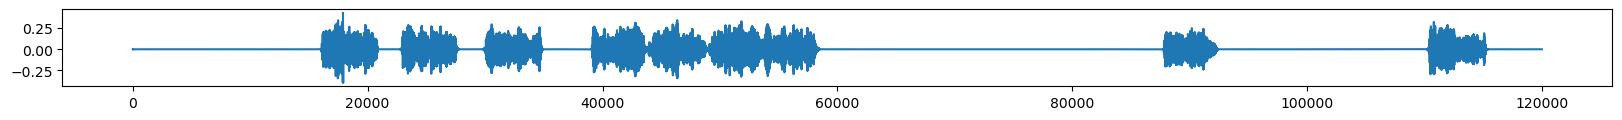

Finished epoch number 206 with a total of 10000 debug_seqs
 time: 2025-10-27 21:06:45.903056, epoch 207,  Loss: 0.2152
  Quantizer 0 Loss: 2.1506
  Quantizer 1 Loss: 2.6495
  Quantizer 2 Loss: 3.3119
  Quantizer 3 Loss: 3.7670
  Quantizer 4 Loss: 4.0865
  Quantizer 5 Loss: 4.2946
  Quantizer 6 Loss: 4.5421
  Quantizer 7 Loss: 4.6737
Latents embedded in 106 of the GRU input size of 128
Conditioning parameters embedded in 22 of the GRU input size of 128
DEVICE going in: model tensors cuda:0, enc_model cpu, c cuda:0
About toInitialize generator with c.shape = torch.Size([8])
params_seq.shape = torch.Size([10, 8])
plot the audio which has shape (120000,)


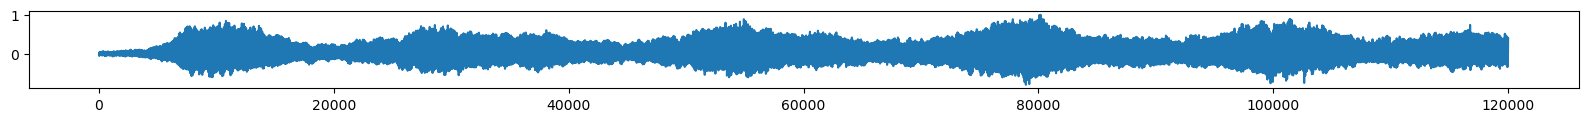

Finished epoch number 207 with a total of 10000 debug_seqs
 time: 2025-10-27 21:07:33.815582, epoch 208,  Loss: 0.2168
  Quantizer 0 Loss: 2.1452
  Quantizer 1 Loss: 2.6428
  Quantizer 2 Loss: 3.3010
  Quantizer 3 Loss: 3.7580
  Quantizer 4 Loss: 4.0713
  Quantizer 5 Loss: 4.2801
  Quantizer 6 Loss: 4.5209
  Quantizer 7 Loss: 4.6572
Latents embedded in 106 of the GRU input size of 128
Conditioning parameters embedded in 22 of the GRU input size of 128
DEVICE going in: model tensors cuda:0, enc_model cpu, c cuda:0
About toInitialize generator with c.shape = torch.Size([8])
params_seq.shape = torch.Size([10, 8])
plot the audio which has shape (120000,)


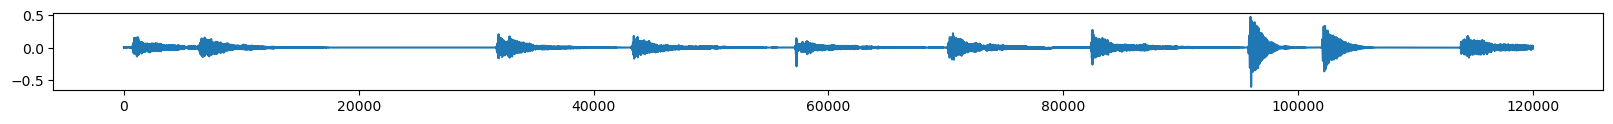

Finished epoch number 208 with a total of 10000 debug_seqs
 time: 2025-10-27 21:08:20.326414, epoch 209,  Loss: 0.2226
  Quantizer 0 Loss: 2.1441
  Quantizer 1 Loss: 2.6470
  Quantizer 2 Loss: 3.3037
  Quantizer 3 Loss: 3.7579
  Quantizer 4 Loss: 4.0753
  Quantizer 5 Loss: 4.2826
  Quantizer 6 Loss: 4.5301
  Quantizer 7 Loss: 4.6676
Latents embedded in 106 of the GRU input size of 128
Conditioning parameters embedded in 22 of the GRU input size of 128
DEVICE going in: model tensors cuda:0, enc_model cpu, c cuda:0
About toInitialize generator with c.shape = torch.Size([8])
params_seq.shape = torch.Size([10, 8])
plot the audio which has shape (120000,)


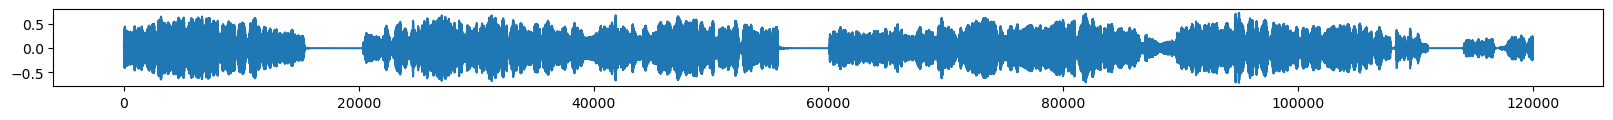

Finished epoch number 209 with a total of 10000 debug_seqs
 time: 2025-10-27 21:09:07.161453, epoch 210,  Loss: 0.2185
  Quantizer 0 Loss: 2.1418
  Quantizer 1 Loss: 2.6398
  Quantizer 2 Loss: 3.2963
  Quantizer 3 Loss: 3.7532
  Quantizer 4 Loss: 4.0722
  Quantizer 5 Loss: 4.2781
  Quantizer 6 Loss: 4.5314
  Quantizer 7 Loss: 4.6612
Latents embedded in 106 of the GRU input size of 128
Conditioning parameters embedded in 22 of the GRU input size of 128
DEVICE going in: model tensors cuda:0, enc_model cpu, c cuda:0
About toInitialize generator with c.shape = torch.Size([8])
params_seq.shape = torch.Size([10, 8])
plot the audio which has shape (120000,)


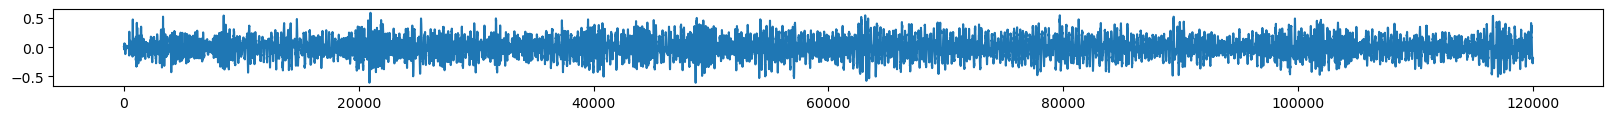

Finished epoch number 210 with a total of 10000 debug_seqs
 time: 2025-10-27 21:09:53.960866, epoch 211,  Loss: 0.2116
  Quantizer 0 Loss: 2.1425
  Quantizer 1 Loss: 2.6346
  Quantizer 2 Loss: 3.2923
  Quantizer 3 Loss: 3.7452
  Quantizer 4 Loss: 4.0633
  Quantizer 5 Loss: 4.2698
  Quantizer 6 Loss: 4.5173
  Quantizer 7 Loss: 4.6466
Latents embedded in 106 of the GRU input size of 128
Conditioning parameters embedded in 22 of the GRU input size of 128
DEVICE going in: model tensors cuda:0, enc_model cpu, c cuda:0
About toInitialize generator with c.shape = torch.Size([8])
params_seq.shape = torch.Size([10, 8])
plot the audio which has shape (120000,)


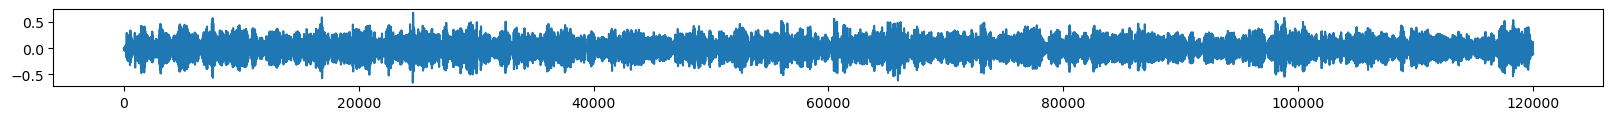

Finished epoch number 211 with a total of 10000 debug_seqs
 time: 2025-10-27 21:10:40.180581, epoch 212,  Loss: 0.2117
  Quantizer 0 Loss: 2.1488
  Quantizer 1 Loss: 2.6449
  Quantizer 2 Loss: 3.3025
  Quantizer 3 Loss: 3.7600
  Quantizer 4 Loss: 4.0720
  Quantizer 5 Loss: 4.2795
  Quantizer 6 Loss: 4.5322
  Quantizer 7 Loss: 4.6624
Latents embedded in 106 of the GRU input size of 128
Conditioning parameters embedded in 22 of the GRU input size of 128
DEVICE going in: model tensors cuda:0, enc_model cpu, c cuda:0
About toInitialize generator with c.shape = torch.Size([8])
params_seq.shape = torch.Size([10, 8])
plot the audio which has shape (120000,)


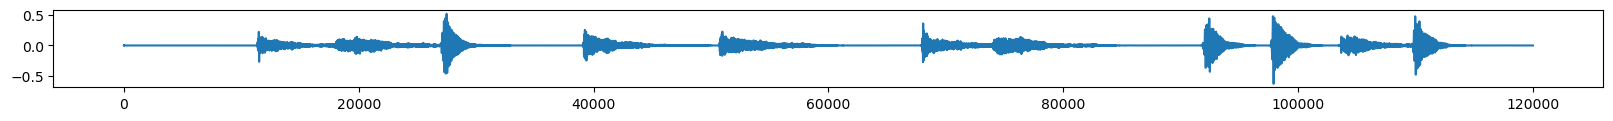

Finished epoch number 212 with a total of 10000 debug_seqs
 time: 2025-10-27 21:11:26.415276, epoch 213,  Loss: 0.2224
  Quantizer 0 Loss: 2.1376
  Quantizer 1 Loss: 2.6363
  Quantizer 2 Loss: 3.2911
  Quantizer 3 Loss: 3.7422
  Quantizer 4 Loss: 4.0614
  Quantizer 5 Loss: 4.2670
  Quantizer 6 Loss: 4.5076
  Quantizer 7 Loss: 4.6435
Latents embedded in 106 of the GRU input size of 128
Conditioning parameters embedded in 22 of the GRU input size of 128
DEVICE going in: model tensors cuda:0, enc_model cpu, c cuda:0
About toInitialize generator with c.shape = torch.Size([8])
params_seq.shape = torch.Size([10, 8])
plot the audio which has shape (120000,)


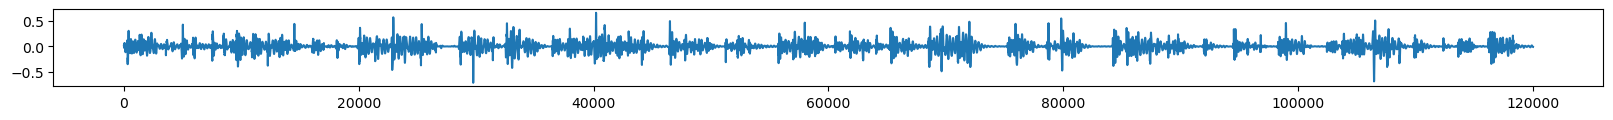

Finished epoch number 213 with a total of 10000 debug_seqs
 time: 2025-10-27 21:12:13.041533, epoch 214,  Loss: 0.2171
  Quantizer 0 Loss: 2.1570
  Quantizer 1 Loss: 2.6526
  Quantizer 2 Loss: 3.3065
  Quantizer 3 Loss: 3.7577
  Quantizer 4 Loss: 4.0769
  Quantizer 5 Loss: 4.2863
  Quantizer 6 Loss: 4.5296
  Quantizer 7 Loss: 4.6649
Latents embedded in 106 of the GRU input size of 128
Conditioning parameters embedded in 22 of the GRU input size of 128
DEVICE going in: model tensors cuda:0, enc_model cpu, c cuda:0
About toInitialize generator with c.shape = torch.Size([8])
params_seq.shape = torch.Size([10, 8])
plot the audio which has shape (120000,)


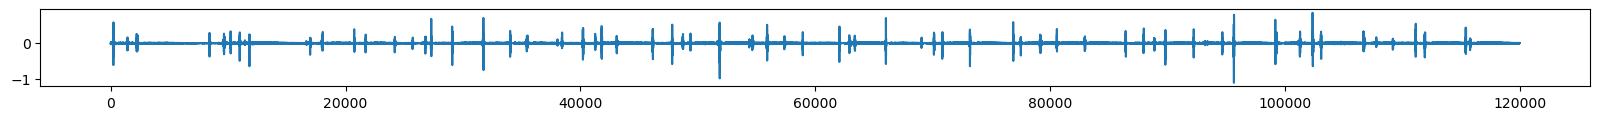

Finished epoch number 214 with a total of 10000 debug_seqs
 time: 2025-10-27 21:12:59.954466, epoch 215,  Loss: 0.2178
  Quantizer 0 Loss: 2.1420
  Quantizer 1 Loss: 2.6391
  Quantizer 2 Loss: 3.2997
  Quantizer 3 Loss: 3.7462
  Quantizer 4 Loss: 4.0689
  Quantizer 5 Loss: 4.2700
  Quantizer 6 Loss: 4.5177
  Quantizer 7 Loss: 4.6526
Latents embedded in 106 of the GRU input size of 128
Conditioning parameters embedded in 22 of the GRU input size of 128
DEVICE going in: model tensors cuda:0, enc_model cpu, c cuda:0
About toInitialize generator with c.shape = torch.Size([8])
params_seq.shape = torch.Size([10, 8])
plot the audio which has shape (120000,)


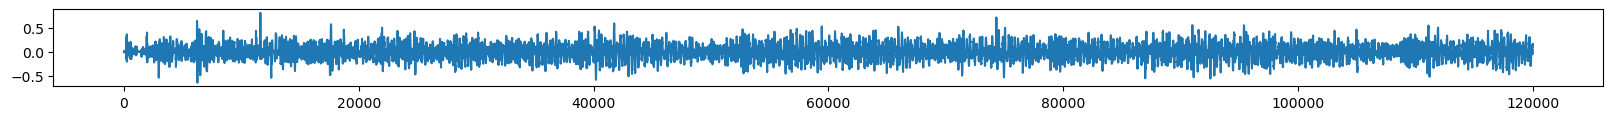

Finished epoch number 215 with a total of 10000 debug_seqs
 time: 2025-10-27 21:13:46.387204, epoch 216,  Loss: 0.2174
  Quantizer 0 Loss: 2.1443
  Quantizer 1 Loss: 2.6423
  Quantizer 2 Loss: 3.2947
  Quantizer 3 Loss: 3.7498
  Quantizer 4 Loss: 4.0648
  Quantizer 5 Loss: 4.2761
  Quantizer 6 Loss: 4.5234
  Quantizer 7 Loss: 4.6575
Latents embedded in 106 of the GRU input size of 128
Conditioning parameters embedded in 22 of the GRU input size of 128
DEVICE going in: model tensors cuda:0, enc_model cpu, c cuda:0
About toInitialize generator with c.shape = torch.Size([8])
params_seq.shape = torch.Size([10, 8])
plot the audio which has shape (120000,)


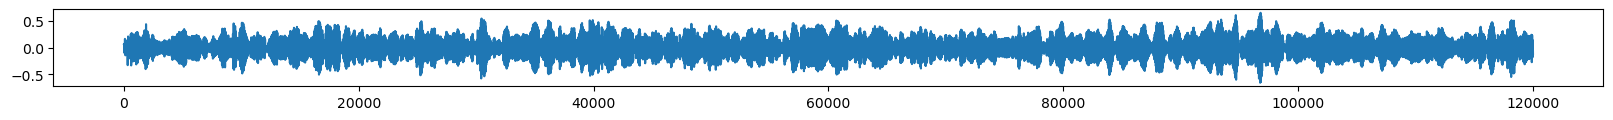

Finished epoch number 216 with a total of 10000 debug_seqs
 time: 2025-10-27 21:14:34.364332, epoch 217,  Loss: 0.2229
  Quantizer 0 Loss: 2.1394
  Quantizer 1 Loss: 2.6419
  Quantizer 2 Loss: 3.2926
  Quantizer 3 Loss: 3.7426
  Quantizer 4 Loss: 4.0680
  Quantizer 5 Loss: 4.2751
  Quantizer 6 Loss: 4.5205
  Quantizer 7 Loss: 4.6573
Latents embedded in 106 of the GRU input size of 128
Conditioning parameters embedded in 22 of the GRU input size of 128
DEVICE going in: model tensors cuda:0, enc_model cpu, c cuda:0
About toInitialize generator with c.shape = torch.Size([8])
params_seq.shape = torch.Size([10, 8])
plot the audio which has shape (120000,)


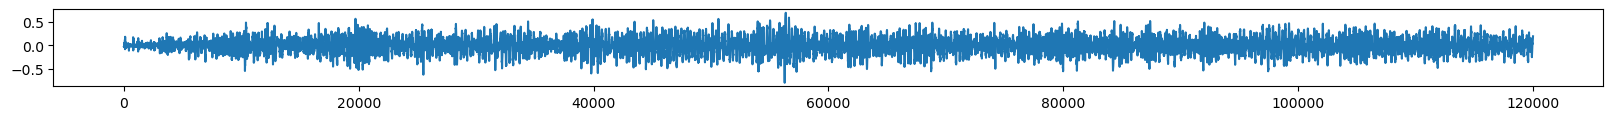

Finished epoch number 217 with a total of 10000 debug_seqs
 time: 2025-10-27 21:15:22.098516, epoch 218,  Loss: 0.2164
  Quantizer 0 Loss: 2.1574
  Quantizer 1 Loss: 2.6545
  Quantizer 2 Loss: 3.3077
  Quantizer 3 Loss: 3.7534
  Quantizer 4 Loss: 4.0773
  Quantizer 5 Loss: 4.2820
  Quantizer 6 Loss: 4.5249
  Quantizer 7 Loss: 4.6600
Latents embedded in 106 of the GRU input size of 128
Conditioning parameters embedded in 22 of the GRU input size of 128
DEVICE going in: model tensors cuda:0, enc_model cpu, c cuda:0
About toInitialize generator with c.shape = torch.Size([8])
params_seq.shape = torch.Size([10, 8])
plot the audio which has shape (120000,)


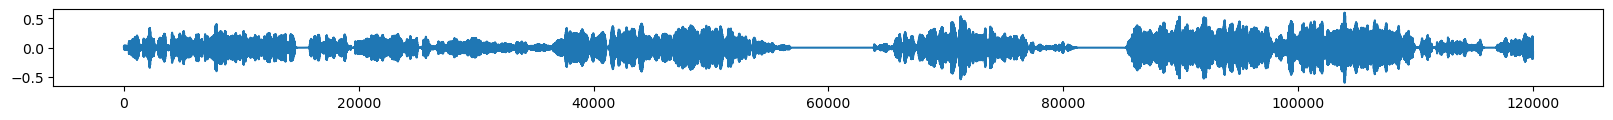

Finished epoch number 218 with a total of 10000 debug_seqs
 time: 2025-10-27 21:16:09.884766, epoch 219,  Loss: 0.2157
  Quantizer 0 Loss: 2.1534
  Quantizer 1 Loss: 2.6490
  Quantizer 2 Loss: 3.2980
  Quantizer 3 Loss: 3.7502
  Quantizer 4 Loss: 4.0711
  Quantizer 5 Loss: 4.2773
  Quantizer 6 Loss: 4.5195
  Quantizer 7 Loss: 4.6560
Latents embedded in 106 of the GRU input size of 128
Conditioning parameters embedded in 22 of the GRU input size of 128
DEVICE going in: model tensors cuda:0, enc_model cpu, c cuda:0
About toInitialize generator with c.shape = torch.Size([8])
params_seq.shape = torch.Size([10, 8])
plot the audio which has shape (120000,)


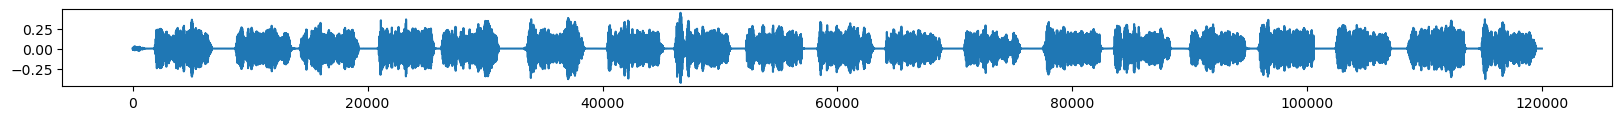

Finished epoch number 219 with a total of 10000 debug_seqs
 time: 2025-10-27 21:16:56.823929, epoch 220,  Loss: 0.2174
  Quantizer 0 Loss: 2.1538
  Quantizer 1 Loss: 2.6519
  Quantizer 2 Loss: 3.3044
  Quantizer 3 Loss: 3.7524
  Quantizer 4 Loss: 4.0730
  Quantizer 5 Loss: 4.2769
  Quantizer 6 Loss: 4.5233
  Quantizer 7 Loss: 4.6585
Latents embedded in 106 of the GRU input size of 128
Conditioning parameters embedded in 22 of the GRU input size of 128
DEVICE going in: model tensors cuda:0, enc_model cpu, c cuda:0
About toInitialize generator with c.shape = torch.Size([8])
params_seq.shape = torch.Size([10, 8])
plot the audio which has shape (120000,)


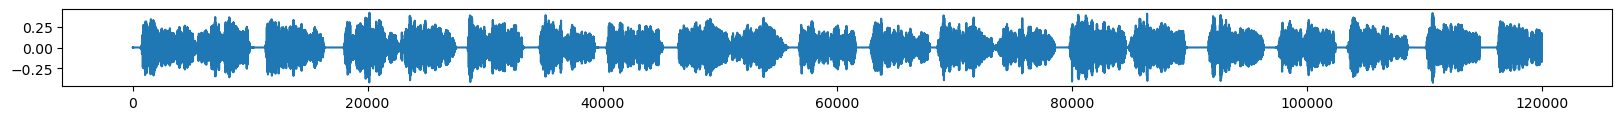

Finished epoch number 220 with a total of 10000 debug_seqs
 time: 2025-10-27 21:17:43.187958, epoch 221,  Loss: 0.2131
  Quantizer 0 Loss: 2.1473
  Quantizer 1 Loss: 2.6439
  Quantizer 2 Loss: 3.2948
  Quantizer 3 Loss: 3.7459
  Quantizer 4 Loss: 4.0649
  Quantizer 5 Loss: 4.2693
  Quantizer 6 Loss: 4.5119
  Quantizer 7 Loss: 4.6523
Latents embedded in 106 of the GRU input size of 128
Conditioning parameters embedded in 22 of the GRU input size of 128
DEVICE going in: model tensors cuda:0, enc_model cpu, c cuda:0
About toInitialize generator with c.shape = torch.Size([8])
params_seq.shape = torch.Size([10, 8])
plot the audio which has shape (120000,)


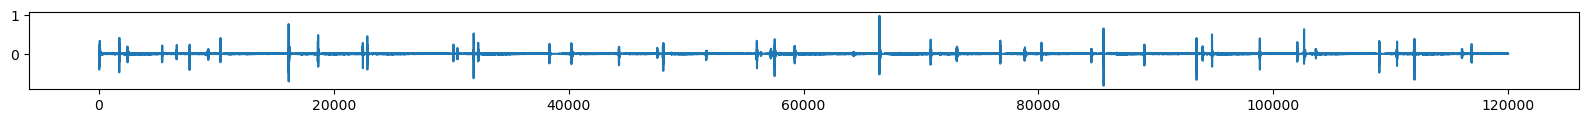

Finished epoch number 221 with a total of 10000 debug_seqs
 time: 2025-10-27 21:18:29.833029, epoch 222,  Loss: 0.2236
  Quantizer 0 Loss: 2.1389
  Quantizer 1 Loss: 2.6266
  Quantizer 2 Loss: 3.2813
  Quantizer 3 Loss: 3.7374
  Quantizer 4 Loss: 4.0563
  Quantizer 5 Loss: 4.2677
  Quantizer 6 Loss: 4.5097
  Quantizer 7 Loss: 4.6432
Latents embedded in 106 of the GRU input size of 128
Conditioning parameters embedded in 22 of the GRU input size of 128
DEVICE going in: model tensors cuda:0, enc_model cpu, c cuda:0
About toInitialize generator with c.shape = torch.Size([8])
params_seq.shape = torch.Size([10, 8])
plot the audio which has shape (120000,)


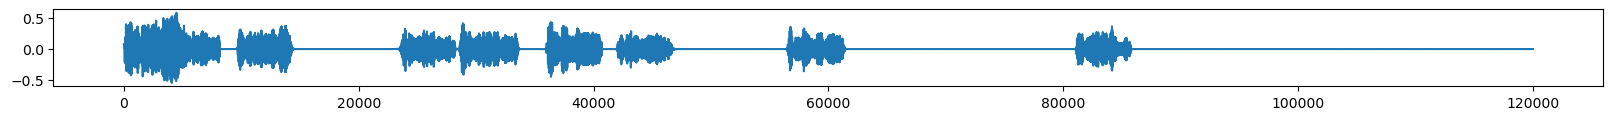

Finished epoch number 222 with a total of 10000 debug_seqs
 time: 2025-10-27 21:19:16.323908, epoch 223,  Loss: 0.2107
  Quantizer 0 Loss: 2.1552
  Quantizer 1 Loss: 2.6575
  Quantizer 2 Loss: 3.3054
  Quantizer 3 Loss: 3.7546
  Quantizer 4 Loss: 4.0722
  Quantizer 5 Loss: 4.2792
  Quantizer 6 Loss: 4.5252
  Quantizer 7 Loss: 4.6574
Latents embedded in 106 of the GRU input size of 128
Conditioning parameters embedded in 22 of the GRU input size of 128
DEVICE going in: model tensors cuda:0, enc_model cpu, c cuda:0
About toInitialize generator with c.shape = torch.Size([8])
params_seq.shape = torch.Size([10, 8])
plot the audio which has shape (120000,)


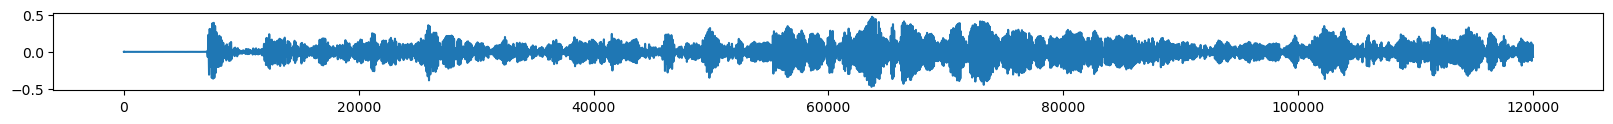

Finished epoch number 223 with a total of 10000 debug_seqs
 time: 2025-10-27 21:20:03.660449, epoch 224,  Loss: 0.2182
  Quantizer 0 Loss: 2.1457
  Quantizer 1 Loss: 2.6383
  Quantizer 2 Loss: 3.2971
  Quantizer 3 Loss: 3.7468
  Quantizer 4 Loss: 4.0661
  Quantizer 5 Loss: 4.2744
  Quantizer 6 Loss: 4.5196
  Quantizer 7 Loss: 4.6564
Latents embedded in 106 of the GRU input size of 128
Conditioning parameters embedded in 22 of the GRU input size of 128
DEVICE going in: model tensors cuda:0, enc_model cpu, c cuda:0
About toInitialize generator with c.shape = torch.Size([8])
params_seq.shape = torch.Size([10, 8])
plot the audio which has shape (120000,)


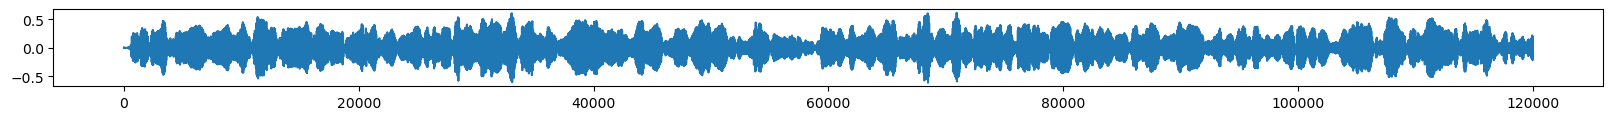

Finished epoch number 224 with a total of 10000 debug_seqs
 time: 2025-10-27 21:20:49.789736, epoch 225,  Loss: 0.2129
  Quantizer 0 Loss: 2.1453
  Quantizer 1 Loss: 2.6345
  Quantizer 2 Loss: 3.2879
  Quantizer 3 Loss: 3.7385
  Quantizer 4 Loss: 4.0557
  Quantizer 5 Loss: 4.2603
  Quantizer 6 Loss: 4.5059
  Quantizer 7 Loss: 4.6431
Latents embedded in 106 of the GRU input size of 128
Conditioning parameters embedded in 22 of the GRU input size of 128
DEVICE going in: model tensors cuda:0, enc_model cpu, c cuda:0
About toInitialize generator with c.shape = torch.Size([8])
params_seq.shape = torch.Size([10, 8])
plot the audio which has shape (120000,)


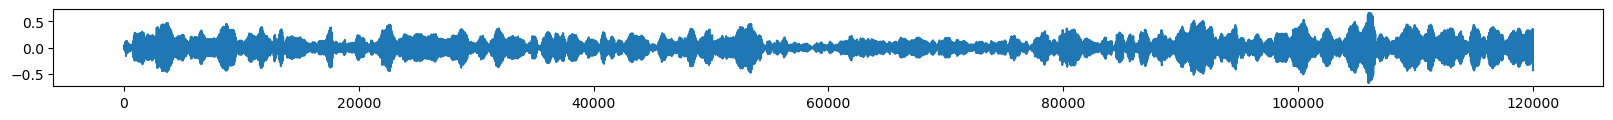

Saved checkpoint at epoch 225
Training time taken: 3:01:16
Saved checkpoint at epoch 225


'/home/lonce/working/RNeNcodec/notebooks/output/20251027_181934_multiclass_test_SOFTcascade/checkpoints/last_checkpoint.pt'

In [16]:
# Train!
#*************************************
enc_model.to(device)
list_of_losses = []

print('{:%Y-%m-%d %H:%M:%S} Starting training...'.format(datetime.now()))
start_time = time.monotonic()
#-------------------------------------------------------------------------------
for epoch in range(start_epoch, start_epoch+params['num_epochs']):
    train(rnn,enc_model,epoch)
#-------------------------------------------------------------------------------
writer.close()
elapsed_time = time.monotonic() - start_time
print('Training time taken:',time_taken(elapsed_time))

#Just make sure the final model gets saved
checkpoint_data = {
    'epoch': epoch+1,
    'model_state_dict': rnn.state_dict(),
    'optimizer_state_dict': optimizer.state_dict()
}
# Save numbered checkpoint
numbered_path = os.path.join(f"{out_dir}/checkpoints", f"checkpoint_{epoch+1}.pt")
torch.save(checkpoint_data, numbered_path)
print(f"Saved checkpoint at epoch {epoch+1}")
# Copy to "last" (much faster than saving twice)
last_path = os.path.join(f"{out_dir}/checkpoints", "last_checkpoint.pt")
shutil.copy2(numbered_path, last_path)


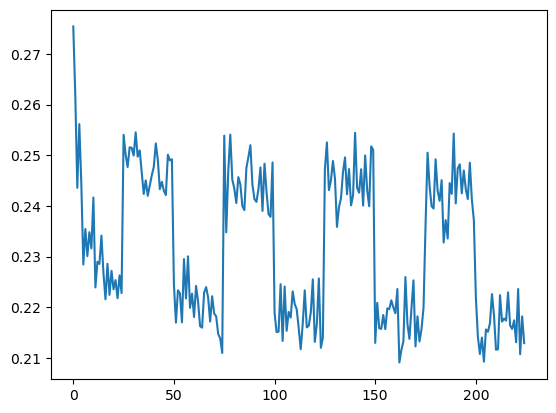

In [17]:
# Plot the loss over time
#*************************************
plt.figure()
plt.plot(list_of_losses)
plt.show()  # This will actually display the plot

In [18]:
list_of_losses

[0.27543991088867187,
 0.26191958618164063,
 0.24356973266601561,
 0.25616848754882815,
 0.24437835693359375,
 0.2284280242919922,
 0.23544253540039062,
 0.23008360290527344,
 0.2348187713623047,
 0.23161140441894532,
 0.24166548156738282,
 0.22390261840820314,
 0.22897978210449219,
 0.228546142578125,
 0.2341446075439453,
 0.22666598510742186,
 0.22155789184570313,
 0.22857176208496094,
 0.2224365997314453,
 0.2271940460205078,
 0.2235539093017578,
 0.22534461975097655,
 0.2217688446044922,
 0.22628781127929687,
 0.22279615783691406,
 0.2540477905273438,
 0.2501697692871094,
 0.24767747497558593,
 0.2515743865966797,
 0.2514919738769531,
 0.2499578399658203,
 0.2545344390869141,
 0.2497254180908203,
 0.2509704284667969,
 0.24664152526855468,
 0.24236654663085938,
 0.24505197143554688,
 0.24200981140136718,
 0.24398074340820314,
 0.24604312133789064,
 0.24769834899902343,
 0.2523454132080078,
 0.24914154052734375,
 0.24332264709472656,
 0.2447616729736328,
 0.24299653625488282,
 0.2421